# ZShooter SPIE 2026

In [1]:
import zs_scopesim_tools
%matplotlib inline
from collections import OrderedDict
from contextlib import contextmanager
import importlib.metadata
from math import erf
import logging
import pathlib
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u
from astropy.table import Table

import scopesim as sim
from scopesim.utils import from_currsys
import scopesim_templates as sim_tp

# One visible switch controls the notebook, paper/vector, and presentation styles.
PLOT_MODE = "paper"  # choose: notebook, paper, presentation
PLOT_STYLES = {
    "notebook": "default",
    "paper": "seaborn-v0_8-paper",
    "presentation": "dark_background",
}
plt.style.use(PLOT_STYLES[PLOT_MODE])


def display_and_save_figure(fig, output_stem, *, filename=None, filename_append="", save=True):
    if filename is not None and filename_append:
        raise ValueError("Use filename or filename_append, not both.")
    if filename is None:
        target = pathlib.Path(f"{output_stem}{filename_append}.pdf")
    else:
        target = pathlib.Path(filename)
        if not target.suffix:
            target = target.with_suffix(".pdf")
    if not target.is_absolute():
        target = pathlib.Path(output_dir) / target
    display(fig)
    if save:
        fig.savefig(target, bbox_inches="tight")
    plt.close(fig)
    return target

In [2]:
from zs_scopesim_tools.helpers import (configure_irdb_path, disable_scopesim_progress_bars, disable_scopesim_top_level_catch,
                                       make_local_output_dir, warning_prevent_sync_alt_ra_dec, instrument_package_dir,
                                       ignore_warnings, set_scopesim_log_level)
from zs_scopesim_tools.sources import constant_photon_flux_flat, lamp_flat
from zs_scopesim_tools.plots import plot_detector_background_budget, plot_detector_image_grid, plot_emissivity_sanity, plot_readout_cross_dispersion_cut, plot_readout_overview, plot_limiting_magnitude_curves, plot_resolving_power_echellogram, plot_slit_adc_psf_scenes, plot_slit_loss_by_arm, plot_slit_width_loss, plot_transmission_sanity, show_and_save_hdul, PlotScene
from zs_scopesim_tools.validation import (
    build_emissivity_sanity_data, build_slit_adc_psf_scene_data, build_slit_loss_data, build_slit_width_loss_data, build_transmission_sanity_data,
    detector_background_budget_table, detector_geometry_table, detector_qe_accounting_table, detector_selector_matrix,
    effect_name, fetch_effect_spectrum_or_transmission, fixed_bin_no_oh_limiting_magnitude_curves, fov_image_plane_counts, get_effect,
    readout_delta_summary_table, science_truth_crosscheck_table, slit_adc_psf_status_table, slit_pair_status_table, snr_selected_spectral_bins, source_position_table,
    trace_catalog_table, trace_resolution_diagnostic_table, trace_resolution_summary_display_table, trace_resolution_summary_table,
    validate_emissivity_sanity_data, validate_transmission_sanity_data,
)
ignore_warnings()

## Run Configuration

Edit this cell first. The notebook is organized so the configuration, source construction, and background toggles are near the calculations that depend on them. The altitude is derived from the requested airmass and RA/Dec are cleared so sky and PSF terms are driven by the quantities that matter for this simulator validation: airmass, seeing, sky brightness, slit, exposure time, and enabled effects.

In [3]:
irdb_path = configure_irdb_path(fallback_irdb_path="/Users/jibailey/src/irdb")
set_scopesim_log_level(level="warning")
zshooter_dir = instrument_package_dir("ZShooter_v2")
output_dir = make_local_output_dir(dirname="spie2026")
hide_scopesim_progress = True
disable_scopesim_top_level_catch()

def set_channel_exposure(cmds, *, dit, ndit):
    cmds["!OBS.dit"] = dit
    cmds["!OBS.ndit"] = ndit
    for channel in ("blue", "green", "red", "yj", "h", "k"):
        cmds[f"!OBS.dit_{channel}"] = dit
        cmds[f"!OBS.ndit_{channel}"] = ndit

component_metadata = {"telescope_reflection": {"throughput_group": "telescope", "emission_phase": "pre_disperser"},
                      "ir_blocking_filter_selector": {"throughput_group": "ir_blocking_filter"},
                      }

print(f"Outputs: {output_dir}")

def cmd_value(key, commands=None):
    commands = zs.cmds if commands is None else commands
    commands = commands.cmds if hasattr(commands, "cmds") else commands
    return from_currsys(key, commands)


def display_frame(data, *, columns=None, rename=None, formats=None):
    if isinstance(data, Table):
        view = data[columns] if columns is not None else data
        frame = view.to_pandas()
    else:
        frame = pd.DataFrame(data)
        if columns is not None:
            frame = frame.loc[:, columns]
    if rename:
        frame = frame.rename(columns=rename)
    styler = frame.style.hide(axis="index")
    if formats:
        active_formats = {key: value for key, value in formats.items() if key in frame.columns}
        styler = styler.format(active_formats, na_rep="--")
    display(styler)


def compact_range(minimum, maximum, digits=1):
    if not np.isfinite(minimum) or not np.isfinite(maximum):
        return "--"
    if np.isclose(minimum, maximum, rtol=1e-4, atol=10**-digits):
        return f"{minimum:.{digits}f}"
    return f"{minimum:.{digits}f}-{maximum:.{digits}f}"

def show_run():
    code_revision = subprocess.run(["git", "-C", str(pathlib.Path.cwd()), "describe", "--always", "--dirty"], check=True, capture_output=True, text=True).stdout.strip()
    irdb_revision = subprocess.run(["git", "-C", str(irdb_path), "describe", "--always", "--dirty"], check=True, capture_output=True, text=True).stdout.strip()
    run_card = Table(rows=[
        {"quantity": "instrument", "value": "ZShooter_v2 SPEC", "why_it_matters": "loads the release IRDB model"},
        {"quantity": "zs-scopesim revision", "value": code_revision, "why_it_matters": "identifies the notebook and package implementation"},
        {"quantity": "ScopeSim version", "value": importlib.metadata.version("ScopeSim"), "why_it_matters": "identifies the simulation engine"},
        {"quantity": "IRDB revision", "value": irdb_revision, "why_it_matters": "identifies the configured instrument data"},
        {"quantity": "airmass", "value": cmd_value("!OBS.airmass"), "why_it_matters": "sets atmospheric path, dispersion, and sky"},
        {"quantity": "altitude [deg]", "value": cmd_value("!OBS.alt"), "why_it_matters": "derived from airmass for ScopeSim AltAz context"},
        {"quantity": "RA/Dec", "value": f"{cmd_value('!OBS.ra')}/{cmd_value('!OBS.dec')}", "why_it_matters": "cleared so they do not override airmass"},
        {"quantity": "seeing [arcsec]", "value": cmd_value("!OBS.seeing"), "why_it_matters": "natural-seeing PSF scale"},
        {"quantity": "sky brightness", "value": cmd_value("!OBS.brightness"), "why_it_matters": "SkyCalc continuum/line brightness preset"},
        {"quantity": "command telescope area", "value": cmd_value("!TEL.area", cmd), "why_it_matters": "pre-train default; should be replaced by optical-train derived area"},
        {"quantity": "train telescope area", "value": cmd_value("!TEL.area"), "why_it_matters": "derived from the active Keck mirror SurfaceList and used by FOV/source scaling"},
        {"quantity": "VIS slit [arcsec]", "value": cmd_value("!INST.vis_curr_slit"), "why_it_matters": "source throughput and resolution"},
        {"quantity": "NIR slit [arcsec]", "value": cmd_value("!INST.nir_curr_slit"), "why_it_matters": "source throughput and resolution"},
        {"quantity": "spectral resolving power guardrail", "value": cmd_value("!SIM.spectral.spectral_resolution"), "why_it_matters": "internal spectral work grid / sky sampling guardrail"},
        {"quantity": "DIT x NDIT", "value": f"{cmd_value('!OBS.dit_green')} x {cmd_value('!OBS.ndit_green')}", "why_it_matters": "per-channel detector exposure; total is DIT*NDIT"},
        {"quantity": "pupil angle [deg]", "value": cmd_value("!OBS.pupil_angle"), "why_it_matters": "source-pair orientation used below"},
    ])
    display_frame(run_card, rename={"why_it_matters": "why it matters"})
    return run_card

Outputs: /Users/jibailey/src/zs-scopesim/notebooks/spie2026


In [4]:
cmd = sim.UserCommands(use_instrument="ZShooter_v2", set_modes=["SPEC"])
cmd["!ATMO.skycalc_timeout"] = 60.0 #seconds
cmd["!OBS.airmass"] = 1.1
cmd["!OBS.seeing"] = 0.65
cmd["!OBS.brightness"] = "grey"
cmd["!OBS.pupil_angle"] = 0.0
set_channel_exposure(cmd, dit=1800, ndit=2)
cmd["!INST.vis_curr_slit"] = 0.7 # 0.33
cmd["!INST.nir_curr_slit"] = 0.7 # 0.33
cmd["!INST.include_diffuse_emissivity"] = False
cmd["!SIM.sub_pixel.flag"] = True

warning_prevent_sync_alt_ra_dec(cmd)

zs = sim.OpticalTrain(cmd)
show_run();


quantity,value,why it matters
instrument,ZShooter_v2 SPEC,loads the release IRDB model
zs-scopesim revision,1bed2ea-dirty,identifies the notebook and package implementation
ScopeSim version,0.11.5a3,identifies the simulation engine
IRDB revision,2aa69bd,identifies the configured instrument data
airmass,1.100000,"sets atmospheric path, dispersion, and sky"
altitude [deg],65.380023,derived from airmass for ScopeSim AltAz context
RA/Dec,None/None,cleared so they do not override airmass
seeing [arcsec],0.650000,natural-seeing PSF scale
sky brightness,grey,SkyCalc continuum/line brightness preset
command telescope area,0,pre-train default; should be replaced by optical-train derived area


## Trace Geometry And Resolution Scale

This detector-facing diagnostic samples the loaded spectral traces on the active image planes. The table gives compact channel ranges; the first map shows local resolving power from the trace geometry and detector pixel scale, while the second map shows the corresponding spectral-element sampling width. Blank pixels are off trace. The plotted samples are kept only where the sampled slit footprint is fully on detector; the trace catalog below is the check for the total loaded order count. Detector rotation is part of the trace geometry being checked; `detector_pad` is legacy metadata and is not applied to the optical trace geometry.

quantity,value,why it matters
instrument,ZShooter_v2 SPEC,loads the release IRDB model
zs-scopesim revision,1bed2ea-dirty,identifies the notebook and package implementation
ScopeSim version,0.11.5a3,identifies the simulation engine
IRDB revision,2aa69bd,identifies the configured instrument data
airmass,1.100000,"sets atmospheric path, dispersion, and sky"
altitude [deg],65.380023,derived from airmass for ScopeSim AltAz context
RA/Dec,None/None,cleared so they do not override airmass
seeing [arcsec],0.650000,natural-seeing PSF scale
sky brightness,grey,SkyCalc continuum/line brightness preset
command telescope area,0,pre-train default; should be replaced by optical-train derived area


,ch,id,orders,wave nm,slit,spec FWHM pix,disp nm/pix,R k,resel pix,seeing
0,B,0,34,307-431,"0.33""",2.10,0.0037-0.0056,36.1-40.9,9.5-10.2,"0.73""/4.7 pix"
1,G,1,30,426-656,"0.33""",2.10,0.0051-0.0088,35.0-42.4,8.7-9.5,"0.68""/4.3 pix"
2,R,2,20,645-994,"0.33""",2.10,0.0074-0.0138,33.4-43.8,8.0-8.8,"0.63""/4.0 pix"
3,YJ,3,24,945-1343,"0.33""",2.10,0.0112-0.0180,34.8-42.0,7.6-8.1,"0.58""/3.7 pix"
4,H,4,11,1474-1872,"0.33""",2.10,0.0168-0.0257,33.8-43.7,7.1-7.4,"0.54""/3.4 pix"
5,K,5,8,1973-2474,"0.33""",2.10,0.0215-0.0346,33.2-44.7,6.7-7.0,"0.51""/3.3 pix"


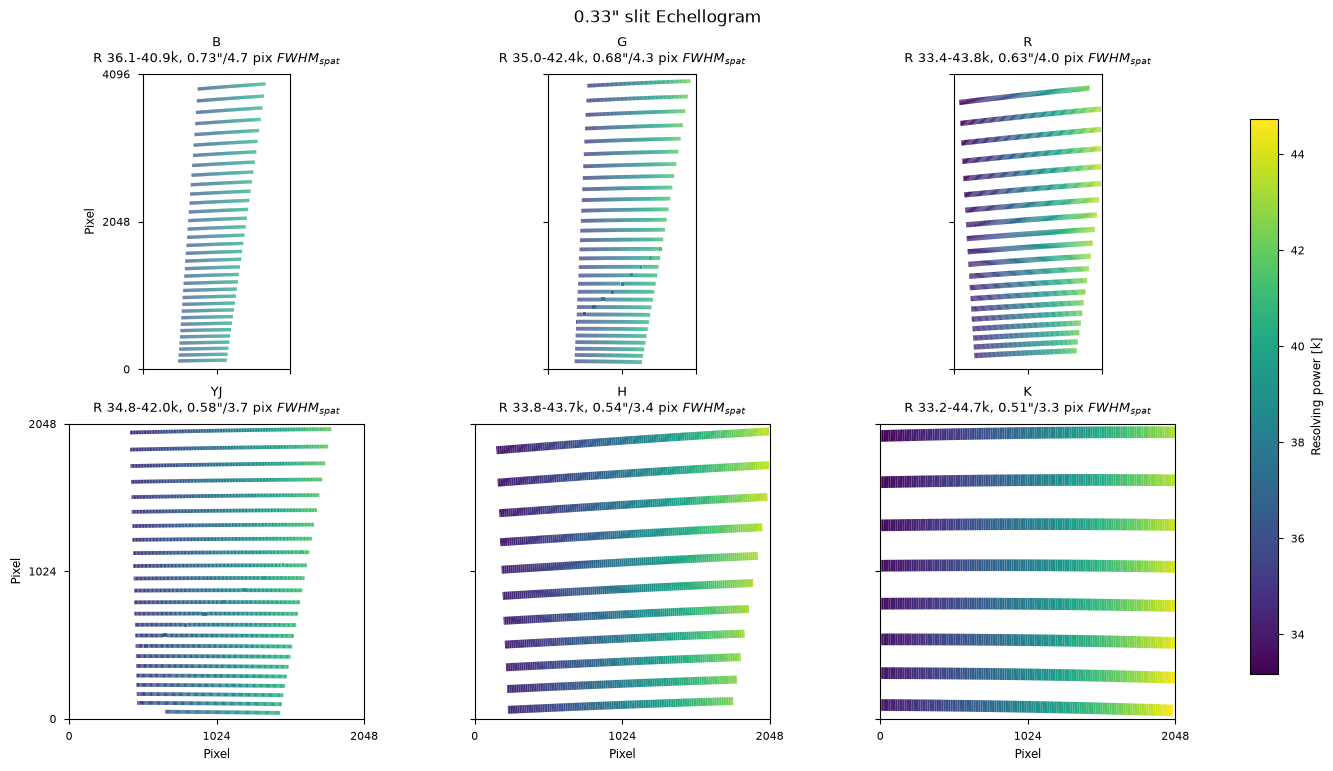

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/resolving_power_033_slit.pdf')

In [5]:
set_channel_exposure(zs.cmds, dit=1800, ndit=2)
zs.cmds["!INST.vis_curr_slit"] = 0.33
zs.cmds["!INST.nir_curr_slit"] = 0.33
zs.update()
show_run();

trace_resolution = trace_resolution_diagnostic_table(zs)
trace_resolution_summary = trace_resolution_summary_table(trace_resolution)
display(trace_resolution_summary_display_table(trace_resolution_summary))
fig, axes = plot_resolving_power_echellogram(trace_resolution, trace_width_fraction= (.4, .4,.4, .3, .3, .3), max_display_samples_per_trace=128)
fig.suptitle('0.33" slit Echellogram')
display_and_save_figure(fig, "resolving_power_033_slit")


In [6]:
set_channel_exposure(zs.cmds, dit=1800, ndit=2)
zs.cmds["!INST.vis_curr_slit"] = 0.70
zs.cmds["!INST.nir_curr_slit"] = 0.70
zs.update()


quantity,value,why it matters
instrument,ZShooter_v2 SPEC,loads the release IRDB model
zs-scopesim revision,1bed2ea-dirty,identifies the notebook and package implementation
ScopeSim version,0.11.5a3,identifies the simulation engine
IRDB revision,2aa69bd,identifies the configured instrument data
airmass,1.100000,"sets atmospheric path, dispersion, and sky"
altitude [deg],65.380023,derived from airmass for ScopeSim AltAz context
RA/Dec,None/None,cleared so they do not override airmass
seeing [arcsec],0.650000,natural-seeing PSF scale
sky brightness,grey,SkyCalc continuum/line brightness preset
command telescope area,0,pre-train default; should be replaced by optical-train derived area


,ch,id,orders,wave nm,slit,spec FWHM pix,disp nm/pix,R k,resel pix,seeing
0,B,0,34,307-431,"0.70""",4.46,0.0037-0.0056,17.0-19.3,20.1-21.5,"0.73""/4.7 pix"
1,G,1,30,426-656,"0.70""",4.46,0.0051-0.0088,16.5-20.0,18.5-20.2,"0.68""/4.3 pix"
2,R,2,20,645-994,"0.70""",4.46,0.0074-0.0138,15.8-20.7,17.0-18.6,"0.63""/4.0 pix"
3,YJ,3,24,945-1343,"0.70""",4.46,0.0112-0.0180,16.4-19.8,16.0-17.2,"0.58""/3.7 pix"
4,H,4,11,1474-1872,"0.70""",4.46,0.0168-0.0257,16.0-20.6,15.0-15.7,"0.54""/3.4 pix"
5,K,5,8,1973-2474,"0.70""",4.46,0.0215-0.0346,15.6-21.1,14.2-14.9,"0.51""/3.3 pix"


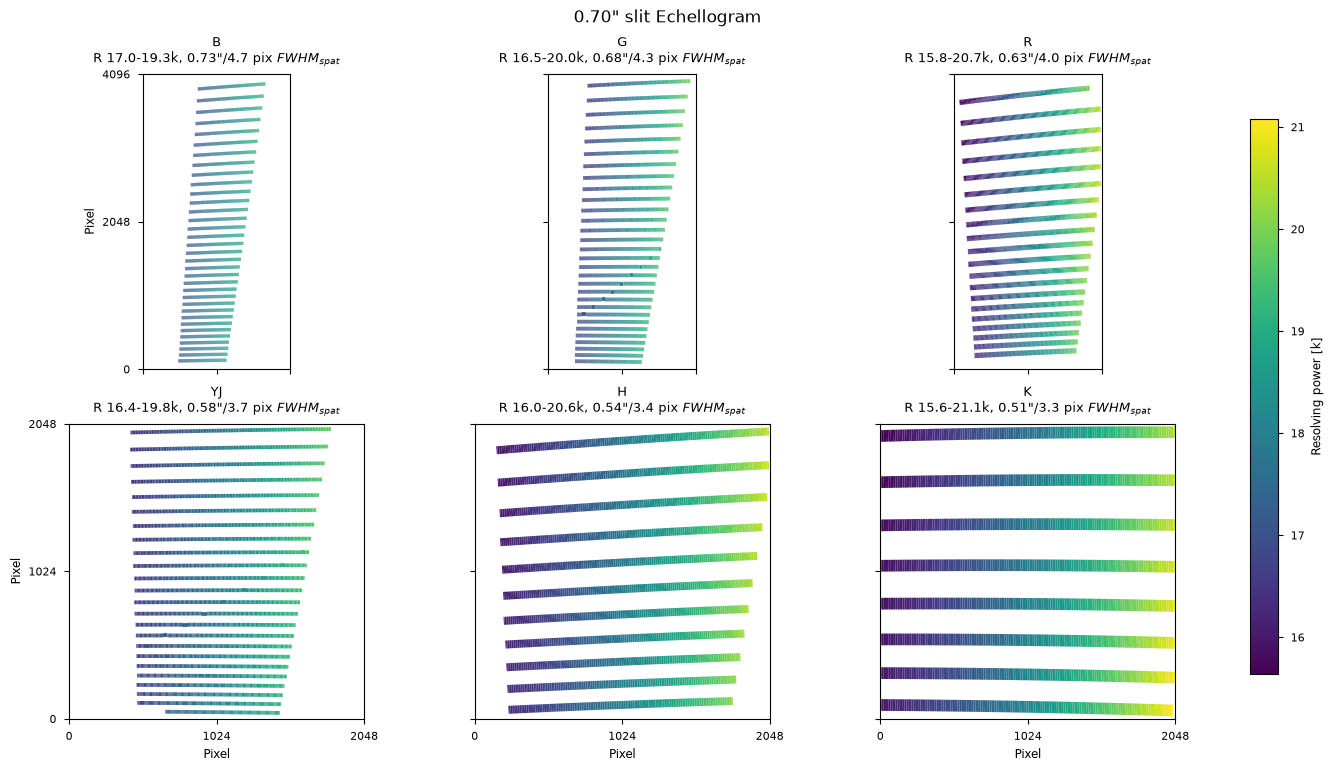

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/resolving_power_070_slit.pdf')

In [7]:
show_run();
trace_resolution = trace_resolution_diagnostic_table(zs)
trace_resolution_summary = trace_resolution_summary_table(trace_resolution)
display(trace_resolution_summary_display_table(trace_resolution_summary))

fig, axes = plot_resolving_power_echellogram(trace_resolution, trace_width_fraction= (.4, .4,.4, .3, .3, .3), max_display_samples_per_trace=128)
fig.suptitle('0.70" slit Echellogram')
display_and_save_figure(fig, "resolving_power_070_slit")

## Model Inventory

This is the compact checklist of what is active in the simulator. A release validation notebook should make omissions as visible as included machinery. Total integrated scatter from bright sky lines is not yet a ScopeSim/IRDB effect; the relevant physics is shown later as a back-of-the-envelope scale and should become a follow-up ScopeSim effect.

In [8]:
from zs_scopesim_tools.helpers import list_effects
inventory = list_effects(cmd)
display_frame(inventory[inventory["included"]])


included,effect,class,config,selector,data file
True,atmo_transmission,TERCurve,MaunaKea (ATMO),,TER_maunakea_tapas.dat
True,continuum_emission,SkyBackgroundTERCurve,MaunaKea (ATMO),,
True,airglow_and_interline_continuum,PalaceAirglowEmission,MaunaKea (ATMO),,
True,seeing_psf,AOEnhanceablePSF,MaunaKea (ATMO),,
True,adc_residuals,ADCShift,MaunaKea (ATMO),,adc_residuals.dat
True,telescope_reflection,SurfaceList,keck (TEL),,LIST_keck_mirrors.dat
True,dichroic_tree,DichroicTree,ZShooter (INST),,
True,slitwheel_selector,SelectorWheel,ZShooter (INST),,
True,channel_optics_selector,SelectorWheel,ZShooter (INST),,
True,trace_eff_analytical,EchelleSpectralEfficiency,ZShooter (INST),,traces/echelle_trace_parameters.dat


## Slit Loss, Seeing, AO Design Curves, And Atmospheric Dispersion

These plots are diagnostics for the optical geometry rather than extracted data products. The first plot uses color for seeing/AO, dash pattern for slit choice, opacity for airmass, and short tick marks on the line for ADC off. Line weight is reserved for the fully current observing combination. The slit legend uses `*` for the selected VIS slit and `^` for the selected NIR slit when a selected slit is one of the plotted extrema; when both arms use the same non-extremal selected slit, that shared style is labeled `Selected slit`. The second plot isolates PSF loss as a function of slit width. Legend labels pair VIS/NIR wavelengths by construction, for example `0.65" NS, 500/1250 nm`; if that pairing breaks, the plot should fail instead of silently changing meaning.


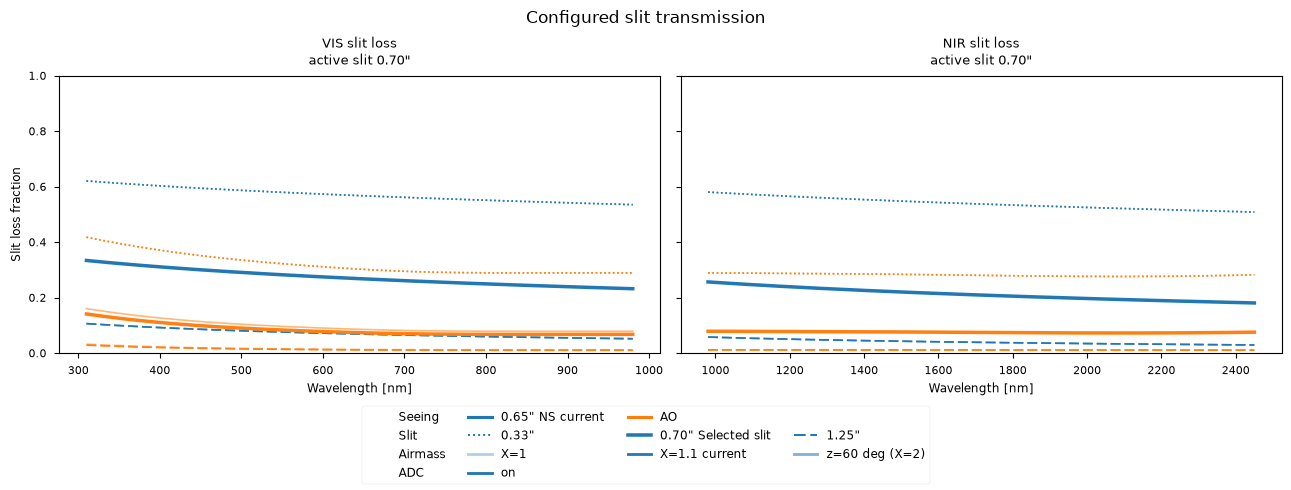

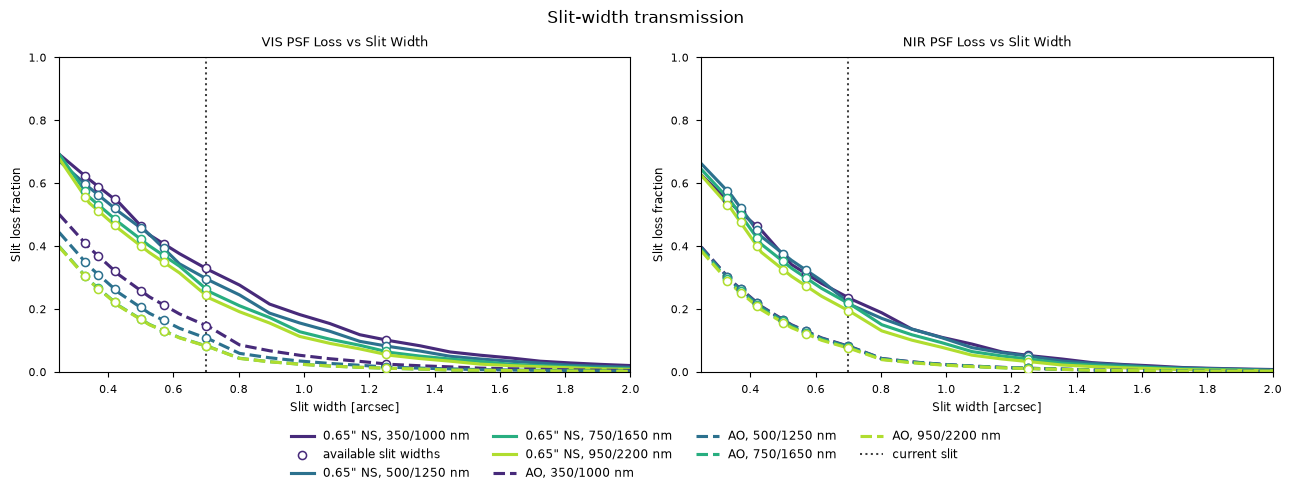

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/slit_width_transmission.pdf')

In [9]:
SLIT_LOSS_SAMPLES = 160
SLIT_LOSS_GRID_STEP = 0.04 * u.arcsec

slit_loss_data = build_slit_loss_data(zs, n_wave=SLIT_LOSS_SAMPLES, slit_length=10 * u.arcsec, grid_step=SLIT_LOSS_GRID_STEP)
fig, axes = plot_slit_loss_by_arm(slit_loss_data, show_airmass_states=True, show_adc_states=False)
fig.suptitle("Configured slit transmission")
display_and_save_figure(fig, "slit_transmission")

slit_width_loss_data = build_slit_width_loss_data(zs, slit_length=10 * u.arcsec, grid_step=SLIT_LOSS_GRID_STEP)
fig, axes = plot_slit_width_loss(slit_width_loss_data)
fig.suptitle("Slit-width transmission")
display_and_save_figure(fig, "slit_width_transmission")


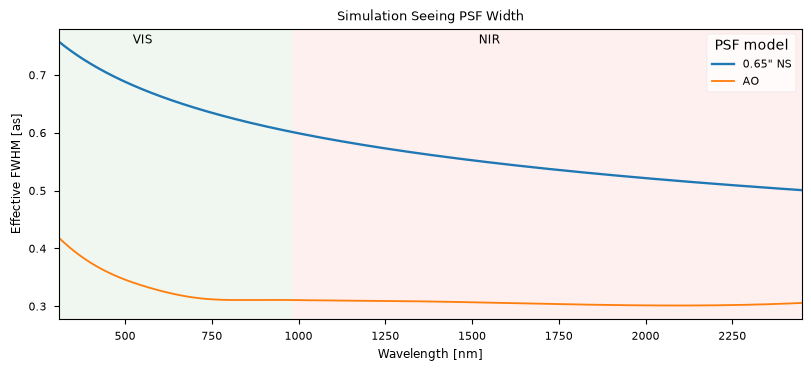

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/natural_ao_psf_fwhm.pdf')

In [10]:
psf_wave_nm = np.linspace(min(arm["wave_nm"].to_value(u.nm).min() for arm in slit_loss_data["arms"].values()), max(arm["wave_nm"].to_value(u.nm).max() for arm in slit_loss_data["arms"].values()), 700) * u.nm

psf_seeing = slit_loss_data["seeing_arcsec"]
psf_zenith = slit_loss_data["current_zenith_angle_deg"].to(u.deg)

fig, ax = plt.subplots(figsize=(8.0, 3.6), constrained_layout=True)
for mode_name, mode in slit_loss_data["psf_modes"].items():
    fwhm = mode["fwhm_func"](psf_wave_nm).to_value(u.arcsec)

    ax.plot(psf_wave_nm.to_value(u.nm), fwhm, label=mode["label"], linewidth=plt.rcParams["lines.linewidth"] * (1.2 if mode.get("current", False) else 0.95))

for arm_name, arm in slit_loss_data["arms"].items():
    wave = arm["wave_nm"].to_value(u.nm)
    ax.axvspan(wave.min(), wave.max(), color={'VIS':"green", 'NIR':"red"}[arm_name], alpha=0.06, lw=0)

    ax.text(np.sqrt(wave.min() * wave.max()), 0.98, arm_name, transform=ax.get_xaxis_transform(), ha="center", va="top", fontsize="small", color=plt.rcParams["text.color"])

ax.set_xlim(psf_wave_nm.min().value, psf_wave_nm.max().value)
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("Effective FWHM [as]")
ax.set_title("Simulation Seeing PSF Width")
ax.legend(title="PSF model")
display_and_save_figure(fig, "natural_ao_psf_fwhm")

In [11]:
slit_width_rows = []
for arm_name, arm in slit_width_loss_data["arms"].items():
    slit_widths = arm["slit_widths_arcsec"].to_value(u.arcsec)
    current_slit = arm["current_slit_width_arcsec"].to_value(u.arcsec)
    for curve in arm["curves"].values():
        slit_width_rows.append({
            "arm": arm_name,
            "PSF / ADC case": curve["psf_mode"],
            "wavelength [nm]": curve["wavelength_nm"],
            "active slit [arcsec]": current_slit,
            "transmission at active slit": np.interp(current_slit, slit_widths, curve["throughput"]),
            "loss at active slit": np.interp(current_slit, slit_widths, curve["loss"]),
        })
display_frame(slit_width_rows,
    formats={
        "wavelength [nm]": "{:.0f}",
        "active slit [arcsec]": "{:.2f}",
        "transmission at active slit": "{:.3f}",
        "loss at active slit": "{:.3f}",
    }
)


arm,PSF / ADC case,wavelength [nm],active slit [arcsec],transmission at active slit,loss at active slit
VIS,no_ao,350,0.70,0.671,0.329
VIS,no_ao,500,0.70,0.703,0.297
VIS,no_ao,750,0.70,0.736,0.264
VIS,no_ao,950,0.70,0.756,0.244
VIS,ao,350,0.70,0.853,0.147
VIS,ao,500,0.70,0.892,0.108
VIS,ao,750,0.70,0.917,0.083
VIS,ao,950,0.70,0.918,0.082
NIR,no_ao,1000,0.70,0.764,0.236
NIR,no_ao,1250,0.70,0.779,0.221


## Throughput Components And Total

This figure has two jobs. The six small panels preserve the diagnostic decomposition: telescope/static optics, selected instrument optics, dichroics, disperser/order efficiencies, trace-position detector QE, and the resulting instrument/order curves. The all-channel panel underneath is the presentation summary: thin background curves show telescope, dichroic, optics, active slit transmission, and trace-QE median; dashed curves are `instrument` and solid curves are `total` after telescope and active slit transmission.


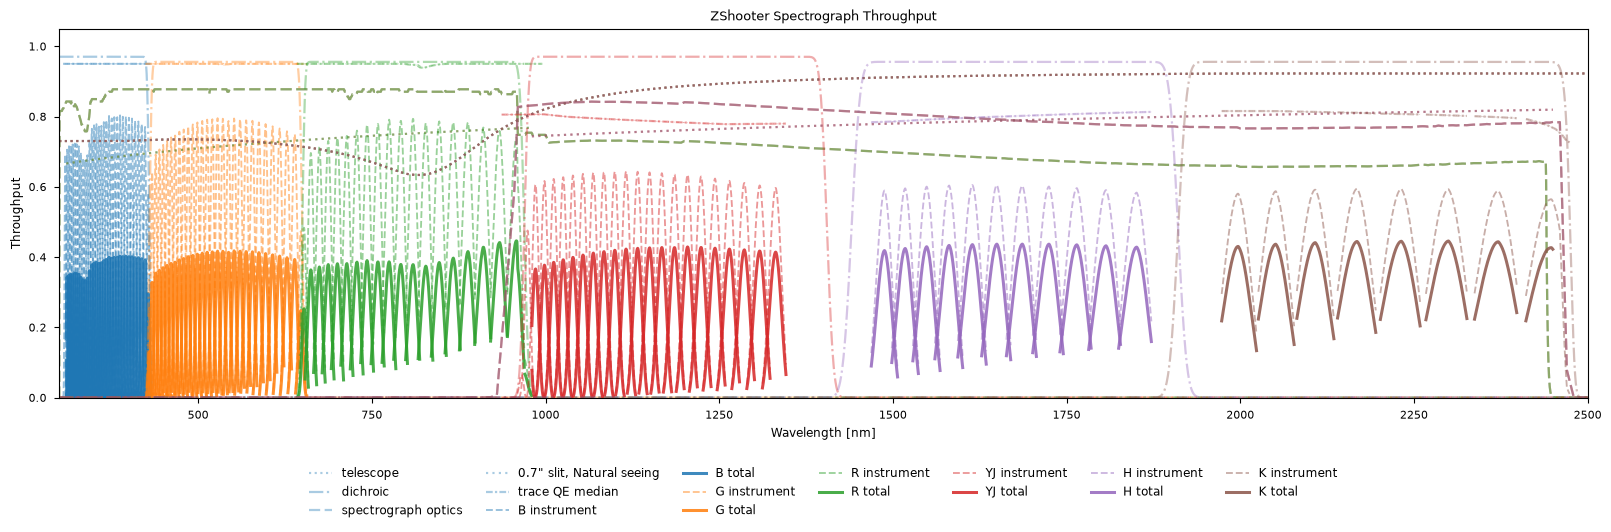

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/configured_transmission.pdf')

In [12]:
sim_wave_min_nm = u.Quantity(cmd_value("!SIM.spectral.wave_min"), u.um).to_value(u.nm)
sim_wave_max_nm = u.Quantity(cmd_value("!SIM.spectral.wave_max"), u.um).to_value(u.nm)
wave_nm = np.linspace(sim_wave_min_nm, sim_wave_max_nm, 5000) * u.nm
transmission_data = build_transmission_sanity_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_transmission_sanity_data(transmission_data)

TRANSMISSION_SHOW_INDIVIDUAL = False
TRANSMISSION_SHOW_COMBINED = True
TRANSMISSION_EXCLUDE_LINES = None
fig, axes = plot_transmission_sanity(transmission_data, slit_loss_data=slit_loss_data, summary_component_alpha=0.38, summary_component_linewidth=1.15, show_individual_channels=TRANSMISSION_SHOW_INDIVIDUAL, show_combined_channels=TRANSMISSION_SHOW_COMBINED, combined_title="ZShooter Spectrograph Throughput", exclude_lines=TRANSMISSION_EXCLUDE_LINES)
display_and_save_figure(fig, "configured_transmission")


In [13]:
def active_slit_transmission_for_channel(channel_label):
    arm_name = "VIS" if channel_label in ("B", "G", "R") else "NIR"
    arm = slit_loss_data["arms"][arm_name]
    curve = arm["curves"]["no_ao_current_adc_residual"]
    return np.interp(wave_values, arm["wave_nm"].to_value(u.nm), curve["throughput"], left=np.nan, right=np.nan)

throughput_rows = []
wave_values = transmission_data["wave_nm"].to_value(u.nm)
for aperture_id, channel in transmission_data["channels"].items():
    active_slit = active_slit_transmission_for_channel(channel["label"])
    order_peaks = []
    for trace_id, order in channel["orders"].items():
        total = np.asarray(order["total_with_telescope_no_slit"], dtype=float) * active_slit
        finite = np.isfinite(total)
        if not np.any(finite):
            continue
        peak_index = np.nanargmax(total)
        order_peaks.append((trace_id, wave_values[peak_index], total[peak_index]))
    best_trace, best_wave, best_throughput = max(order_peaks, key=lambda item: item[2])
    throughput_rows.append({
        "aperture_id": int(aperture_id),
        "channel": channel["label"],
        "best_order": best_trace,
        "best_wave_nm": best_wave,
        "peak_instrument_throughput": np.nanmax([np.nanmax(order["instrument"]) for order in channel["orders"].values()]),
        "peak_total_throughput": best_throughput,
        "peak_pre_disperser_instrument": np.nanmax(channel["pre_disperser_instrument_total"]),
        "peak_telescope_throughput": np.nanmax(channel["telescope_throughput"]),
        "order_qe_method": "; ".join(channel["order_detector_qe_methods"]),
    })
throughput_summary = Table(rows=throughput_rows)
display_frame(throughput_summary,
    columns=["channel", "best_order", "best_wave_nm", "peak_instrument_throughput", "peak_total_throughput", "peak_pre_disperser_instrument", "peak_telescope_throughput", "order_qe_method"],
    rename={
        "best_order": "best order",
        "best_wave_nm": "best wave [nm]",
        "peak_instrument_throughput": "peak instrument",
        "peak_total_throughput": "peak total with telescope+slit",
        "peak_pre_disperser_instrument": "peak pre-disperser instrument",
        "peak_telescope_throughput": "peak telescope",
        "order_qe_method": "detector QE used by orders",
    },
    formats={
        "best wave [nm]": "{:.0f}",
        "peak instrument": "{:.3f}",
        "peak total with telescope+slit": "{:.3f}",
        "peak pre-disperser instrument": "{:.3f}",
        "peak telescope": "{:.3f}",
    }
)


channel,best order,best wave [nm],peak instrument,peak total with telescope+slit,peak pre-disperser instrument,peak telescope,detector QE used by orders
B,b_94,388,0.803,0.403,0.852,0.923,slit-center trace detector pixels
G,g_66,552,0.795,0.418,0.839,0.923,slit-center trace detector pixels
R,r_38,958,0.794,0.446,0.839,0.923,slit-center trace detector pixels
YJ,yj_63,1204,0.644,0.429,0.817,0.923,slit-center trace detector pixels
H,h_45,1686,0.605,0.437,0.775,0.923,slit-center trace detector pixels
K,k_33,2300,0.595,0.446,0.749,0.923,slit-center trace detector pixels


In [14]:
wave_q = transmission_data["wave_nm"].to(u.nm)
wave = wave_q.to_value(u.nm)

def _a(x):
    return np.asarray(getattr(x, "value", x), dtype=float)

def _mean(x, mask=None):
    x = _a(x)
    ok = np.isfinite(x) if mask is None else (mask & np.isfinite(x))
    return float(np.nanmean(x[ok])) if np.any(ok) else np.nan

def _cat(arrs):
    vals = [_a(a)[np.isfinite(_a(a))] for a in arrs]
    vals = [v for v in vals if v.size]
    return np.concatenate(vals) if vals else np.array([], dtype=float)

try:
    _, atmosphere = fetch_effect_spectrum_or_transmission(zs, "atmo_transmission", wave=wave_q)
    atmosphere = _a(atmosphere)
except Exception:
    atmosphere = np.full(wave.size, np.nan)

try:
    _trace_eff = get_effect(zs, "trace_eff_analytical")
except Exception:
    _trace_eff = None

def _slit_curve(channel_label):
    arm = slit_loss_data["arms"]["VIS" if channel_label in ("B", "G", "R") else "NIR"]
    curve = arm["curves"]["no_ao_current_adc_residual"]
    return np.interp(wave, arm["wave_nm"].to_value(u.nm), curve["throughput"], left=np.nan, right=np.nan)

def _xdisp(trace_id):
    try:
        spec = _trace_eff._spectrographs[str(trace_id).partition("_")[0]]
        return _a(spec.xdisp_efficiency(wave_q.to(u.um)))
    except Exception:
        return np.full(wave.size, np.nan)

rows = []
for aperture_id, ch in transmission_data["channels"].items():
    order_masks = [np.isfinite(_a(o["disperser"])) for o in ch["orders"].values()]
    band_mask = np.logical_or.reduce(order_masks) if order_masks else np.zeros(wave.size, bool)

    optics_terms = [_a(v) for k, v in ch["instrument_optics_groups"].items() if k != "ir_blocking_filter"]
    optics = np.prod(optics_terms, axis=0) if optics_terms else np.ones(wave.size)

    trace_arrays = [_a(o["disperser"]) for o in ch["orders"].values()]
    qe_arrays = [_a(o["detector_qe"]) for o in ch["orders"].values()]
    xdisp_arrays = []
    for trace_id, order in ch["orders"].items():
        xdisp = _a(order["xdisperser"]) if "xdisperser" in order else _xdisp(trace_id)
        xdisp_arrays.append(np.where(np.isfinite(_a(order["disperser"])), xdisp, np.nan))

    trace_vals = _cat(trace_arrays)
    qe_vals = _cat(qe_arrays)
    xdisp_vals = _cat(xdisp_arrays)
    trace_peaks = [np.nanmax(a) for a in trace_arrays if np.isfinite(a).any()]

    rows.append({
        "band": ch["label"],
        "telescope": _mean(ch["telescope_throughput"], band_mask),
        "atmosphere": _mean(atmosphere, band_mask),
        "slit": _mean(_slit_curve(ch["label"]), band_mask),
        "dichroic": _mean(ch["dichroic_total"], band_mask),
        "optics": _mean(optics, band_mask),
        "trace peak efficiency": float(np.nanmean(trace_peaks)) if trace_peaks else np.nan,
        "mean trace efficiency FSR": float(np.nanmean(trace_vals)) if trace_vals.size else np.nan,
        "mean xdisperser efficiency": float(np.nanmean(xdisp_vals)) if xdisp_vals.size else np.nan,
        "mean QE": float(np.nanmean(qe_vals)) if qe_vals.size else np.nan,
    })
    rows[-1]['total excl atm.']=np.prod([rows[-1][k] for k in ('telescope','slit','dichroic','optics','trace peak efficiency','mean xdisperser efficiency','mean QE')])

throughput_component_means = pd.DataFrame(rows).set_index("band")
display(throughput_component_means.style.format("{:.3f}", na_rep="--"))

,telescope,atmosphere,slit,dichroic,optics,trace peak efficiency,mean trace efficiency FSR,mean xdisperser efficiency,mean QE,total excl atm.
band,,,,,,,,,,
B,0.731,0.685,0.682,0.948,0.851,0.969,0.348,0.976,0.950,0.361
G,0.730,0.909,0.716,0.903,0.877,0.954,0.483,0.959,0.950,0.360
R,0.701,0.960,0.751,0.865,0.860,0.956,0.663,0.959,0.949,0.341
YJ,0.864,0.962,0.758,0.892,0.814,0.969,0.495,0.972,0.791,0.354
H,0.917,0.888,0.789,0.956,0.790,0.988,0.683,0.988,0.800,0.427
K,0.923,0.920,0.811,0.951,0.758,0.989,0.785,0.989,0.803,0.423


## Source Construction And Slit Coordinates

Use the slit-frame convention consistently: `x` is along the slit length and `y` is across the slit width. There are two source-construction paths here, and they are not interchangeable. `scopesim_templates.star` should receive scalar coordinates, for example `x=0`, `y=0`; one-element lists create `(1, 1)` table columns in this environment and can break ScopeSim FOV extraction. Low-level table-backed sources should use one-dimensional arrays, as `field_angle_demo_sources` does internally. The cells below keep those conventions visible next to the source calls.

In [15]:
source_brightness_m_am = 20

# source_angle_on_slit = from_currsys("!OBS.pupil_angle", cmd) * u.deg if "!OBS.pupil_angle" in cmd else 0.0 * u.deg
# slit_demo_sources = field_angle_demo_sources(along_separation=5.0*u.arcsec, across_separation=0.9*u.arcsec, angle_on_slit=source_angle_on_slit, along_mag=source_brightness_m_am, across_mag=source_brightness_m_am)
star_on_slit_center = sim_tp.star('V',source_brightness_m_am*u.ABmag, spec_type="A0V", x=0, y=0, library="pyckles")
star_on_slit_plus2 = sim_tp.star('V',source_brightness_m_am*u.ABmag, spec_type="A0V", x=2, y=0, library="pyckles")
constant_photon_flat = constant_photon_flux_flat(amplitude=0.001, extent=60)
calibration_lamp = lamp_flat(resolving_power=80000, wave_step=0.05*u.AA, extent=60)

from scopesim.source.source import Source
from scopesim.source.source_templates import ab_spectrum
flat_ab_point_table = Table(data=[
        [0.0],                       # x: along slit
        [0.0],                       # y: across slit
        [1.0],                       # weight
        [0],                         # ref -> spectra[0]
        ["flat_ab_point_center"],
    ],
    names=["x", "y", "weight", "ref", "label"],
    units=[u.arcsec, u.arcsec, None, None, None]
)

flat_ab_point_center = Source(table=flat_ab_point_table, spectra=[ab_spectrum(mag=source_brightness_m_am)])
flat_ab_point_center_5min = Source(table=flat_ab_point_table, spectra=[ab_spectrum(mag=17)])


slit_validation_sources = OrderedDict()
slit_validation_sources["star_center"] = star_on_slit_center
slit_validation_sources["star_plus2_along_slit"] = star_on_slit_plus2
slit_validation_sources["flat_ab_point_center"] = flat_ab_point_center
# slit_validation_sources.update(slit_demo_sources)

source_to_observe = slit_validation_sources["flat_ab_point_center"]
# for name, source in slit_validation_sources.items():
#     print(name)
#     display_frame(source_position_table(source))
#
# fig, axes = PlotScene(spectrum_yscale="log").from_source(source_to_observe, individual=True)


## Background Budget: Sky, Telescope, Instrument, Detector

The goal here is not just to list components but to make them comparable. The emissivity and post-disperser diffuse tables report photon/electron rates in detector-relevant units, while the detailed surface rows remain available for debugging. Telescope mirror emission must appear as a pre-disperser term; if it disappears, the optical accounting is incomplete.

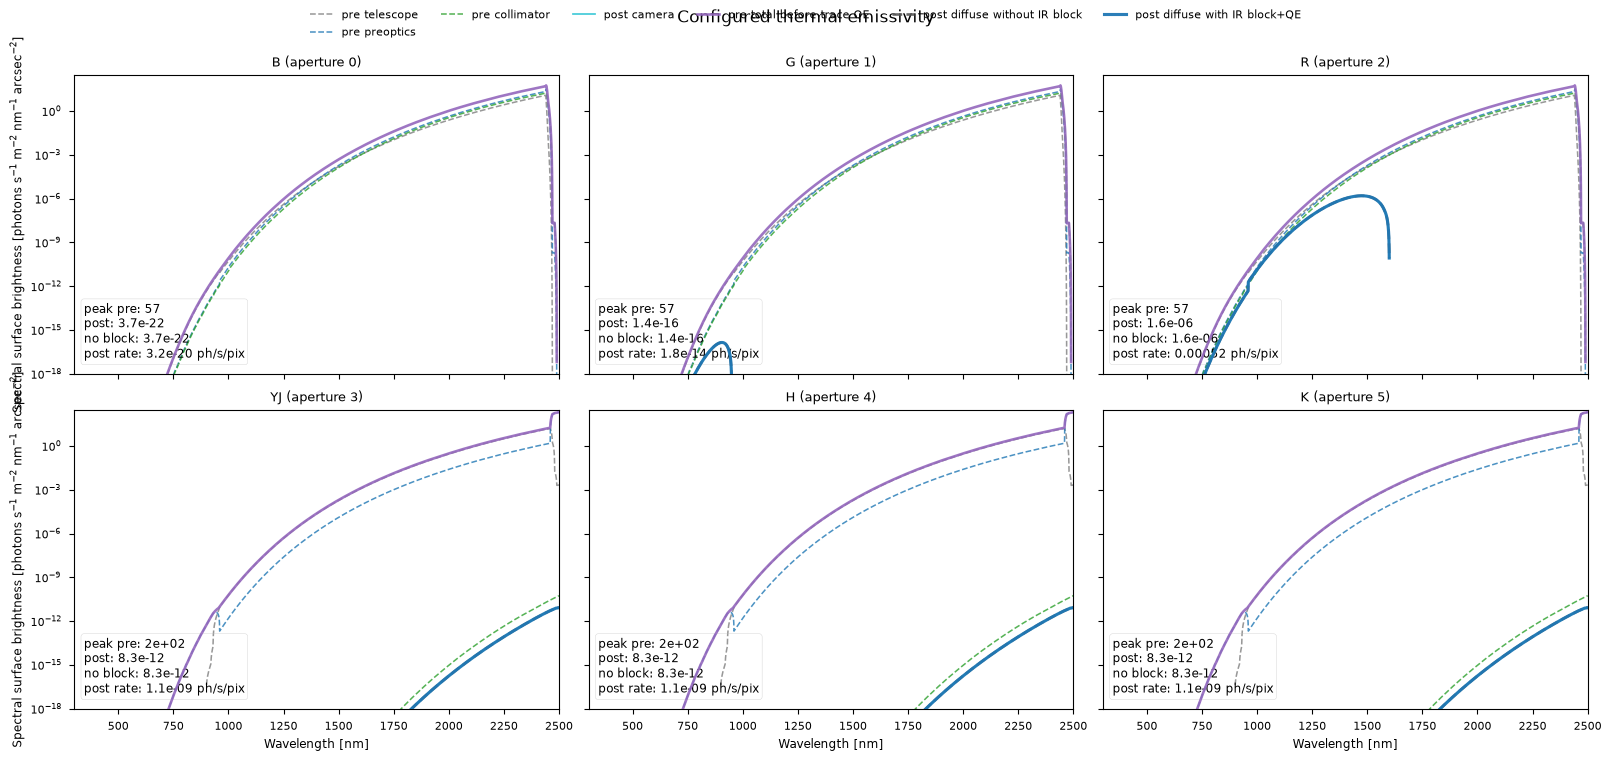

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/configured_emissivity.pdf')

In [16]:
emissivity_data = build_emissivity_sanity_data(zs, wave_nm=wave_nm, qe_selector_name=None, component_metadata=component_metadata)
validate_emissivity_sanity_data(emissivity_data)
fig, axes = plot_emissivity_sanity(emissivity_data)
fig.suptitle("Configured thermal emissivity")
display_and_save_figure(fig, "configured_emissivity")

In [17]:
emissivity_rows = []
for aperture_id, channel in emissivity_data["channels"].items():
    telescope = channel["pre_disperser_terms"].get("telescope", np.zeros_like(channel["pre_disperser_output_equiv"]))
    pre_no_telescope = channel["pre_disperser_output_equiv"] - telescope
    emissivity_rows.append({
        "aperture_id": int(aperture_id),
        "channel": channel["label"],
        "peak_telescope_thermal_photlam_equiv": np.nanmax(telescope),
        "peak_other_pre_disperser_photlam_equiv": np.nanmax(pre_no_telescope),
        "peak_post_after_qe_photlam_equiv": np.nanmax(channel["post_disperser_after_qe"]),
    })
emissivity_summary = Table(rows=emissivity_rows)
display_frame(emissivity_summary,
    columns=["channel", "peak_telescope_thermal_photlam_equiv", "peak_other_pre_disperser_photlam_equiv", "peak_post_after_qe_photlam_equiv"],
    rename={
        "peak_telescope_thermal_photlam_equiv": "peak telescope thermal [ph/s/cm2/A equiv]",
        "peak_other_pre_disperser_photlam_equiv": "peak other pre-disperser [ph/s/cm2/A equiv]",
        "peak_post_after_qe_photlam_equiv": "peak post-disperser after QE [ph/s/cm2/A equiv]",
    },
    formats={
        "peak telescope thermal [ph/s/cm2/A equiv]": "{:.3e}",
        "peak other pre-disperser [ph/s/cm2/A equiv]": "{:.3e}",
        "peak post-disperser after QE [ph/s/cm2/A equiv]": "{:.3e}",
    }
)

surface_debug_columns = ["channel", "component", "surface", "group", "emission_phase", "action", "temperature", "emissivity_source", "transmission_source", "peak_after_qe"]
display_frame(emissivity_data["details"],
    columns=surface_debug_columns,
    rename={
        "emission_phase": "emission phase",
        "temperature": "temperature [K]",
        "emissivity_source": "emissivity source",
        "transmission_source": "transmission source",
        "peak_after_qe": "peak after QE [ph/s/cm2/A equiv]",
    },
    formats={"temperature [K]": "{:.0f}", "peak after QE [ph/s/cm2/A equiv]": "{:.3e}"}
)


channel,peak telescope thermal [ph/s/cm2/A equiv],peak other pre-disperser [ph/s/cm2/A equiv],peak post-disperser after QE [ph/s/cm2/A equiv]
B,1.190e-04,5.135e-04,3.689e-27
G,1.190e-04,5.135e-04,1.403e-21
R,1.190e-04,5.135e-04,1.570e-11
YJ,1.598e-04,2.027e-03,8.311e-17
H,1.598e-04,2.027e-03,8.311e-17
K,1.598e-04,2.027e-03,8.311e-17


channel,component,surface,group,emission phase,action,temperature [K],emissivity source,transmission source,peak after QE [ph/s/cm2/A equiv]
B,telescope_reflection,M1,telescope,pre_disperser,reflection,4 deg_C,inferred from reflection,inferred from reflection,3.861e-05
B,telescope_reflection,M2,telescope,pre_disperser,reflection,4 deg_C,inferred from reflection,inferred from reflection,3.966e-05
B,telescope_reflection,M3,telescope,pre_disperser,reflection,4 deg_C,inferred from reflection,inferred from reflection,4.074e-05
B,channel_optics_selector,VIS_Fold,preoptics,pre_disperser,reflection,0 deg_C,inferred from reflection,inferred from reflection,2.761e-05
B,channel_optics_selector,VIS_PreOptFirst,preoptics,pre_disperser,transmission,0 deg_C,inferred from transmission,explicit,5.515e-05
B,channel_optics_selector,VIS_ADC_12,preoptics,pre_disperser,transmission,0 deg_C,inferred from transmission,explicit,6.207e-05
B,channel_optics_selector,VIS_ADC_34,preoptics,pre_disperser,transmission,0 deg_C,inferred from transmission,explicit,7.043e-05
B,channel_optics_selector,VIS_Derotator_Refl_1,preoptics,pre_disperser,reflection,0 deg_C,inferred from reflection,inferred from reflection,3.005e-05
B,channel_optics_selector,VIS_Derotator_Refl_2,preoptics,pre_disperser,reflection,0 deg_C,inferred from reflection,inferred from reflection,3.079e-05
B,channel_optics_selector,VIS_Derotator_Refl_3,preoptics,pre_disperser,reflection,0 deg_C,inferred from reflection,inferred from reflection,3.154e-05


In [18]:
qe_accounting = detector_qe_accounting_table(transmission_data, emissivity_data)
display_frame(qe_accounting)

detector_geometry = detector_geometry_table(zs)
display_frame(detector_geometry)
display_frame(detector_selector_matrix(zs))


path,aperture_id,channel,qe_model,trace_mapped_qe,transmission_plot_qe,diffuse_qe,diffuse_position_samples,order_qe_methods,position_axis,position_min,position_max
transmission_trace_mapped,0,B,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,slit-center trace detector pixels,y,0,2048
transmission_trace_mapped,1,G,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,slit-center trace detector pixels,y,0,2048
transmission_trace_mapped,2,R,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,slit-center trace detector pixels,y,0,2048
transmission_trace_mapped,3,YJ,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,slit-center trace detector pixels,nan,None,None
transmission_trace_mapped,4,H,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,slit-center trace detector pixels,nan,None,None
transmission_trace_mapped,5,K,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,slit-center trace detector pixels,nan,None,None
emissivity_sanity,0,B,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,,y,0,2048
emissivity_sanity,1,G,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,,y,0,2048
emissivity_sanity,2,R,TaperedQuantumEfficiency,per-pixel detector coordinates from trace mapping,footprint/detector-axis average shown for display; order totals use slit-center trace detector coordinates,mean over uniformly sampled detector-axis positions,!INST.tapered_qe_diffuse_position_samples,,y,0,2048
emissivity_sanity,3,YJ,SpectralQuantumEfficiency,per-pixel detector coordinates from trace mapping,same wavelength-only spectral throughput used for all orders,wavelength-only spectral throughput,nan,,nan,None,None


detector_id,image_plane_id,channel,detector,x_size,y_size,pixel_size_mm,gain_e_per_adu
0,0,B,CCD_B,2048,4096,0.015000,1.000000
1,1,G,CCD_G,2048,4096,0.015000,1.000000
2,2,R,CCD_R,2048,4096,0.015000,1.000000
3,3,YJ,APD_YJ,2048,2048,0.015000,1.000000
4,4,H,APD_H,2048,2048,0.015000,1.000000
5,5,K,APD_K,2048,2048,0.015000,1.000000


detector_id,channel,detector,selector,selector_key,selector_value,effect_class,settings
0,B,CCD_B,slitwheel_selector,aperture_id,0,SlitWheel,"filename=None, current_slit=0.7"
0,B,CCD_B,channel_optics_selector,aperture_id,0,SurfaceList,filename=optics/LIST_zspec_vis_optics.dat
0,B,CCD_B,detector_qe_selector,aperture_id,0,TaperedQuantumEfficiency,filename=None
0,B,CCD_B,exposure_integration_selector,detector_id,0,ExposureIntegration,"filename=None, dit=1800, ndit=2"
0,B,CCD_B,dark_current_selector,detector_id,0,DarkCurrent,"filename=None, dit=1800, ndit=2, value=0.000166"
0,B,CCD_B,readout_noise_selector,detector_id,0,BasicReadoutNoise,"filename=None, ndit=2, noise_std=0.1"
0,B,CCD_B,visible_binning_selector,detector_id,0,UnequalBinnedImage,"filename=None, binx=1, biny=1"
0,B,CCD_B,bias_selector,detector_id,0,Bias,"filename=None, bias=1040"
1,G,CCD_G,slitwheel_selector,aperture_id,1,SlitWheel,"filename=None, current_slit=0.7"
1,G,CCD_G,channel_optics_selector,aperture_id,1,SurfaceList,filename=optics/LIST_zspec_vis_optics.dat


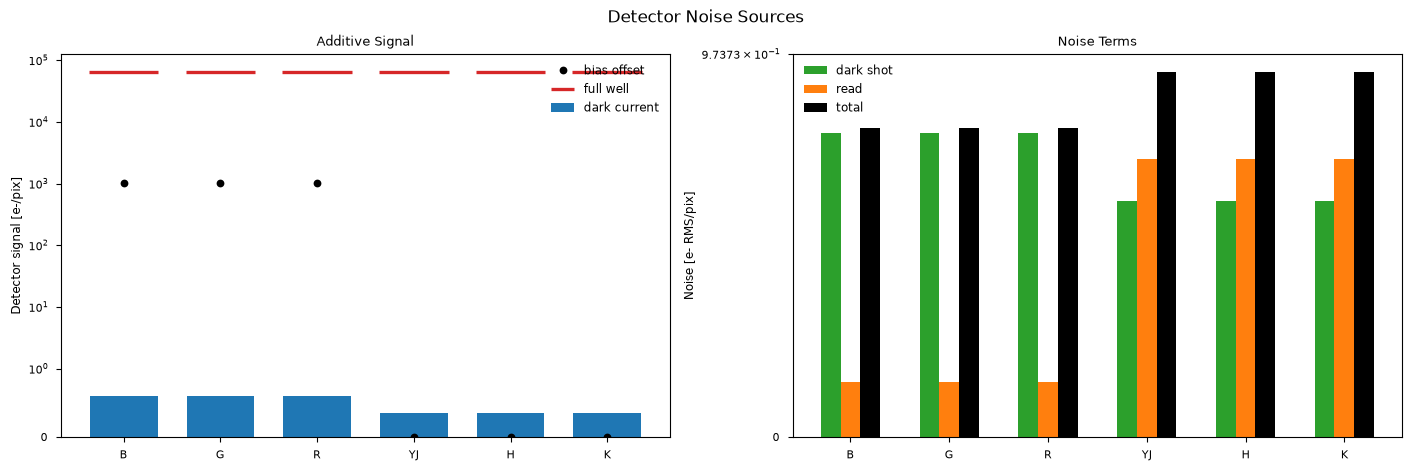

channel,detector,dit_s,ndit,exposure_time_s,dark_current_e_s_pix,dark_current_e_pix,bias_e_pix,read_noise_e_rms,dark_shot_noise_e_rms,total_noise_e_rms
B,CCD_B,1800.000000,2.000000,3600.000000,0.000166,0.597600,1040.000000,0.141421,0.773046,0.785875
G,CCD_G,1800.000000,2.000000,3600.000000,0.000166,0.597600,1040.000000,0.141421,0.773046,0.785875
R,CCD_R,1800.000000,2.000000,3600.000000,0.000166,0.597600,1040.000000,0.141421,0.773046,0.785875
YJ,APD_YJ,1800.000000,2.000000,3600.000000,0.000100,0.360000,0.000000,0.707107,0.600000,0.927362
H,APD_H,1800.000000,2.000000,3600.000000,0.000100,0.360000,0.000000,0.707107,0.600000,0.927362
K,APD_K,1800.000000,2.000000,3600.000000,0.000100,0.360000,0.000000,0.707107,0.600000,0.927362


In [19]:
detector_budget = detector_background_budget_table(zs)
fig, axes = plot_detector_background_budget(detector_budget)
fig.suptitle("Detector Noise Sources")
display_and_save_figure(fig, "detector_background")
display_frame(detector_budget,
    columns=[
        "channel", "detector", "dit_s", "ndit", "exposure_time_s",
        "dark_current_e_s_pix", "dark_current_e_pix", "bias_e_pix",
        "read_noise_e_rms", "dark_shot_noise_e_rms", "total_noise_e_rms",
    ]
)


## Sky Spectrum Components

This plots the active PALACE/ScopeSim sky components from the configured train. `atmo_transmission` is multiplicative; with no source and sky emission disabled, it multiplies zero and has no impact on a background-only readout. Its thermal `emission` term is still an additive sky-background component. ScopeSim/Synphot emission spectra are PHOTLAM-like and are treated by ScopeSim's diffuse-background integrator as per square arcsecond.

The photon figure converts the cumulative sky surface brightness to photon spectral rate through a finite comparison extraction. The six configured band summaries supply deliberately selected one-FWHM spatial apertures; linear interpolation through their reference wavelengths gives one continuous, channel-agnostic aperture curve. The flat-AB point-source references use the corresponding finite two-dimensional aperture throughput, not an equivalent surface brightness.

The AB figure remains the continuous cumulative sky surface brightness in AB mag arcsec$^{-2}$ and contains no point-source reference. Collecting area and extraction area do not enter that conversion. `SKY_NOMINAL_RESOLVING_POWER` controls a constant-$R$ convolution on a logarithmic wavelength grid; the printed conservation ratios verify integrated photon flux before and after convolution.

sky continuum            common-interval photon ratio = 0.99999903
interline continuum      common-interval photon ratio = 0.99999996
atmospheric thermal      common-interval photon ratio = 0.99999946
airglow lines            common-interval photon ratio = 1.00000000


samples per FWHM,recovered area / input,recovered peak / expected
8,1.00000000,1.00000000
16,1.00000000,1.00000000


Largest extraction-minus-10-arcsec-slit throughput difference = -1.8317e-01; allowed tolerance for the 0.04 arcsec grid = 5.0e-03.


channel,wavelength [nm],slit throughput,spatial aperture [arcsec],extraction area [arcsec2],extraction throughput,flat AB=19.5 source rate [ph/s/nm],cumulative sky rate [ph/s/nm],cumulative sky [AB/arcsec2],sky/source
B,388,0.687,0.733,0.513,0.503,86.3,16.1,21.34,0.187
G,552,0.718,0.680,0.476,0.495,59.6,19.3,20.68,0.324
R,958,0.766,0.627,0.439,0.545,37.8,9.29,20.79,0.246
YJ,1204,0.761,0.585,0.409,0.570,31.4,10.8,20.30,0.343
H,1686,0.790,0.541,0.379,0.545,21.5,11.3,19.80,0.525
K,2300,0.815,0.512,0.358,0.584,16.9,161,16.52,9.52


Each of the 2,500 display bins averages 15.3 nominal R=18,000 elements; narrow-line photons are conserved, but individual peaks are intentionally averaged.
sky continuum            305,319 -> 2,500 points; photon-rate ratio = 1.0000000000; surface-brightness ratio = 1.0000000000
interline continuum      305,319 -> 2,500 points; photon-rate ratio = 1.0000000000; surface-brightness ratio = 1.0000000000
atmospheric thermal      305,319 -> 2,500 points; photon-rate ratio = 1.0000000000; surface-brightness ratio = 1.0000000000
airglow lines            305,319 -> 2,500 points; photon-rate ratio = 1.0000000000; surface-brightness ratio = 1.0000000000


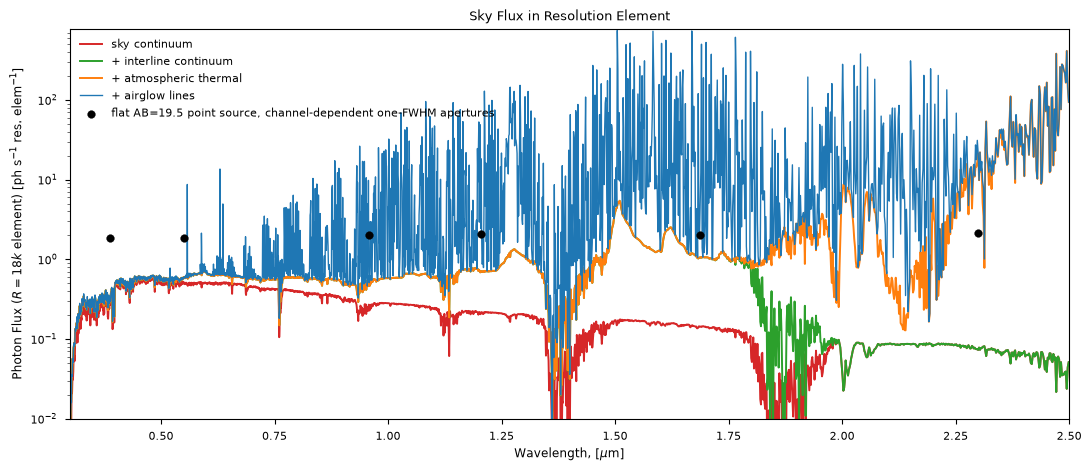

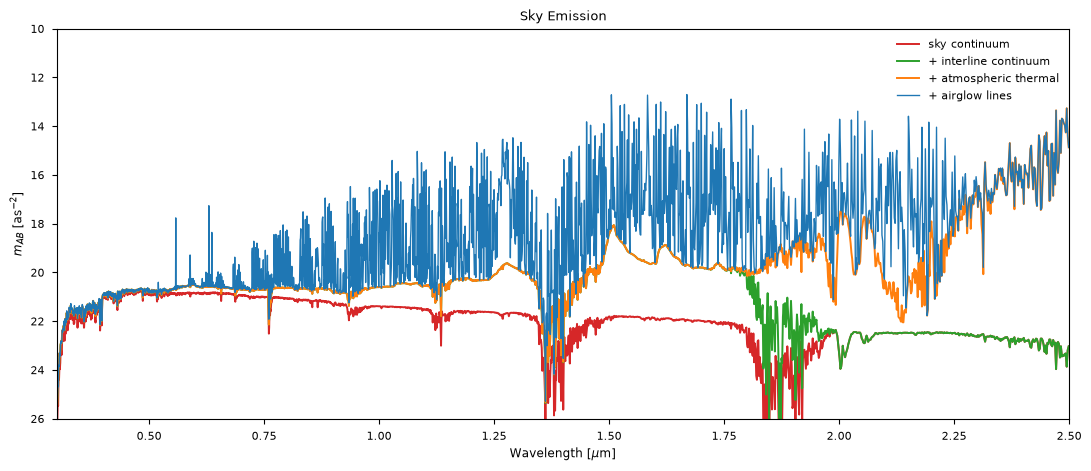

At 1.25 um: 16.4813 ph s^-1 m^-2 nm^-1 arcsec^-2 = 16.0622 AB mag arcsec^-2 (direct - helper = +0.000e+00 mag)


In [20]:
from scipy.ndimage import gaussian_filter1d
from synphot.units import PHOTLAM

PHOTLAM_TO_PH_S_M2_NM_ARCSEC2 = 1e5
SKY_WAVE_MIN_UM = 0.3
SKY_WAVE_MAX_UM = 2.5
SKY_NOMINAL_RESOLVING_POWER = 18_000  # set to None for configured native sampling
SKY_SAMPLES_PER_RESOLUTION_ELEMENT = 8
SKY_CONVOLUTION_PADDING_FWHM = 8
SKY_CONSERVATION_RTOL = 5e-3
SKY_REFERENCE_SOURCE_ABMAG = 19.5
SKY_REFERENCE_SOURCE_LABEL = f"flat AB={SKY_REFERENCE_SOURCE_ABMAG:g} point source, " "channel-dependent one-FWHM apertures"
SKY_THROUGHPUT_GRID_ATOL = 5e-3  # permits an edge-cell mismatch on the 0.04-arcsec grid
SKY_PHOTON_RATE_YMIN = 1e-2
SKY_COMPONENT_ORDER = ("sky continuum", "interline continuum", "atmospheric thermal", "airglow lines")
SKY_EFFECTS = OrderedDict([
    ("sky continuum", ("continuum_emission", "emission")),
    ("interline continuum", ("airglow_and_interline_continuum", "continuum_TER.emission")),
    ("atmospheric thermal", ("atmo_transmission", "emission")),
    ("airglow lines", ("airglow_and_interline_continuum", "line_TER.emission")),
])
SKY_COLORS = OrderedDict([
    ("sky continuum", "tab:red"),
    ("interline continuum", "tab:green"),
    ("atmospheric thermal", "tab:orange"),
    ("airglow lines", "tab:blue"),
])
SKY_PHOTON_YLABEL = r"Photon Flux ($R=18k$ element) [ph s$^{-1}$ res. elem$^{-1}$]"
SKY_AB_YLABEL = r"$m_{AB}$ [as$^{-2}$]"


def fetch_sky_component(effect_name_text, attribute, nominal_resolving_power=None):
    wave, values = fetch_effect_spectrum_or_transmission(zs, effect_name_text, attribute)
    wave_um = wave.to_value(u.um)
    photon_flux = u.Quantity(values).to_value(PHOTLAM) * PHOTLAM_TO_PH_S_M2_NM_ARCSEC2
    if nominal_resolving_power is None:
        return wave_um, photon_flux, None

    dlog_wave = 1 / (nominal_resolving_power * SKY_SAMPLES_PER_RESOLUTION_ELEMENT)
    padding_log_wave =SKY_CONVOLUTION_PADDING_FWHM / nominal_resolving_power
    native_log_min = np.log(wave_um[0])
    native_log_max = np.log(wave_um[-1])
    padded_log_wave = np.arange(native_log_min - padding_log_wave, native_log_max + padding_log_wave + dlog_wave, dlog_wave)
    padded_wave_um = np.exp(padded_log_wave)
    native_photon_flux = np.interp(padded_wave_um, wave_um, photon_flux, left=0, right=0)
    flux_per_log_wave = padded_wave_um * native_photon_flux
    sigma_log_wave = 1 / (2 * np.sqrt(2 * np.log(2)) * nominal_resolving_power)
    convolved_flux_per_log_wave = gaussian_filter1d(flux_per_log_wave, sigma=sigma_log_wave / dlog_wave, mode="constant", cval=0, truncate=SKY_CONVOLUTION_PADDING_FWHM * 2 * np.sqrt(2 * np.log(2)))
    convolved_photon_flux = convolved_flux_per_log_wave / padded_wave_um
    common = (padded_log_wave >= native_log_min) & (padded_log_wave <= native_log_max)
    common_wave_um = padded_wave_um[common]
    native_integral = np.trapezoid(native_photon_flux[common], common_wave_um)
    convolved_integral = np.trapezoid(convolved_photon_flux[common], common_wave_um)
    conservation = convolved_integral / native_integral
    return common_wave_um, convolved_photon_flux[common], conservation


def sky_photon_flux_to_ab_surface_brightness(wave_um, photon_flux):
    wave = wave_um * u.um
    photon_spectral_surface_brightness = photon_flux * u.photon / (u.s * u.m**2 * u.nm * u.arcsec**2)
    energy_spectral_surface_brightness = photon_spectral_surface_brightness / u.photon * const.h * const.c / wave
    fnu = energy_spectral_surface_brightness.to(u.Jy / u.arcsec**2,  equivalencies=u.spectral_density(wave))
    return -2.5 * np.log10(fnu.to_value(u.Jy / u.arcsec**2) / 3631)


sky_components = OrderedDict()
for label in SKY_COMPONENT_ORDER:
    effect_name_text, attribute = SKY_EFFECTS[label]
    component_wave_um, component_flux, conservation = fetch_sky_component(effect_name_text, attribute, SKY_NOMINAL_RESOLVING_POWER)
    sky_components[label] = (component_wave_um, component_flux)
    if conservation is not None:
        print(f"{label:24s} common-interval photon ratio = " f"{conservation:.8f}")
        np.testing.assert_allclose(conservation, 1, rtol=SKY_CONSERVATION_RTOL, atol=0)

# An isolated line tests both the normalized kernel area and the expected
# R-dependent peak height without using any configured sky component.
line_check_rows = []
line_wave_um = 1.25
line_integrated_flux = 1.0
sigma_log_wave = 1 / (2 * np.sqrt(2 * np.log(2)) * SKY_NOMINAL_RESOLVING_POWER)

for samples_per_fwhm in (SKY_SAMPLES_PER_RESOLUTION_ELEMENT, 2 * SKY_SAMPLES_PER_RESOLUTION_ELEMENT):
    dlog_wave = 1 / (SKY_NOMINAL_RESOLVING_POWER * samples_per_fwhm)
    check_log_wave = np.arange(np.log(line_wave_um) - 12 / SKY_NOMINAL_RESOLVING_POWER, np.log(line_wave_um) + 12 / SKY_NOMINAL_RESOLVING_POWER + dlog_wave, dlog_wave)
    check_wave_um = np.exp(check_log_wave)
    line_per_log_wave = np.zeros_like(check_wave_um)
    line_index = int(np.argmin(np.abs(check_log_wave - np.log(line_wave_um))))
    line_per_log_wave[line_index] = line_integrated_flux / dlog_wave
    convolved_line_per_log_wave = gaussian_filter1d(line_per_log_wave, sigma=sigma_log_wave / dlog_wave, mode="constant", cval=0, truncate=SKY_CONVOLUTION_PADDING_FWHM  * 2 * np.sqrt(2 * np.log(2)))
    convolved_line_flux = convolved_line_per_log_wave / check_wave_um
    recovered_area = np.trapezoid( convolved_line_flux, check_wave_um)
    expected_peak = line_integrated_flux / (line_wave_um * sigma_log_wave * np.sqrt(2 * np.pi))
    recovered_peak = np.max(convolved_line_flux)
    line_check_rows.append({
        "samples per FWHM": samples_per_fwhm,
        "recovered area / input": recovered_area / line_integrated_flux,
        "recovered peak / expected": recovered_peak / expected_peak,
    })

line_check_table = Table(rows=line_check_rows)
display_frame(line_check_table, formats={"recovered area / input": "{:.8f}", "recovered peak / expected": "{:.8f}"})

np.testing.assert_allclose(line_check_table["recovered area / input"], 1, rtol=SKY_CONSERVATION_RTOL, atol=0)
np.testing.assert_allclose(line_check_table["recovered peak / expected"], 1, rtol=SKY_CONSERVATION_RTOL, atol=0)

dlog_wave = 1 / (SKY_NOMINAL_RESOLVING_POWER * SKY_SAMPLES_PER_RESOLUTION_ELEMENT)
sky_wave_um = np.exp(np.arange(np.log(SKY_WAVE_MIN_UM), np.log(SKY_WAVE_MAX_UM) + dlog_wave, dlog_wave))
cumulative_fluxes = OrderedDict()
running_flux = np.zeros_like(sky_wave_um)
displayed_component_sum = np.zeros_like(sky_wave_um)
for label in SKY_COMPONENT_ORDER:
    component_wave_um, component_flux = sky_components[label]
    displayed_component = np.interp(sky_wave_um, component_wave_um, component_flux, left=0, right=0)
    displayed_component_sum = displayed_component_sum + displayed_component
    running_flux = running_flux + displayed_component
    cumulative_fluxes[label] = running_flux.copy()

np.testing.assert_allclose(cumulative_fluxes[SKY_COMPONENT_ORDER[-1]], displayed_component_sum)

sky_surface_brightness_unit = u.photon / (u.s * u.m**2 * u.nm * u.arcsec**2)
sky_photon_rate_unit = u.photon / (u.s * u.nm)
sky_collecting_area = u.Quantity(from_currsys("!TEL.area", zs.cmds)).to(u.m**2)
configured_slit_widths =  np.asarray(trace_resolution_summary["active_slit_width_arcsec"], dtype=float) * u.arcsec

np.testing.assert_allclose(configured_slit_widths.to_value(u.arcsec), configured_slit_widths[0].to_value(u.arcsec))

sky_active_slit_width = configured_slit_widths[0]

reference_rows = []
fnu_reference = 3631 * u.Jy * 10**(-0.4 * SKY_REFERENCE_SOURCE_ABMAG)
for throughput_row in throughput_summary:
    channel = str(throughput_row["channel"])
    wave_nm_reference = float(throughput_row["best_wave_nm"])
    summary_row = trace_resolution_summary[np.asarray(trace_resolution_summary["channel"], dtype=str) == channel][0]
    arm_name = "VIS" if channel in ("B", "G", "R") else "NIR"
    slit_key = "!INST.vis_curr_slit" if arm_name == "VIS" else "!INST.nir_curr_slit"
    arm = slit_loss_data["arms"][arm_name]
    active_curves = [curve for curve in arm["curves"].values() if "alias_for" not in curve and curve["current_psf"] and curve["current_slit"] and curve["current_airmass"] and curve["current_adc"]]
    assert len(active_curves) == 1
    slit_throughput = np.interp(wave_nm_reference, arm["wave_nm"].to_value(u.nm), active_curves[0]["throughput"])

    slit_width = float(summary_row["active_slit_width_arcsec"]) * u.arcsec
    spatial_aperture = float(summary_row["seeing_fwhm_median_arcsec"]) * u.arcsec
    extraction_solid_angle = slit_width * spatial_aperture
    extraction_wave_range = float(summary_row["wave_min_nm"]) * u.nm, float(summary_row["wave_max_nm"]) * u.nm, slit_key
    extraction_loss_data = build_slit_loss_data(zs, arms=OrderedDict([(channel, extraction_wave_range)]), n_wave=SLIT_LOSS_SAMPLES, slit_length=spatial_aperture, grid_step=SLIT_LOSS_GRID_STEP)
    extraction_arm = extraction_loss_data["arms"][channel]
    extraction_active_curves = [curve for curve in extraction_arm["curves"].values() if "alias_for" not in curve and curve["current_psf"] and curve["current_slit"] and curve["current_airmass"] and curve["current_adc"]]
    assert len(extraction_active_curves) == 1
    extraction_curve = extraction_active_curves[0]
    extraction_wave_nm = extraction_arm["wave_nm"].to(u.nm)
    extraction_throughput_values = extraction_curve["throughput"].copy()
    extraction_throughput = np.interp(wave_nm_reference, extraction_wave_nm.to_value(u.nm), extraction_throughput_values)

    wave_reference = wave_nm_reference * u.nm
    source_energy_density = fnu_reference.to(u.W / (u.m**2 * u.nm), equivalencies=u.spectral_density(wave_reference))
    source_photon_density = (source_energy_density / (const.h * const.c / wave_reference) * u.photon).to(u.photon / (u.s * u.m**2 * u.nm))
    source_photon_rate = (source_photon_density * sky_collecting_area * extraction_throughput).to(sky_photon_rate_unit)
    cumulative_sky_surface_brightness = np.interp(wave_nm_reference / 1000, sky_wave_um, cumulative_fluxes[SKY_COMPONENT_ORDER[-1]]) * sky_surface_brightness_unit
    cumulative_sky_rate = (cumulative_sky_surface_brightness * sky_collecting_area * extraction_solid_angle).to(sky_photon_rate_unit)
    reference_rows.append({
        "channel": channel,
        "wavelength_nm": wave_nm_reference,
        "slit_throughput": slit_throughput,
        "spatial_aperture_arcsec": spatial_aperture.to_value(u.arcsec),
        "extraction_area_arcsec2": extraction_solid_angle.to_value(u.arcsec**2),
        "extraction_throughput": extraction_throughput,
        "source_photon_rate": source_photon_rate.to_value(sky_photon_rate_unit),
        "cumulative_sky_photon_rate": cumulative_sky_rate.to_value(sky_photon_rate_unit),
        "cumulative_sky_ab_arcsec2": (
            sky_photon_flux_to_ab_surface_brightness(np.array([wave_nm_reference / 1000]), np.array([cumulative_sky_surface_brightness.to_value(sky_surface_brightness_unit)]))[0]
        ),
        "sky_to_source": (cumulative_sky_rate / source_photon_rate).to_value(u.dimensionless_unscaled),
    })

sky_reference_table = Table(rows=reference_rows)
reference_wave_um = np.asarray(sky_reference_table["wavelength_nm"], dtype=float) / 1000
reference_spatial_aperture_arcsec = np.asarray(sky_reference_table["spatial_aperture_arcsec"], dtype=float)
assert np.all(np.diff(reference_wave_um) > 0)
sky_spatial_aperture = np.interp(sky_wave_um, reference_wave_um, reference_spatial_aperture_arcsec) * u.arcsec
np.testing.assert_allclose(np.interp(reference_wave_um, reference_wave_um, reference_spatial_aperture_arcsec), reference_spatial_aperture_arcsec)
sky_extraction_solid_angle = sky_active_slit_width * sky_spatial_aperture
sky_rates = OrderedDict()
for label in SKY_COMPONENT_ORDER:
    cumulative_sky_surface_brightness = cumulative_fluxes[label] * sky_surface_brightness_unit
    sky_rates[label] = (cumulative_sky_surface_brightness * sky_collecting_area * sky_extraction_solid_angle).to(sky_photon_rate_unit)

throughput_excess = np.asarray(sky_reference_table["extraction_throughput"], dtype=float) - np.asarray(sky_reference_table["slit_throughput"], dtype=float)
largest_throughput_excess = np.max(throughput_excess)
print(f"Collecting area = {sky_collecting_area:.3f}; " f"active slit width = {sky_active_slit_width:.3f}")
print("Largest extraction-minus-10-arcsec-slit throughput difference = " f"{largest_throughput_excess:+.4e}; allowed tolerance for the " f"{SLIT_LOSS_GRID_STEP:.2f} grid = {SKY_THROUGHPUT_GRID_ATOL:.1e}.")
assert largest_throughput_excess <= SKY_THROUGHPUT_GRID_ATOL
assert sky_rates[SKY_COMPONENT_ORDER[-1]].unit.is_equivalent(sky_photon_rate_unit)

display_frame(sky_reference_table,
    columns=[
        "channel",
        "wavelength_nm",
        "slit_throughput",
        "spatial_aperture_arcsec",
        "extraction_area_arcsec2",
        "extraction_throughput",
        "source_photon_rate",
        "cumulative_sky_photon_rate",
        "cumulative_sky_ab_arcsec2",
        "sky_to_source",
    ],
    rename={
        "wavelength_nm": "wavelength [nm]",
        "slit_throughput": "slit throughput",
        "spatial_aperture_arcsec": "spatial aperture [arcsec]",
        "extraction_area_arcsec2": "extraction area [arcsec2]",
        "extraction_throughput": "extraction throughput",
        "source_photon_rate": f"flat AB={SKY_REFERENCE_SOURCE_ABMAG:g} source rate [ph/s/nm]",
        "cumulative_sky_photon_rate": "cumulative sky rate [ph/s/nm]",
        "cumulative_sky_ab_arcsec2": "cumulative sky [AB/arcsec2]",
        "sky_to_source": "sky/source",
    },
    formats={
        "wavelength [nm]": "{:.0f}",
        "slit throughput": "{:.3f}",
        "spatial aperture [arcsec]": "{:.3f}",
        "extraction area [arcsec2]": "{:.3f}",
        "extraction throughput": "{:.3f}",
        f"flat AB={SKY_REFERENCE_SOURCE_ABMAG:g} source rate [ph/s/nm]": "{:.3g}",
        "cumulative sky rate [ph/s/nm]": "{:.3g}",
        "cumulative sky [AB/arcsec2]": "{:.2f}",
        "sky/source": "{:.3g}",
    }
)

reference_photon_rate = np.asarray(sky_reference_table["source_photon_rate"], dtype=float)

from scipy.integrate import cumulative_trapezoid

sky_wave_nm = sky_wave_um * 1000
sky_plot_edges_nm = np.geomspace(sky_wave_nm[0], sky_wave_nm[-1], 2501)
sky_plot_wave_nm = np.sqrt(sky_plot_edges_nm[:-1] * sky_plot_edges_nm[1:])
sky_plot_wave_um = sky_plot_wave_nm / 1000
resolution_elements_per_display_bin = SKY_NOMINAL_RESOLVING_POWER * np.log(sky_plot_edges_nm[1:] / sky_plot_edges_nm[:-1])
sky_plot_photons_per_resel = OrderedDict()
sky_plot_surface_brightness = OrderedDict()
print(f"Each of the 2,500 display bins averages " f"{np.mean(resolution_elements_per_display_bin):.1f} nominal R={SKY_NOMINAL_RESOLVING_POWER:,} elements; " "narrow-line photons are conserved, but individual peaks are intentionally averaged.")
for label in SKY_COMPONENT_ORDER:
    cumulative_sky_rate = cumulative_trapezoid(sky_rates[label].to_value(sky_photon_rate_unit), sky_wave_nm, initial=0)
    display_bin_photons = np.diff(np.interp(sky_plot_edges_nm, sky_wave_nm, cumulative_sky_rate))
    sky_plot_photons_per_resel[label] = display_bin_photons / resolution_elements_per_display_bin

    cumulative_surface_brightness = cumulative_trapezoid(cumulative_fluxes[label], sky_wave_nm, initial=0)
    sky_plot_surface_brightness[label] = np.diff(np.interp(sky_plot_edges_nm, sky_wave_nm, cumulative_surface_brightness)) / np.diff(sky_plot_edges_nm)

    plotted_sky_rate = np.sum(sky_plot_photons_per_resel[label] * resolution_elements_per_display_bin)
    plotted_surface_brightness = np.sum(sky_plot_surface_brightness[label] * np.diff(sky_plot_edges_nm))
    print(f"{label:24s} {len(sky_wave_nm):,} -> {len(sky_plot_wave_nm):,} points; " f"photon-rate ratio = {plotted_sky_rate / cumulative_sky_rate[-1]:.10f}; " f"surface-brightness ratio = {plotted_surface_brightness / cumulative_surface_brightness[-1]:.10f}")

reference_photons_per_resel =  reference_photon_rate * reference_wave_um * 1000 / SKY_NOMINAL_RESOLVING_POWER

fig, ax = plt.subplots(figsize=(10.8, 4.6), constrained_layout=True)
for label in SKY_COMPONENT_ORDER:
    ax.plot(sky_plot_wave_um, np.ma.masked_less_equal(sky_plot_photons_per_resel[label], 0), color=SKY_COLORS[label], linewidth= plt.rcParams["lines.linewidth"] * (0.7 if label == "airglow lines" else 1), label=label if label == SKY_COMPONENT_ORDER[0] else f"+ {label}")
ax.scatter(reference_wave_um, reference_photons_per_resel, marker="o", facecolor=plt.rcParams["text.color"], edgecolor=plt.rcParams["text.color"], label=SKY_REFERENCE_SOURCE_LABEL, zorder=4)
ax.set_title('Sky Flux in Resolution Element')
ax.set_xlabel(r"Wavelength, [$\mu$m]")
ax.set_ylabel(SKY_PHOTON_YLABEL)
ax.set_ylim(SKY_PHOTON_RATE_YMIN, None)
ax.set_yscale("log")
ax.set_xlim(SKY_WAVE_MIN_UM, SKY_WAVE_MAX_UM)
ax.legend(frameon=False)
display_and_save_figure(fig, "cumulative_sky_photon_flux")

fig, ax = plt.subplots(figsize=(10.8, 4.6), constrained_layout=True)
for label in SKY_COMPONENT_ORDER:
    ax.plot(sky_plot_wave_um, sky_photon_flux_to_ab_surface_brightness(sky_plot_wave_um, sky_plot_surface_brightness[label]), color=SKY_COLORS[label], linewidth=plt.rcParams["lines.linewidth"] * (0.7 if label == "airglow lines" else 1), label=label if label == SKY_COMPONENT_ORDER[0] else f"+ {label}")
ax.set_title('Sky Emission')
ax.set_xlabel(r"Wavelength [$\mu$m]")
ax.set_ylabel(SKY_AB_YLABEL)
ax.set_ylim(10, 26)
ax.set_xlim(SKY_WAVE_MIN_UM, SKY_WAVE_MAX_UM)
ax.invert_yaxis()
ax.legend(frameon=False)
display_and_save_figure(fig, "cumulative_sky_ab_surface_brightness")

ab_check_wave_um = 1.25
ab_check_flux = np.interp(ab_check_wave_um, sky_wave_um, cumulative_fluxes["airglow lines"])
ab_check_wave_m = ab_check_wave_um * 1e-6
ab_check_photon_per_m = ab_check_flux * 1e9
ab_check_fnu_w_m2_hz = ab_check_photon_per_m * const.h.value * ab_check_wave_m
ab_check_manual = -2.5 * np.log10(ab_check_fnu_w_m2_hz / 3631e-26)
ab_check_helper = sky_photon_flux_to_ab_surface_brightness(np.array([ab_check_wave_um]), np.array([ab_check_flux]))[0]

print(f"At {ab_check_wave_um:.2f} um: " f"{ab_check_flux:.6g} ph s^-1 m^-2 nm^-1 arcsec^-2 = " f"{ab_check_manual:.4f} AB mag arcsec^-2 " f"(direct - helper = {ab_check_manual - ab_check_helper:+.3e} mag)")


## Source Photon Scale

This is explicit back-of-the-envelope math in the notebook. It does not call ScopeSim source internals. The source term uses the AB definition over one `lambda/R` element, telescope collecting area, representative order throughput, and the active point-source slit throughput. The sky term is a continuum sanity scale per arcsec2 and uses an explicit extraction solid angle; sky lines and diffuse backgrounds are checked by the readout scenarios below.


In [21]:
BOE_H_J_S = 6.62607015e-34
BOE_AB_ZERO_W_M2_HZ = 3631e-26
boe_source_abmag = source_brightness_m_am
boe_resolution = 18000.0
boe_telescope_diameter_m = 10.0
boe_geometric_10m_area_m2 = np.pi * (0.5 * boe_telescope_diameter_m)**2
boe_slit_curve_name = "no_ao_current_adc_residual"
boe_sky_ab_arcsec2 = OrderedDict([
    ("B", 21.18),
    ("G", 20.75),
    ("R", 20.40),
    ("YJ", 20.10),
    ("H", 20.10),
    ("K", 20.10),
])

def boe_ph_s_resel_at_telescope(abmag, resolving_power, area_m2, solid_angle_arcsec2=1.0):
    fnu = BOE_AB_ZERO_W_M2_HZ * 10**(-0.4 * float(abmag))
    return fnu / (BOE_H_J_S * float(resolving_power)) * float(area_m2) * float(solid_angle_arcsec2)

def boe_collecting_area_from_train(train):
    area = u.Quantity(from_currsys("!TEL.area", train.cmds))
    if area.unit == u.dimensionless_unscaled:
        area = area.value * u.m**2
    area_m2 = area.to_value(u.m**2)
    if not np.isfinite(area_m2) or area_m2 <= 0:
        raise ValueError("Built optical train has no positive !TEL.area; check the telescope SurfaceList / mirror list.")
    return float(area_m2)

boe_collecting_area_m2 = boe_collecting_area_from_train(zs)

def boe_channel_midpoint_and_throughput(channel, wave_grid_nm):
    finite_ranges = []
    throughput_values = []
    for order in channel["orders"].values():
        key = "total_with_telescope_no_slit" if "total_with_telescope_no_slit" in order else "total"
        total = np.asarray(order[key], dtype=float)
        finite = np.isfinite(total)
        if np.any(finite):
            finite_ranges.append((np.nanmin(wave_grid_nm[finite]), np.nanmax(wave_grid_nm[finite])))
    wave_mid_nm = 0.5 * (min(lo for lo, _hi in finite_ranges) + max(hi for _lo, hi in finite_ranges))
    for order in channel["orders"].values():
        key = "total_with_telescope_no_slit" if "total_with_telescope_no_slit" in order else "total"
        total = np.asarray(order[key], dtype=float)
        finite = np.isfinite(total)
        if np.any(finite) and np.nanmin(wave_grid_nm[finite]) <= wave_mid_nm <= np.nanmax(wave_grid_nm[finite]):
            throughput_values.append(float(np.interp(wave_mid_nm, wave_grid_nm[finite], total[finite])))
    return wave_mid_nm, float(np.nanmax(throughput_values))

def boe_slit_transmission(channel_label, wave_mid_nm, curve_name=boe_slit_curve_name):
    arm_name = "VIS" if channel_label in {"B", "G", "R"} else "NIR"
    arm = slit_loss_data["arms"][arm_name]
    curve = arm["curves"][curve_name]
    arm_wave_nm = u.Quantity(arm["wave_nm"]).to_value(u.nm)
    return float(np.interp(wave_mid_nm, arm_wave_nm, np.asarray(curve["throughput"], dtype=float)))

def boe_row_for_channel(aperture_id, channel, trace_summary_by_channel, budget_by_channel):
    label = str(channel["label"])
    wave_grid_nm = u.Quantity(transmission_data["wave_nm"]).to_value(u.nm)
    wave_mid_nm, throughput_no_slit = boe_channel_midpoint_and_throughput(channel, wave_grid_nm)
    slit_throughput = boe_slit_transmission(label, wave_mid_nm)
    total_source_throughput = throughput_no_slit * slit_throughput
    exposure_time_s = float(budget_by_channel[label]["exposure_time_s"])
    detector_noise_e = float(budget_by_channel[label]["total_noise_e_rms"])
    trace_row = trace_summary_by_channel[label]
    active_slit = cmd_value("!INST.vis_curr_slit") if label in {"B", "G", "R"} else cmd_value("!INST.nir_curr_slit")
    spatial_height_arcsec = float(trace_row["seeing_fwhm_median_arcsec"])
    sky_area_arcsec2 = float(active_slit) * spatial_height_arcsec
    resel_pixels = float(trace_row["resel_footprint_median_pix"])
    source_tel = boe_ph_s_resel_at_telescope(boe_source_abmag, boe_resolution, boe_collecting_area_m2)
    sky_tel = boe_ph_s_resel_at_telescope(boe_sky_ab_arcsec2[label], boe_resolution, boe_collecting_area_m2, sky_area_arcsec2)
    source_e = source_tel * total_source_throughput * exposure_time_s
    sky_e = sky_tel * throughput_no_slit * exposure_time_s
    detector_var = detector_noise_e**2 * resel_pixels
    noise_e = np.sqrt(source_e + sky_e + detector_var)
    return {
        "aperture_id": int(aperture_id),
        "channel": label,
        "wave_mid_nm": wave_mid_nm,
        "R_used": boe_resolution,
        "collecting_area_m2": boe_collecting_area_m2,
        "geometric_10m_area_m2": boe_geometric_10m_area_m2,
        "source_AB": boe_source_abmag,
        "sky_AB_arcsec2": boe_sky_ab_arcsec2[label],
        "sky_seeing_area_as2": sky_area_arcsec2,
        "throughput_no_slit": throughput_no_slit,
        "source_slit_throughput": slit_throughput,
        "source_total_throughput": total_source_throughput,
        "exposure_time_s": exposure_time_s,
        "source_e_resel": source_e,
        "sky_e_resel_continuum": sky_e,
        "detector_noise_e_pix": detector_noise_e,
        "detector_var_resel": detector_var,
        "source_shot_snr": np.sqrt(source_e),
        "boe_snr_with_sky_detector": source_e / noise_e if noise_e > 0 else np.nan,
    }

trace_summary_by_channel = {str(row["channel"]): row for row in trace_resolution_summary}
budget_by_channel = {str(row["channel"]): row for row in detector_budget}
boe_source_sky_counts = Table(rows=[boe_row_for_channel(aperture_id, channel, trace_summary_by_channel, budget_by_channel) for aperture_id, channel in transmission_data["channels"].items()])
display_frame(boe_source_sky_counts,
    formats={
        "wave_mid_nm": "{:.0f}",
        "R_used": "{:.0f}",
        "collecting_area_m2": "{:.1f}",
        "geometric_10m_area_m2": "{:.1f}",
        "source_AB": "{:.1f}",
        "sky_AB_arcsec2": "{:.2f}",
        "sky_seeing_area_as2": "{:.3f}",
        "throughput_no_slit": "{:.3f}",
        "source_slit_throughput": "{:.3f}",
        "source_total_throughput": "{:.3f}",
        "exposure_time_s": "{:.0f}",
        "source_e_resel": "{:.2e}",
        "sky_e_resel_continuum": "{:.2e}",
        "detector_noise_e_pix": "{:.1f}",
        "detector_var_resel": "{:.1f}",
        "source_shot_snr": "{:.1f}",
        "boe_snr_with_sky_detector": "{:.1f}",
    }
)


aperture_id,channel,wave_mid_nm,R_used,collecting_area_m2,geometric_10m_area_m2,source_AB,sky_AB_arcsec2,sky_seeing_area_as2,throughput_no_slit,source_slit_throughput,source_total_throughput,exposure_time_s,source_e_resel,sky_e_resel_continuum,detector_noise_e_pix,detector_var_resel,source_shot_snr,boe_snr_with_sky_detector
0,B,369,18000,76.5,78.5,20.0,21.18,0.513,0.406,0.682,0.277,3600,2.32e+03,5.89e+02,0.8,12.9,48.2,42.9
1,G,540,18000,76.5,78.5,20.0,20.75,0.476,0.324,0.716,0.232,3600,1.95e+03,6.48e+02,0.8,11.9,44.1,38.1
2,R,819,18000,76.5,78.5,20.0,20.40,0.439,0.232,0.753,0.175,3600,1.46e+03,5.90e+02,0.8,11.0,38.3,32.2
3,YJ,1141,18000,76.5,78.5,20.0,20.10,0.409,0.256,0.757,0.194,3600,1.62e+03,8.02e+02,0.9,14.3,40.3,32.9
4,H,1670,18000,76.5,78.5,20.0,20.10,0.379,0.305,0.789,0.241,3600,2.02e+03,8.84e+02,0.9,13.2,44.9,37.4
5,K,2224,18000,76.5,78.5,20.0,20.10,0.358,0.519,0.812,0.422,3600,3.54e+03,1.42e+03,0.9,12.5,59.5,50.2


## Readout Scenarios And Background Toggles

These toggles change active effect `include` flags in the already-built optical train, so they do not rebuild the train. Use `None` for no disabled background. Allowed strings are `sky`, `sky_continuum`, `sky_lines`, and `diffuse_emissivity`.

In [22]:
_BACKGROUND_SELECTORS = {"sky", "sky_continuum", "sky_lines"}
READOUT_RANDOM_NOISE_EFFECTS = ("shot_noise", "readout_noise_selector")


@contextmanager
def temporarily_disable_effects(train, effect_names):
    if not effect_names:
        yield
        return
    effects = []
    for effect_name_text in dict.fromkeys(effect_names):
        effect = get_effect(train, effect_name_text, active_only=False)
        effects.append((effect, getattr(effect, "include", True)))
    try:
        for effect, _include in effects:
            effect.include = False
        yield
    finally:
        for effect, include in effects:
            effect.include = include


@contextmanager
def disable_background(name_or_names, *, train=None):
    train = zs if train is None else train
    if name_or_names is None:
        yield
        return

    requested = {name_or_names} if isinstance(name_or_names, str) else set(name_or_names)
    unknown = requested - _BACKGROUND_SELECTORS
    if unknown:
        raise ValueError(f"Unknown background selector(s): {sorted(unknown)}")

    disable_continuum = "sky" in requested or "sky_continuum" in requested
    disable_lines = "sky" in requested or "sky_lines" in requested

    sky_continuum = get_effect(train, "continuum_emission", active_only=False)
    palace = get_effect(train, "airglow_and_interline_continuum", active_only=False)

    saved = {
        "sky_continuum_include": sky_continuum.include,
        "palace_include": palace.include,
        "only_line": palace.meta["only_line"],
        "only_continuum": palace.meta["only_continuum"],
    }

    try:
        sky_continuum.include = saved["sky_continuum_include"] and not disable_continuum
        palace.include = saved["palace_include"] and not (disable_continuum and disable_lines)
        palace.meta["only_line"] = disable_continuum and not disable_lines
        palace.meta["only_continuum"] = disable_lines and not disable_continuum
        yield
    finally:
        sky_continuum.include = saved["sky_continuum_include"]
        palace.include = saved["palace_include"]
        palace.meta["only_line"] = saved["only_line"]
        palace.meta["only_continuum"] = saved["only_continuum"]


def observe_readout(source=None, disabled_background=None, *, train=None, disabled_effects=READOUT_RANDOM_NOISE_EFFECTS):
    train = zs if train is None else train
    logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
    effect_names = list(disabled_effects or [])
    with disable_background(disabled_background, train=train), temporarily_disable_effects(train, effect_names), disable_scopesim_progress_bars(hide_scopesim_progress):
        if source is None:
            train.observe()
        else:
            train.observe(source)
        hdul = train.readout()
    logging.getLogger("astar.scopesim").setLevel(logging.WARNING)
    return hdul


In [23]:
readout_titles = ["B", "G", "R", "YJ", "H", "K"]
readout_scale_groups = [["B", "G", "R"], ["YJ", "H", "K"]]

READOUT_VIEW = dict(stretch="sqrt", clip=0.995, interpolation="hanning", cmap="viridis", colorbar="Counts", zero_floor=False)
BRIGHT_READOUT_VIEW = dict(READOUT_VIEW, clip=None, vmax=1120)
BACKGROUND_VIEW = dict(READOUT_VIEW)
DELTA_VIEW = dict(stretch="sqrt", clip=0.995, interpolation="hanning", cmap="magma", colorbar="Delta", zero_floor=True, shared_scale=readout_scale_groups)
SNR_VIEW = dict(stretch="symlog", clip=0.995, interpolation="hanning", cmap="viridis", colorbar="S/N", zero_floor=False)

readouts = OrderedDict()


In [24]:
readouts["source_full_background"] = observe_readout(source_to_observe, None)

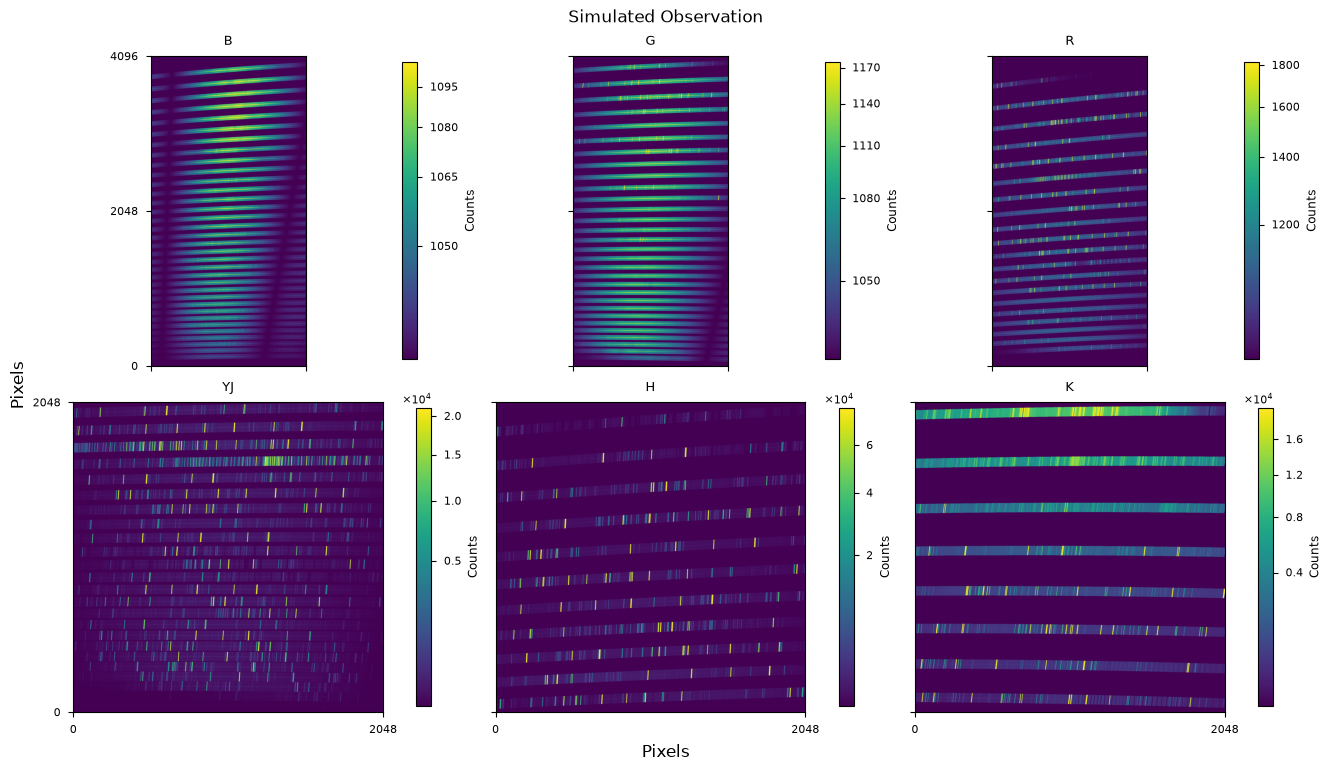

In [25]:
source_readout_products = show_and_save_hdul(readouts["source_full_background"], label="source_full_background", titles=readout_titles, output_dir=output_dir, save=True, save_figures=False, figure_title="Simulated Observation", hdul_view=READOUT_VIEW)
for figure_name, figure in source_readout_products["figures"].items():
    if figure is None:
        continue
    display_and_save_figure( figure, "source_full_background", filename_append=f"_{figure_name}")


In [26]:
readouts["full_background"] = observe_readout(None, None)
readouts["source_no_sky_lines"] = observe_readout(source_to_observe, ["sky_lines"])
readouts["background_no_sky_lines"] = observe_readout(None, ["sky_lines"])

source_minus_background = readout_delta_summary_table(readouts["source_full_background"], readouts["full_background"], titles=readout_titles)


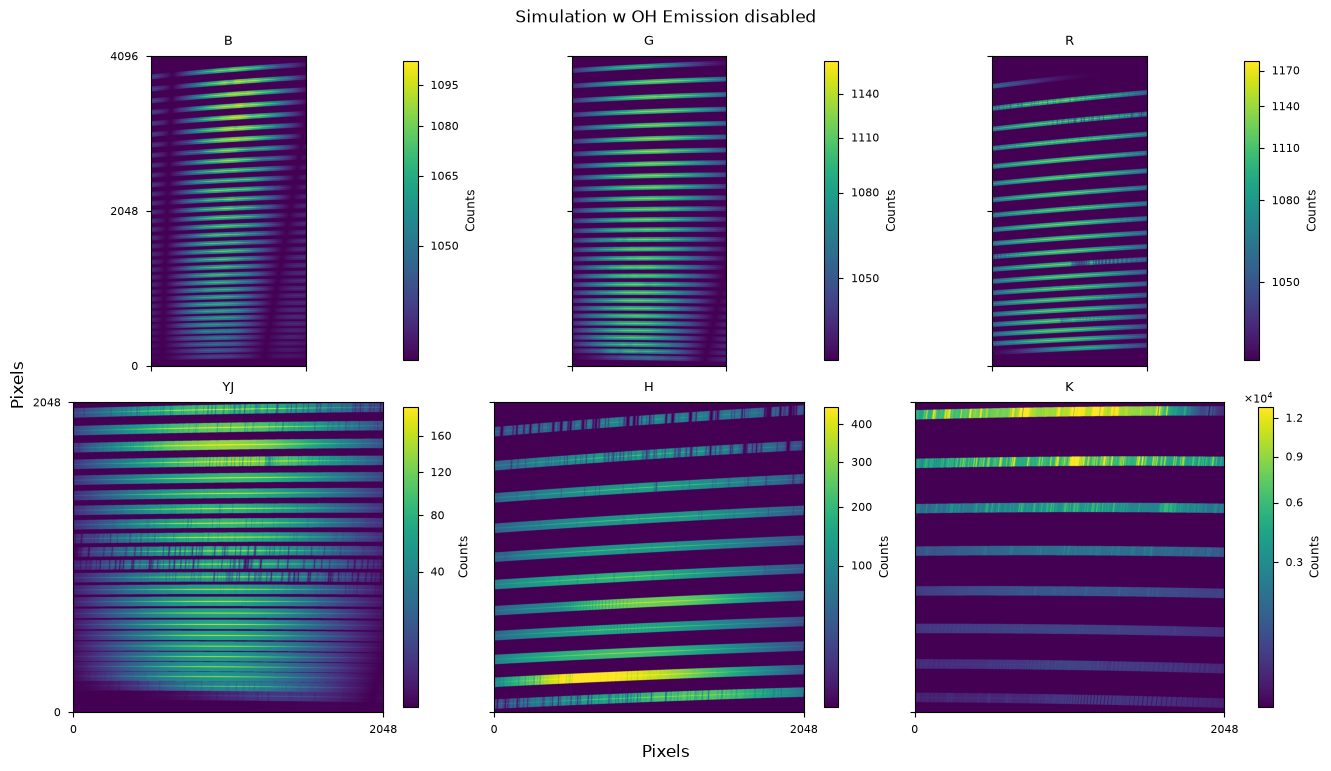

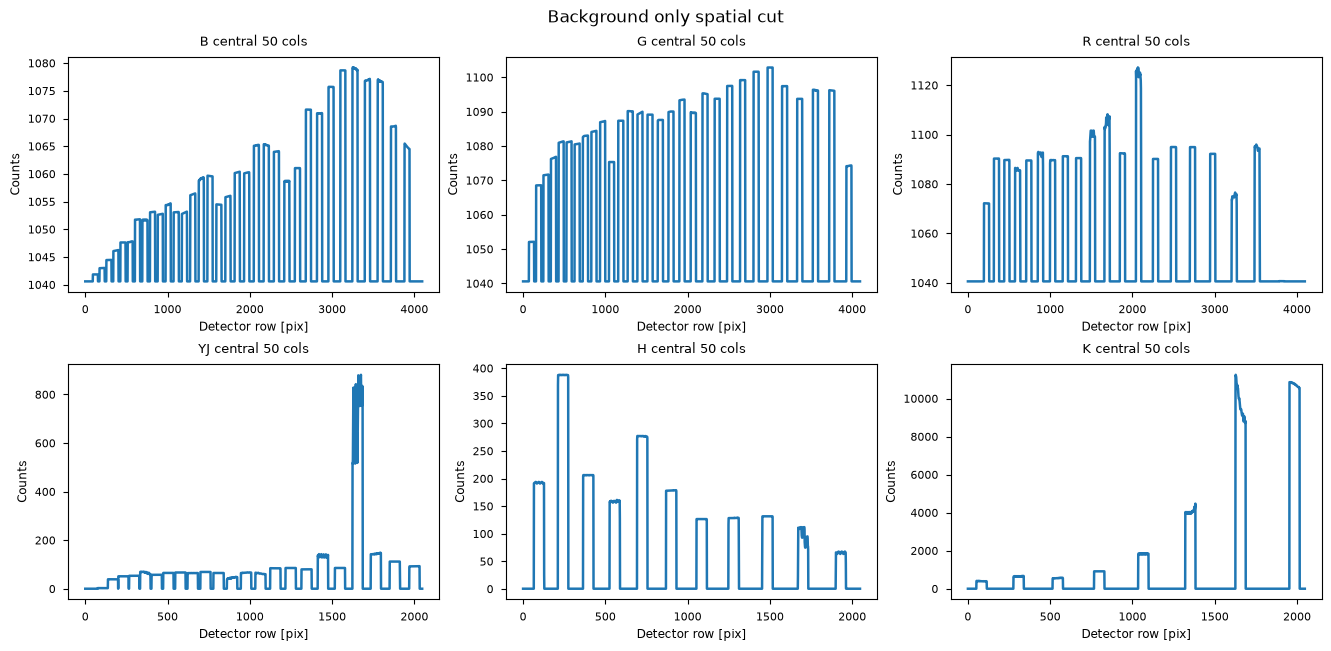

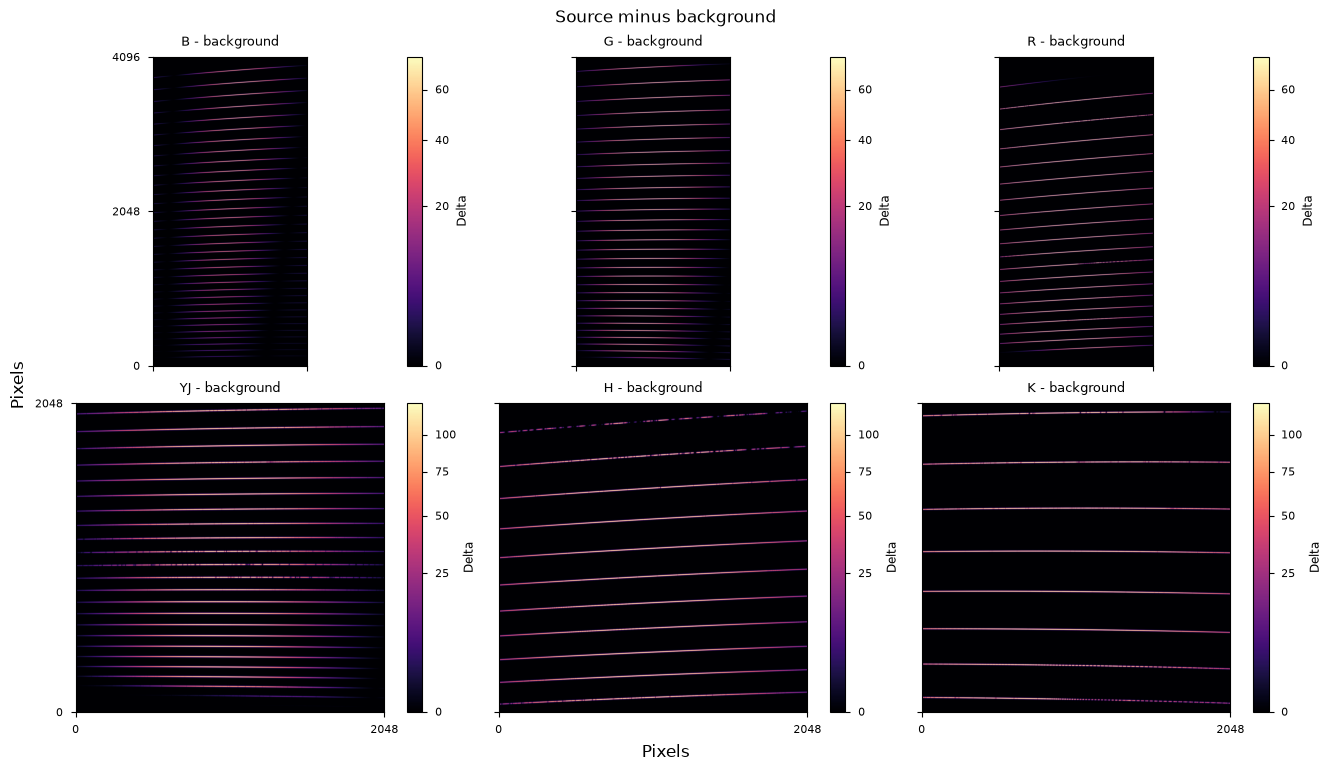

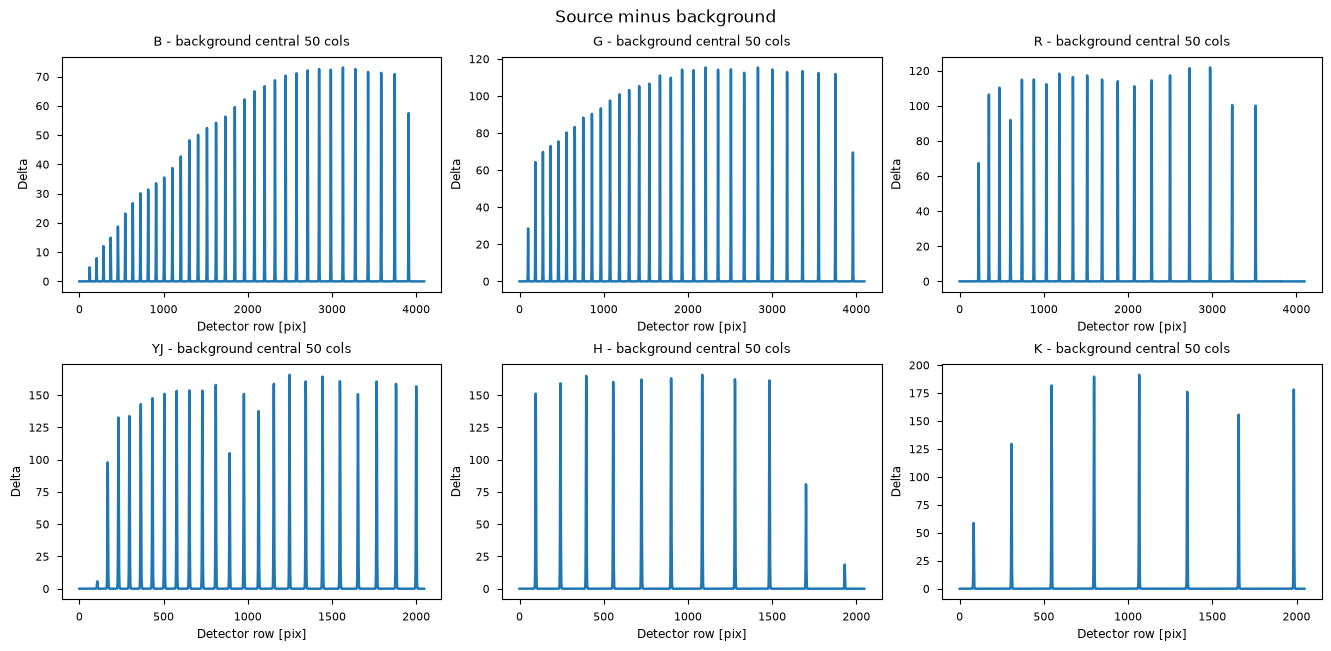

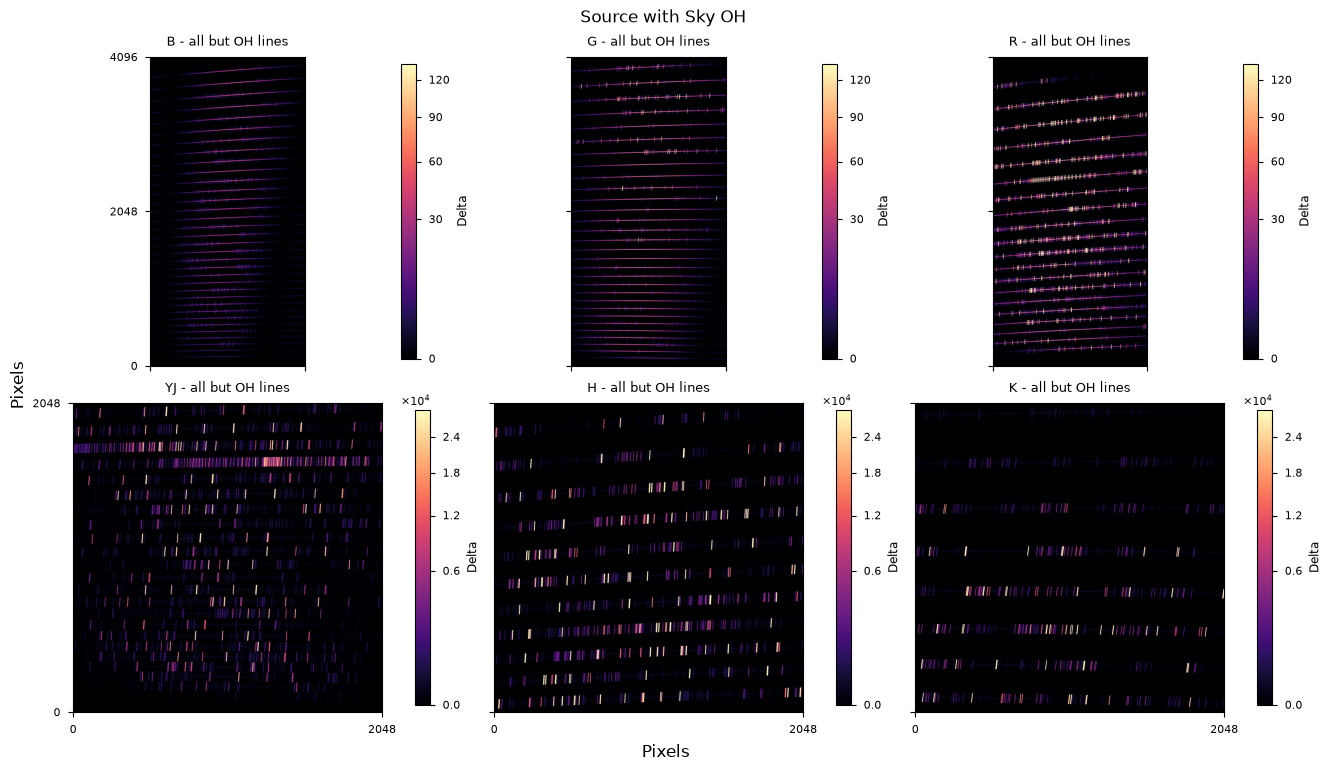

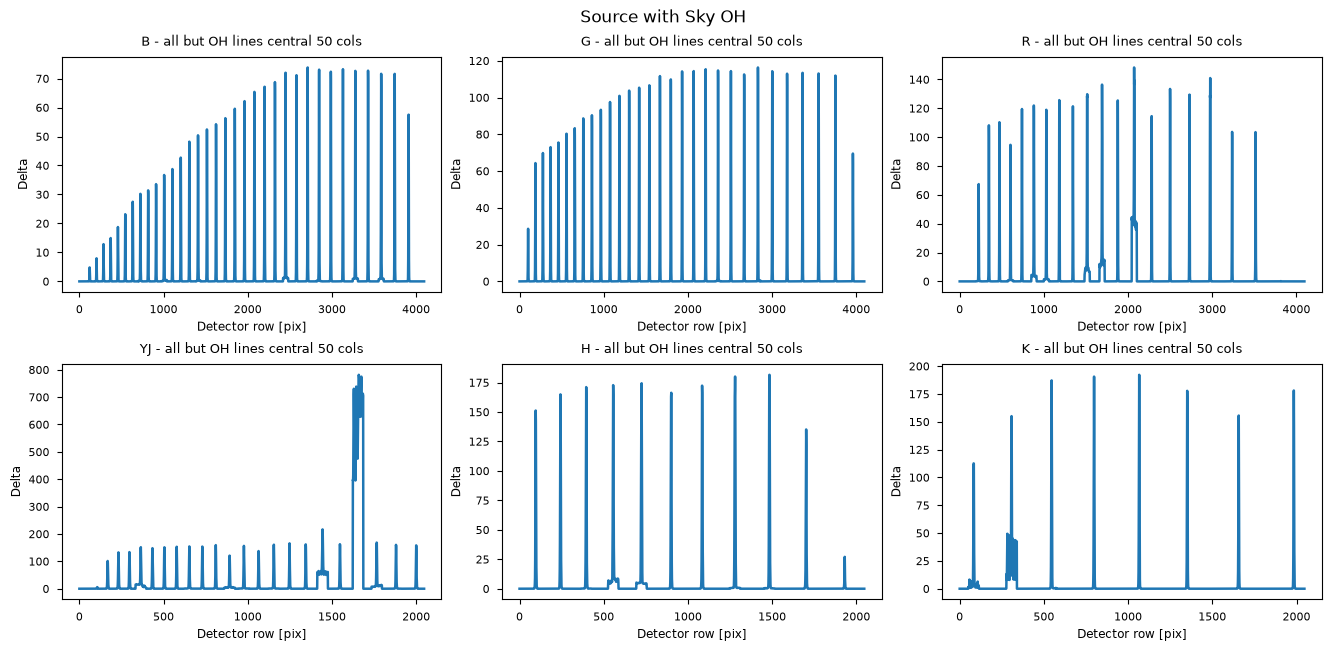

Source - Background


readout_id,channel,shape,sum_delta_e,positive_delta_e,negative_delta_e,max_delta_e,min_delta_e,max_abs_delta_e,nonzero_pixels
0,B,4096x2048,7492276.009523,7492276.009523,0.000000,87.491688,0.000000,87.491688,2437345
1,G,4096x2048,16110278.549432,16110278.549432,0.000000,120.705873,0.000000,120.705873,2063864
2,R,4096x2048,16028278.304370,16028278.304370,0.000000,162.737579,0.000000,162.737579,1253302
3,YJ,2048x2048,15599620.410256,15599620.410256,0.000000,168.370777,0.000000,168.370777,1334890
4,H,2048x2048,10298667.920495,10298667.920495,0.000000,184.735935,0.000000,184.735935,597378
5,K,2048x2048,8641159.788869,8641159.788869,0.000000,196.308090,0.000000,196.308090,421202


In [27]:
source_no_sky_products = show_and_save_hdul(readouts["source_no_sky_lines"], label="source_no_sky_lines", titles=readout_titles, show_hdul=True, show_cross_dispersion=False, save=False, figure_title="Simulation w OH Emission disabled", hdul_view=READOUT_VIEW)
for figure_name, figure in source_no_sky_products["figures"].items():
    if figure is not None:
        display_and_save_figure(figure, "source_no_sky_lines", filename_append=f"_{figure_name}")

background_cut_products = show_and_save_hdul(readouts["full_background"], label="full_background", titles=readout_titles, show_hdul=False, show_cross_dispersion=True, save=False, figure_title="Background only spatial cut", hdul_view=BACKGROUND_VIEW, cross_dispersion_ylabel="Counts")
for figure_name, figure in background_cut_products["figures"].items():
    if figure is not None:
        display_and_save_figure(figure, "full_background_spatial_cut", filename_append=f"_{figure_name}")

scenario_deltas = OrderedDict([
    ("Source minus background", (readouts["source_full_background"], readouts["full_background"], " - background")),
    ("Source with Sky OH ", (readouts["source_full_background"], readouts["background_no_sky_lines"], " - all but OH lines")),
])

for label, (signal, reference, suffix) in scenario_deltas.items():
    scenario_output_stem = "_".join(label.lower().split())
    scenario_products = show_and_save_hdul(signal, reference_hdul=reference, label=scenario_output_stem, titles=readout_titles, show_hdul=False, show_delta=True, show_cross_dispersion=True, save=False, figure_title=label, delta_view=DELTA_VIEW, delta_title_suffix=suffix, cross_dispersion_ylabel="Delta")
    for figure_name, figure in scenario_products["figures"].items():
        if figure is not None:
            display_and_save_figure(figure, scenario_output_stem, filename_append=f"_{figure_name}")

print('Source - Background')
display_frame(source_minus_background)


## Per-Pixel And Resolution-Element S/N Diagnostics

The S/N images use `source_no_sky_lines - background_no_sky_lines` for the source signal. These readouts are generated with stochastic shot/read-noise draws disabled; the variance is then computed analytically from source counts, the simulated background exposure, dark current, diffuse detector/background counts, and read noise. Subtracting a background exposure removes its mean level, not its variance, so the matched-background convention adds the background and detector variance from both exposures.


In [28]:
def readout_image(channel_hdul):
    if isinstance(channel_hdul, np.ndarray):
        return np.asarray(channel_hdul, dtype=float)
    if hasattr(channel_hdul, "data") and channel_hdul.data is not None:
        return np.asarray(channel_hdul.data, dtype=float)
    image_hdu = channel_hdul[1]
    return np.asarray(image_hdu.data, dtype=float)


def detector_terms_from_row(row):
    bias = float(row["bias_e_pix"])
    dark = float(row["dark_current_e_pix"])
    read_rms = float(row["read_noise_e_rms"])
    detector_variance = dark + read_rms**2
    return {
        "bias_e_pix": bias,
        "dark_current_e_pix": dark,
        "read_noise_e_rms": read_rms,
        "detector_variance_e2_pix": detector_variance,
        "mean_detector_signal_e_pix": dark,
    }


def detector_term_table(budget_table, *, rtol=1e-6):
    rows = []
    for row in budget_table:
        terms = detector_terms_from_row(row)
        total_rms = float(row["total_noise_e_rms"]) if "total_noise_e_rms" in budget_table.colnames else np.nan
        total_variance = total_rms**2 if np.isfinite(total_rms) else np.nan
        component_variance = terms["detector_variance_e2_pix"]
        if np.isfinite(total_variance) and not np.isclose(component_variance, total_variance, rtol=rtol, atol=rtol):
            print(f"Warning: detector variance components for {row['channel']} give " f"{component_variance:.6g} e^2/pix, but total_noise_e_rms^2 is " f"{total_variance:.6g} e^2/pix. Using explicit components.")
        rows.append({
            "channel": str(row["channel"]),
            **terms,
            "total_noise_e_rms": total_rms,
            "total_noise_variance_e2_pix": total_variance,
        })
    return Table(rows=rows)


def snr_images_from_readouts(source_hdul, background_hdul, detector_table, titles):
    terms_by_channel = {str(row["channel"]): detector_terms_from_row(row) for row in detector_table}
    signal_images = []
    background_images = []
    snr_images = []
    for title, source_hdu, background_hdu in zip(titles, source_hdul, background_hdul, strict=True):
        terms = terms_by_channel[str(title)]
        source_image = readout_image(source_hdu)
        background_image = readout_image(background_hdu)
        signal = source_image - background_image
        background = background_image - terms["bias_e_pix"] - terms["mean_detector_signal_e_pix"]
        one_exposure_fixed_variance = background + terms["detector_variance_e2_pix"]
        variance = signal + 2.0 * one_exposure_fixed_variance
        snr = signal / np.sqrt(variance)
        signal_images.append(signal)
        background_images.append(background)
        snr_images.append(snr)
    return signal_images, background_images, snr_images

def resolution_footprint_from_summary(summary_table):
    rows = []
    display_rows = []
    for row in summary_table:
        channel = str(row["channel"])
        spectral_fwhm = float(row["spectral_fwhm_pix"])
        spatial_min = float(row["spatial_fwhm_min_pix"])
        spatial_median = float(row["spatial_fwhm_median_pix"])
        spatial_max = float(row["spatial_fwhm_max_pix"])
        resel_min = float(row["resel_footprint_min_pix"])
        resel_median = float(row["resel_footprint_median_pix"])
        resel_max = float(row["resel_footprint_max_pix"])
        rows.append({
            "channel": channel,
            "current_slit_arcsec": float(row["active_slit_width_arcsec"]),
            "trace_R_median": float(row["trace_R_median"]),
            "dispersion_median_nm_pix": float(row["dispersion_median_nm_pix"]),
            "spectral_fwhm_pix": spectral_fwhm,
            "psf_fwhm_median_arcsec": float(row["seeing_fwhm_median_arcsec"]),
            "pixel_scale_arcsec_pix": float(row["pixel_scale_arcsec_pix"]),
            "spatial_fwhm_pix": spatial_median,
            "spatial_fwhm_min_pix": spatial_min,
            "spatial_fwhm_max_pix": spatial_max,
            "resel_pixels_fwhm": resel_median,
            "resel_pixels_min_fwhm": resel_min,
            "resel_pixels_max_fwhm": resel_max,
        })
        display_rows.append({
            "channel": channel,
            "slit [as]": float(row["active_slit_width_arcsec"]),
            "R": float(row["trace_R_median"]),
            "disp [nm/pix]": float(row["dispersion_median_nm_pix"]),
            "spec pix": spectral_fwhm,
            "seeing [as]": float(row["seeing_fwhm_median_arcsec"]),
            "spat pix": compact_range(spatial_min, spatial_max, 1),
            "resel pix": compact_range(resel_min, resel_max, 1),
            "sqrt pix": float(np.sqrt(resel_median)),
        })
    return Table(rows=rows), display_rows

def gaussian_spatial_effective_pixels(spatial_fwhm_pix):
    sigma = float(spatial_fwhm_pix) / 2.354820045
    box_width = float(spatial_fwhm_pix)
    if not np.isfinite(sigma) or sigma <= 0 or not np.isfinite(box_width) or box_width <= 0:
        return np.nan
    gaussian_area_in_box = np.sqrt(2*np.pi) * sigma * erf(box_width / (2*np.sqrt(2)*sigma))
    return gaussian_area_in_box**2 / box_width

def finite_values(values):
    values = np.asarray(values, dtype=float)
    return values[np.isfinite(values)]

def finite_median(values):
    values = finite_values(values)
    return float(np.nanmedian(values)) if values.size else np.nan

def finite_percentile(values, percentile):
    values = finite_values(values)
    return float(np.nanpercentile(values, percentile)) if values.size else np.nan

def finite_min(values):
    values = finite_values(values)
    return float(np.nanmin(values)) if values.size else np.nan

def finite_max(values):
    values = finite_values(values)
    return float(np.nanmax(values)) if values.size else np.nan

def finite_range_text(values, digits=1):
    values = finite_values(values)
    if not values.size:
        return "--"
    return compact_range(float(np.nanmin(values)), float(np.nanmax(values)), digits)

def trace_peak_resel_snr_by_order(train, trace_samples, snr_images, titles, local_radius=1):
    channel_values = np.asarray(trace_samples["channel"], dtype=str)
    trace_values = np.asarray(trace_samples["trace_id"], dtype=str)
    rows = []
    for channel in titles:
        channel_mask = channel_values == channel
        for trace_id in sorted(set(trace_values[channel_mask]), key=lambda x: int(x.partition('_')[2])):
            samples = trace_samples[channel_mask & (trace_values == trace_id)]
            coordinates = train.trace_detector_coordinates(wavelengths={trace_id: np.asarray(samples["wave_nm"], dtype=float) * u.nm})
            image = snr_images[int(coordinates["readout_index"][0])]
            center_values = []
            local_peak_values = []
            for coordinate in coordinates:
                x = int(np.rint(coordinate["detector_x"].to_value(u.pixel)))
                y = int(np.rint(coordinate["detector_y"].to_value(u.pixel)))
                if y < 0 or y >= image.shape[0] or x < 0 or x >= image.shape[1]:
                    continue
                center_values.append(float(image[y, x]))
                y0 = max(0, y - local_radius)
                y1 = min(image.shape[0], y + local_radius + 1)
                x0 = max(0, x - local_radius)
                x1 = min(image.shape[1], x + local_radius + 1)
                local_peak_values.append(float(np.nanmax(image[y0:y1, x0:x1])))
            spectral_pix = finite_median(samples["spectral_fwhm_pix"])
            spatial_pix = finite_median(samples["spatial_fwhm_pix"])
            spatial_eff = gaussian_spatial_effective_pixels(spatial_pix)
            eff_pixels = spectral_pix * spatial_eff
            peak_median = finite_median(local_peak_values)
            rows.append({
                "channel": channel,
                "trace_id": trace_id,
                "samples": len(local_peak_values),
                "wave_min_nm": finite_percentile(samples["wave_nm"], 0),
                "wave_max_nm": finite_percentile(samples["wave_nm"], 100),
                "wave_mid_nm": finite_median(samples["wave_nm"]),
                "center_pixel_snr_median": finite_median(center_values),
                "peak_pixel_snr_median": peak_median,
                "peak_pixel_snr_p90": finite_percentile(local_peak_values, 90),
                "spectral_width_pix": spectral_pix,
                "spatial_fwhm_pix": spatial_pix,
                "spatial_eff_pix": spatial_eff,
                "eff_pixels": eff_pixels,
                "resel_snr_median": peak_median * np.sqrt(eff_pixels),
            })
    return Table(rows=rows)

def trace_peak_resel_snr_summary(order_table, titles=None):
    rows = []
    display_rows = []
    if len(order_table) == 0:
        return Table(rows=rows), display_rows
    channels = list(titles) if titles is not None else sorted(set(np.asarray(order_table["channel"], dtype=str)))
    order_channels = np.asarray(order_table["channel"], dtype=str)
    for channel in channels:
        orders = order_table[order_channels == channel]
        if len(orders) == 0:
            continue
        wave_min = finite_min(orders["wave_min_nm"])
        wave_max = finite_max(orders["wave_max_nm"])
        eff_values = finite_values(orders["eff_pixels"])
        row = {
            "channel": channel,
            "orders": len(orders),
            "wave_min_nm": wave_min,
            "wave_max_nm": wave_max,
            "pixel_snr_min": finite_min(orders["peak_pixel_snr_median"]),
            "pixel_snr_max": finite_max(orders["peak_pixel_snr_median"]),
            "resel_snr_min": finite_min(orders["resel_snr_median"]),
            "resel_snr_max": finite_max(orders["resel_snr_median"]),
            "p90_pixel_snr_min": finite_min(orders["peak_pixel_snr_p90"]),
            "p90_pixel_snr_max": finite_max(orders["peak_pixel_snr_p90"]),
            "spectral_width_min_pix": finite_min(orders["spectral_width_pix"]),
            "spectral_width_max_pix": finite_max(orders["spectral_width_pix"]),
            "spatial_fwhm_min_pix": finite_min(orders["spatial_fwhm_pix"]),
            "spatial_fwhm_max_pix": finite_max(orders["spatial_fwhm_pix"]),
            "eff_pixels_median": float(np.nanmedian(eff_values)) if eff_values.size else np.nan,
            "eff_pixels_min": float(np.nanmin(eff_values)) if eff_values.size else np.nan,
            "eff_pixels_max": float(np.nanmax(eff_values)) if eff_values.size else np.nan,
        }
        rows.append(row)
        display_rows.append({
            "channel": channel,
            "orders": len(orders),
            "wave [nm]": compact_range(wave_min, wave_max, 0),
            "pix S/N": compact_range(row["pixel_snr_min"], row["pixel_snr_max"], 1),
            "S/N": compact_range(row["resel_snr_min"], row["resel_snr_max"], 1),
            "p90 pix S/N": compact_range(row["p90_pixel_snr_min"], row["p90_pixel_snr_max"], 1),
            "spec pix": compact_range(row["spectral_width_min_pix"], row["spectral_width_max_pix"], 1),
            "spat pix": compact_range(row["spatial_fwhm_min_pix"], row["spatial_fwhm_max_pix"], 1),
            "eff pix": compact_range(row["eff_pixels_min"], row["eff_pixels_max"], 1),
        })
    return Table(rows=rows), display_rows

def image_norm_for_view(data, view):
    from matplotlib.colors import LogNorm, Normalize, PowerNorm, SymLogNorm
    finite = finite_values(data)
    if not finite.size:
        return Normalize(vmin=0, vmax=1)
    clip = view.get("clip", 0.995)
    zero_floor = bool(view.get("zero_floor", False))
    vmin = view.get("vmin")
    vmax = view.get("vmax")
    if vmin is None:
        vmin = 0.0 if zero_floor else float(np.nanmin(finite))
    if vmax is None:
        if clip is None:
            vmax = float(np.nanmax(finite))
        elif float(clip) <= 1:
            vmax = float(np.nanquantile(finite, float(clip)))
        else:
            vmax = float(clip)
    if not np.isfinite(vmax) or vmax <= vmin:
        vmax = vmin + 1.0
    stretch = view.get("stretch", "linear")
    if stretch == "sqrt":
        return PowerNorm(gamma=0.5, vmin=vmin, vmax=vmax, clip=True)
    if stretch == "log":
        positive = finite[finite > 0]
        floor = float(np.nanmin(positive)) if positive.size else 1e-6
        return LogNorm(vmin=max(vmin, floor), vmax=max(vmax, floor * 10))
    if stretch == "symlog":
        linthresh = max((vmax - vmin) * 1e-3, 1e-3)
        return SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax)
    return Normalize(vmin=vmin, vmax=vmax)

def detector_image_widget(images, titles, view, *, value_label="", title=""):
    try:
        import ipywidgets as widgets
        from IPython.display import clear_output
    except ImportError:
        print("ipywidgets is not available in this kernel.")
        return None
    arrays = [np.asarray(image, dtype=float) for image in images]
    channel = widgets.Dropdown(options=list(titles), value=list(titles)[0], description="channel")
    x_range = widgets.IntRangeSlider(description="x", continuous_update=False, layout=widgets.Layout(width="95%"))
    y_range = widgets.IntRangeSlider(description="y", continuous_update=False, layout=widgets.Layout(width="95%"))
    full_frame = widgets.Button(description="Full frame")
    out = widgets.Output()

    def set_ranges(index):
        ny, nx = arrays[index].shape
        x_range.min = 0
        x_range.max = nx
        x_range.value = (0, nx)
        y_range.min = 0
        y_range.max = ny
        y_range.value = (0, ny)

    def selected_index():
        return list(titles).index(channel.value)

    def redraw(*_):
        index = selected_index()
        data = arrays[index]
        x0, x1 = x_range.value
        y0, y1 = y_range.value
        if x1 <= x0 or y1 <= y0:
            return
        crop = data[y0:y1, x0:x1]
        with out:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(7.5, 5.8), constrained_layout=True)
            im = ax.imshow(crop, origin="lower", cmap=view.get("cmap", "viridis"), norm=image_norm_for_view(crop, view), interpolation=view.get("interpolation", "hanning"), resample=True, extent=(x0, x1, y0, y1), aspect="auto")
            ax.set_title(f"{title} {channel.value}".strip())
            ax.set_xlabel("x [pix]")
            ax.set_ylabel("y [pix]")
            cbar = fig.colorbar(im, ax=ax)
            if value_label:
                cbar.set_label(value_label)
            display(fig)
            plt.close(fig)

    def reset_full_frame(_=None):
        set_ranges(selected_index())
        redraw()

    def channel_changed(change):
        set_ranges(selected_index())
        redraw()

    channel.observe(channel_changed, names="value")
    x_range.observe(redraw, names="value")
    y_range.observe(redraw, names="value")
    full_frame.on_click(reset_full_frame)
    set_ranges(0)
    controls = widgets.VBox([widgets.HBox([channel, full_frame]), x_range, y_range])
    display(widgets.VBox([controls, out]))
    redraw()
    return dict(channel=channel, x_range=x_range, y_range=y_range, output=out)


### SNR w/o OH

In [29]:
detector_terms = detector_term_table(detector_budget)
signal_images, background_images, snr_images = snr_images_from_readouts(readouts["source_no_sky_lines"], readouts["background_no_sky_lines"], detector_budget, readout_titles)

terms_by_channel = {str(row["channel"]): detector_terms_from_row(row) for row in detector_budget}
for channel in ("B", "H"):
    channel_index = readout_titles.index(channel)
    signal = signal_images[channel_index]
    background = background_images[channel_index]
    y, x = np.unravel_index(np.argmax(signal), signal.shape)
    detector_variance = terms_by_channel[channel]["detector_variance_e2_pix"]
    variance = signal[y, x] + 2.0 * (background[y, x] + detector_variance)
    print(f"{channel} pixel ({x}, {y}): signal={signal[y, x]:.6g} e, " f"variance={variance:.6g} e2, S/N={signal[y, x] / np.sqrt(variance):.6g}")

resolution_footprint, resolution_display_rows = resolution_footprint_from_summary(trace_resolution_summary)
display_frame(resolution_display_rows,
    formats={
        "slit [as]": "{:.2f}",
        "R": "{:.0f}",
        "disp [nm/pix]": "{:.4f}",
        "seeing [as]": "{:.2f}",
        "sqrt pix": "{:.2f}",
        "spec pix": "{:.2f}",
    }
)

trace_peak_snr_by_order = trace_peak_resel_snr_by_order(zs, trace_resolution, snr_images, readout_titles)
trace_peak_snr_summary, trace_peak_snr_display = trace_peak_resel_snr_summary(trace_peak_snr_by_order, readout_titles)
print("Trace-peak S/N per resolution element")
display_frame(trace_peak_snr_display)


B pixel (1177, 3757): signal=87.4917 e, variance=167.511 e2, S/N=6.75997
H pixel (979, 1277): signal=184.736 e, variance=440.537 e2, S/N=8.80157


channel,slit [as],R,disp [nm/pix],spec pix,seeing [as],spat pix,resel pix,sqrt pix
B,0.70,17981,0.0045,4.46,0.73,4.5-4.8,20.1-21.5,4.56
G,0.70,17953,0.0066,4.46,0.68,4.2-4.5,18.5-20.2,4.40
R,0.70,17912,0.0099,4.46,0.63,3.8-4.2,17.0-18.6,4.22
YJ,0.70,17893,0.0141,4.46,0.58,3.6-3.9,16.0-17.2,4.08
H,0.70,17962,0.0206,4.46,0.54,3.4-3.5,15.0-15.7,3.92
K,0.70,17927,0.0275,4.46,0.51,3.2-3.3,14.2-14.9,3.81


Trace-peak S/N per resolution element


channel,orders,wave [nm],pix S/N,S/N,p90 pix S/N,spec pix,spat pix,eff pix
B,34,307-431,1.6-6.2,5.9-22.8,1.7-7.0,4.5,4.5-4.8,13.2-14.1
G,30,426-656,3.5-6.9,12.6-24.7,4.0-7.8,4.5,4.2-4.5,12.2-13.2
R,20,645-994,0.3-8.4,0.9-28.2,3.1-9.4,4.5,3.8-4.2,11.2-12.2
YJ,24,945-1343,0.0-8.3,0.0-27.4,0.0-9.3,4.5,3.6-3.9,10.5-11.3
H,11,1474-1872,2.2-7.5,7.0-23.8,5.4-8.6,4.5,3.4-3.5,9.9-10.3
K,8,1973-2474,1.1-4.8,3.4-14.9,1.3-7.9,4.5,3.2-3.3,9.3-9.7


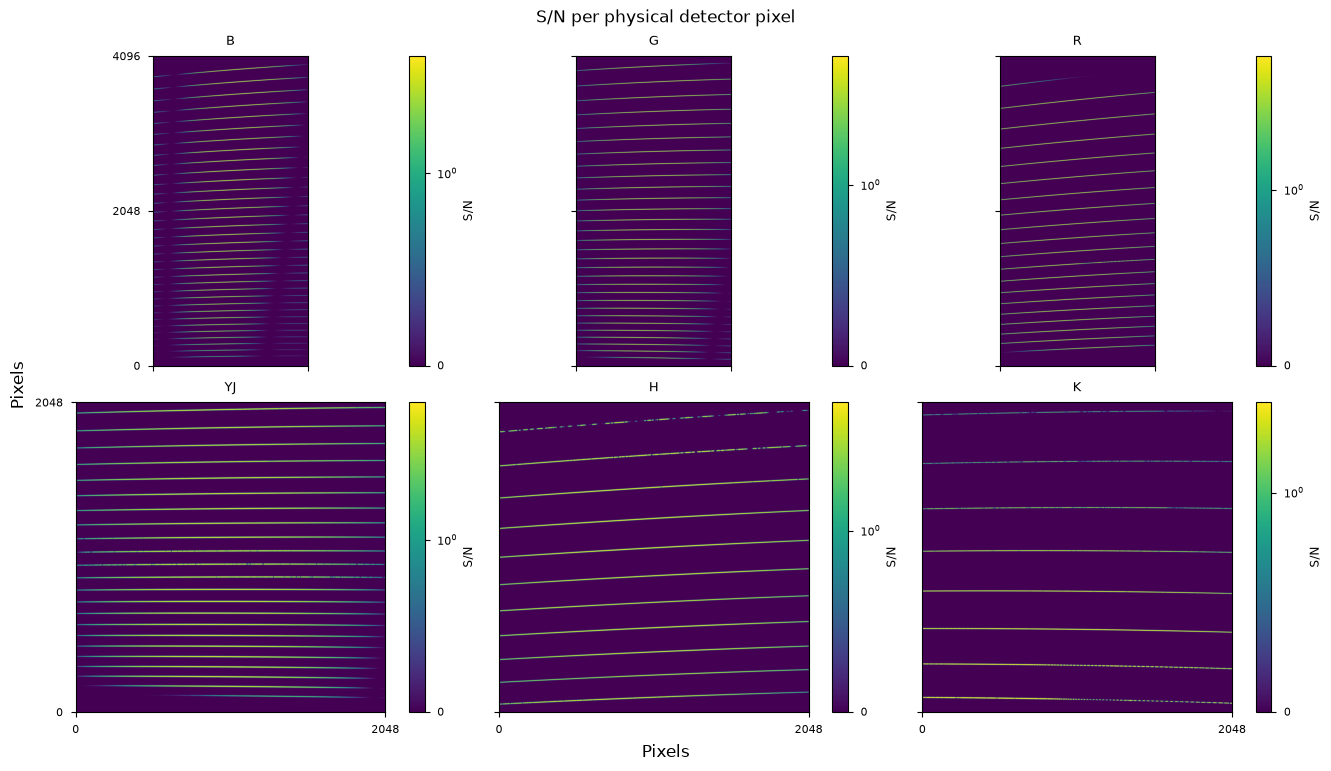

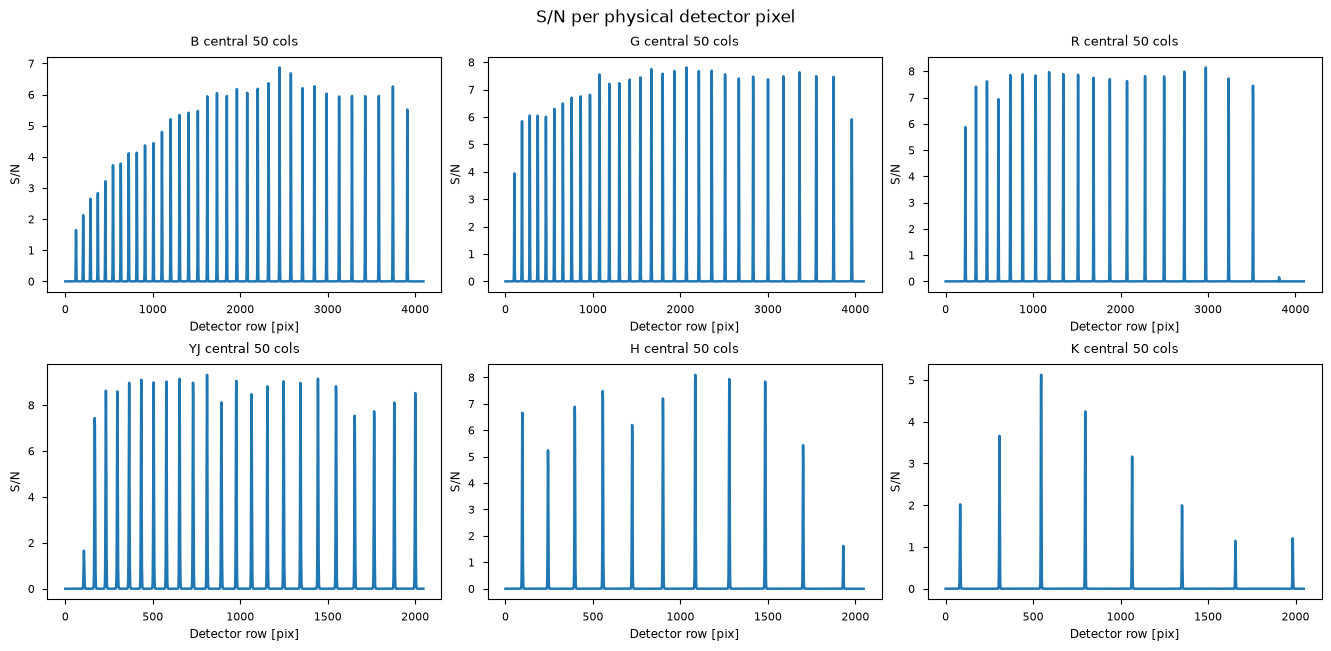

In [30]:
snr_products = show_and_save_hdul(snr_images, label="source_minus_background_snr_pixel", titles=readout_titles, output_dir=output_dir, show_hdul=True, show_cross_dispersion=True, save=True, save_figures=False, figure_title="S/N per physical detector pixel", hdul_view=SNR_VIEW, cross_dispersion_ylabel="S/N")
for figure_name, figure in snr_products["figures"].items():
    if figure is None:
        continue
    display_and_save_figure(figure, "source_background_noise_floor_pixel", filename_append=f"_{figure_name}")


### SNR w/OH

In [31]:
CHANNEL_IMAGE_CLOSEUP_SOURCE_ABMAG = 23.0
CHANNEL_IMAGE_CLOSEUP_SOURCE_KEY = "ab23_source_full_background"
CHANNEL_IMAGE_CLOSEUP_BACKGROUND_KEY = "full_background"

ab23_point_table = flat_ab_point_table.copy()
ab23_point_table["label"][0] = "flat_ab23_point_center"
ab23_point_source = Source(table=ab23_point_table, spectra=[ab_spectrum(mag=CHANNEL_IMAGE_CLOSEUP_SOURCE_ABMAG)])

random_state = np.random.get_state()
np.random.seed(29081988)
try:
    readouts[CHANNEL_IMAGE_CLOSEUP_SOURCE_KEY] = observe_readout(ab23_point_source, None, disabled_effects=None)
finally:
    np.random.set_state(random_state)


source,channel,trace,requested wavelength [nm],actual wavelength [nm],x bounds,y bounds
flat AB=23.0 in all bands,B,b_101,360.000000,359.992115,692:992,1628:1828


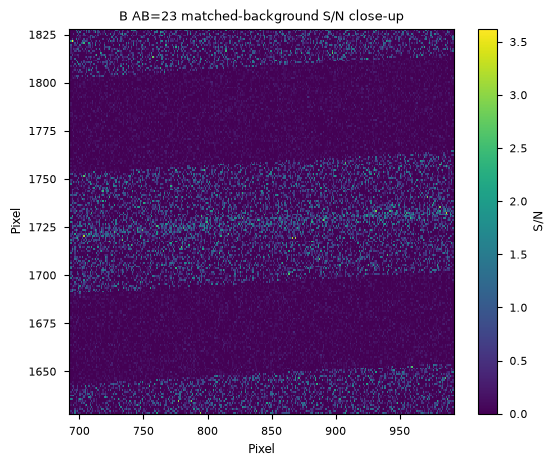

channel,slit [as],R,disp [nm/pix],spec pix,seeing [as],spat pix,resel pix,sqrt pix
B,0.70,17981,0.0045,4.46,0.73,4.5-4.8,20.1-21.5,4.56
G,0.70,17953,0.0066,4.46,0.68,4.2-4.5,18.5-20.2,4.40
R,0.70,17912,0.0099,4.46,0.63,3.8-4.2,17.0-18.6,4.22
YJ,0.70,17893,0.0141,4.46,0.58,3.6-3.9,16.0-17.2,4.08
H,0.70,17962,0.0206,4.46,0.54,3.4-3.5,15.0-15.7,3.92
K,0.70,17927,0.0275,4.46,0.51,3.2-3.3,14.2-14.9,3.81


In [32]:
from matplotlib.colors import LogNorm, SymLogNorm

CHANNEL_IMAGE_CLOSEUP_TARGET_WAVELENGTH_NM = 360.0
CHANNEL_IMAGE_CLOSEUP_WIDTH_PIX = 300
CHANNEL_IMAGE_CLOSEUP_HEIGHT_PIX = 200

closeup_candidates = trace_resolution[np.argsort(np.abs(np.asarray(trace_resolution["wave_nm"], dtype=float) - CHANNEL_IMAGE_CLOSEUP_TARGET_WAVELENGTH_NM ))]
closeup_selection = None
for candidate in closeup_candidates:
    mapped = zs.trace_detector_coordinates(wavelengths={str(candidate["trace_id"]): np.array([float(candidate["wave_nm"])]) * u.nm})[0]
    readout_index = int(mapped["readout_index"])
    source_image = readout_image(readouts[CHANNEL_IMAGE_CLOSEUP_SOURCE_KEY][readout_index])
    center_x = mapped["detector_x"].to_value(u.pixel)
    center_y = mapped["detector_y"].to_value(u.pixel)
    x0 = int(np.floor(center_x - 0.5 * (CHANNEL_IMAGE_CLOSEUP_WIDTH_PIX - 1) + 0.5 ))
    y0 = int(np.floor(center_y - 0.5 * (CHANNEL_IMAGE_CLOSEUP_HEIGHT_PIX - 1) + 0.5))
    x1 = x0 + CHANNEL_IMAGE_CLOSEUP_WIDTH_PIX
    y1 = y0 + CHANNEL_IMAGE_CLOSEUP_HEIGHT_PIX
    if 0 <= x0 and x1 <= source_image.shape[1] and 0 <= y0 and y1 <= source_image.shape[0]:
        closeup_selection = {
            "channel": str(candidate["channel"]),
            "trace_id": str(candidate["trace_id"]),
            "wave_nm": float(candidate["wave_nm"]),
            "readout_index": readout_index,
            "x0": x0, "x1": x1, "y0": y0, "y1": y1,
        }
        break

closeup_channel = closeup_selection["channel"]
closeup_index = closeup_selection["readout_index"]
x0, x1 = closeup_selection["x0"], closeup_selection["x1"]
y0, y1 = closeup_selection["y0"], closeup_selection["y1"]

source_image = readout_image(readouts[CHANNEL_IMAGE_CLOSEUP_SOURCE_KEY][closeup_index])
background_image = readout_image(readouts[CHANNEL_IMAGE_CLOSEUP_BACKGROUND_KEY][closeup_index])

signal_image = source_image - background_image


reference_signal_image = readout_image(readouts["source_full_background"][closeup_index]) - background_image
expected_signal_image = reference_signal_image * 10**(-0.4 * (CHANNEL_IMAGE_CLOSEUP_SOURCE_ABMAG - source_brightness_m_am))

detector_row = detector_budget[np.asarray(detector_budget["channel"], dtype=str) == closeup_channel][0]
closeup_detector_terms = detector_terms_from_row(detector_row)
background_expectation = background_image - closeup_detector_terms["bias_e_pix"] - closeup_detector_terms["mean_detector_signal_e_pix"]

# The numerator is one stochastic source+background realization minus deterministic background;
# the denominator is the analytic matched-background uncertainty used elsewhere.
variance_image = expected_signal_image + 2.0 * (background_expectation + closeup_detector_terms["detector_variance_e2_pix"])


signal_closeup = signal_image[y0:y1, x0:x1]
noise_closeup = np.sqrt(variance_image[y0:y1, x0:x1])
sn_closeup = signal_closeup / noise_closeup

signal_limit = np.max(signal_closeup)

display_frame([{
    "source": f"flat AB={CHANNEL_IMAGE_CLOSEUP_SOURCE_ABMAG:.1f} in all bands",
    "channel": closeup_channel,
    "trace": closeup_selection["trace_id"],
    "requested wavelength [nm]": CHANNEL_IMAGE_CLOSEUP_TARGET_WAVELENGTH_NM,
    "actual wavelength [nm]": closeup_selection["wave_nm"],
    "x bounds": f"{x0}:{x1}",
    "y bounds": f"{y0}:{y1}",
}])

fig = plt.figure(figsize=(6.2, 5.0))
signal_artist = plt.imshow(sn_closeup.clip(0),
    origin="lower", cmap="viridis", interpolation="nearest",
    extent=(x0, x1, y0, y1), aspect="auto")
plt.gca().set(title=f"{closeup_channel} AB=23 matched-background S/N close-up", xlabel=r"Pixel", ylabel=r"Pixel")
plt.colorbar(signal_artist, label="S/N")

display_and_save_figure(fig, "channel_band_noisy_closeup", filename_append=f"_{closeup_channel}_{closeup_selection['wave_nm']:.0f}nm")

resolution_footprint, resolution_display_rows = resolution_footprint_from_summary(trace_resolution_summary)
display_frame(resolution_display_rows,
    formats={
        "slit [as]": "{:.2f}",
        "R": "{:.0f}",
        "disp [nm/pix]": "{:.4f}",
        "seeing [as]": "{:.2f}",
        "sqrt pix": "{:.2f}",
        "spec pix": "{:.2f}",
    }
)

In [33]:
trace_peak_snr_by_order = trace_peak_resel_snr_by_order(zs, trace_resolution, snr_images, readout_titles)
trace_peak_snr_summary, trace_peak_snr_display = trace_peak_resel_snr_summary(trace_peak_snr_by_order, readout_titles)
print("Trace-peak approximate S/N per resolution element")
display_frame(trace_peak_snr_display)

Trace-peak approximate S/N per resolution element


channel,orders,wave [nm],pix S/N,S/N,p90 pix S/N,spec pix,spat pix,eff pix
B,34,307-431,1.6-6.2,5.9-22.8,1.7-7.0,4.5,4.5-4.8,13.2-14.1
G,30,426-656,3.5-6.9,12.6-24.7,4.0-7.8,4.5,4.2-4.5,12.2-13.2
R,20,645-994,0.3-8.4,0.9-28.2,3.1-9.4,4.5,3.8-4.2,11.2-12.2
YJ,24,945-1343,0.0-8.3,0.0-27.4,0.0-9.3,4.5,3.6-3.9,10.5-11.3
H,11,1474-1872,2.2-7.5,7.0-23.8,5.4-8.6,4.5,3.4-3.5,9.9-10.3
K,8,1973-2474,1.1-4.8,3.4-14.9,1.3-7.9,4.5,3.2-3.3,9.3-9.7


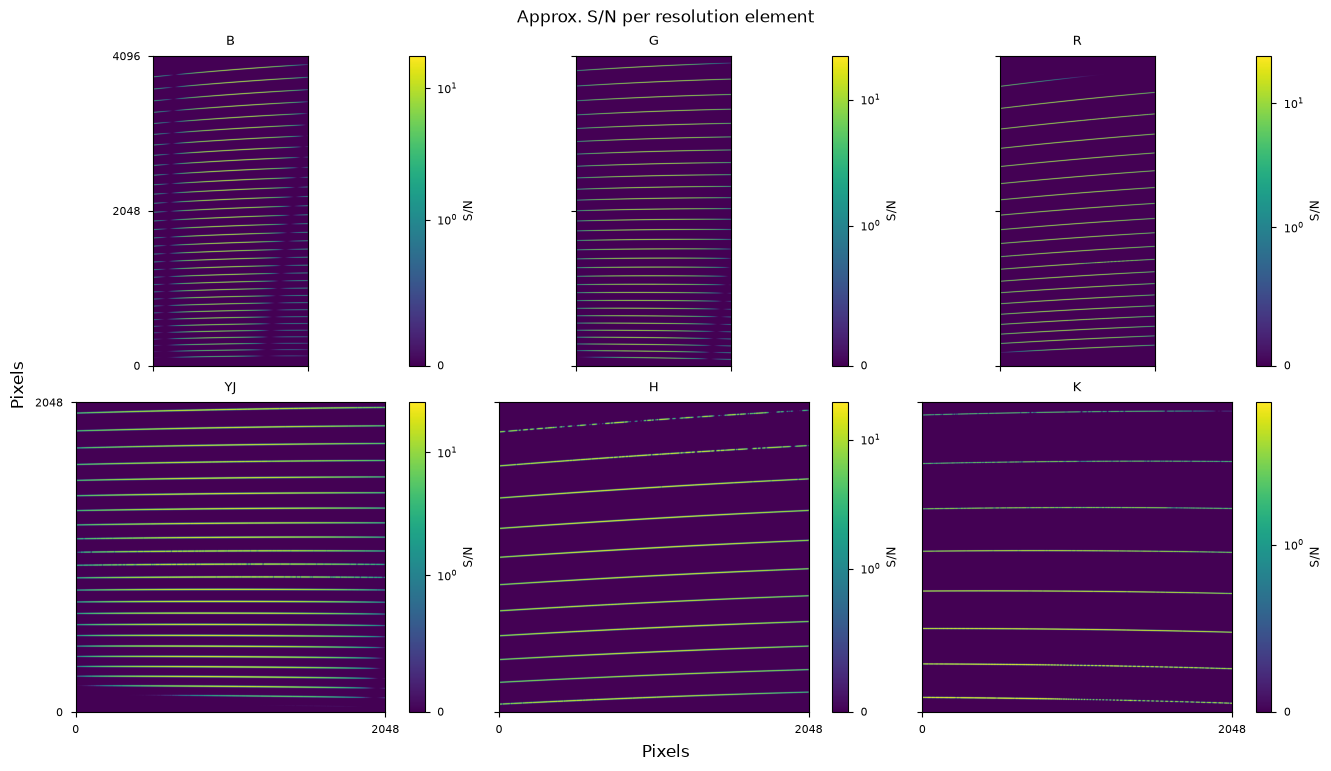

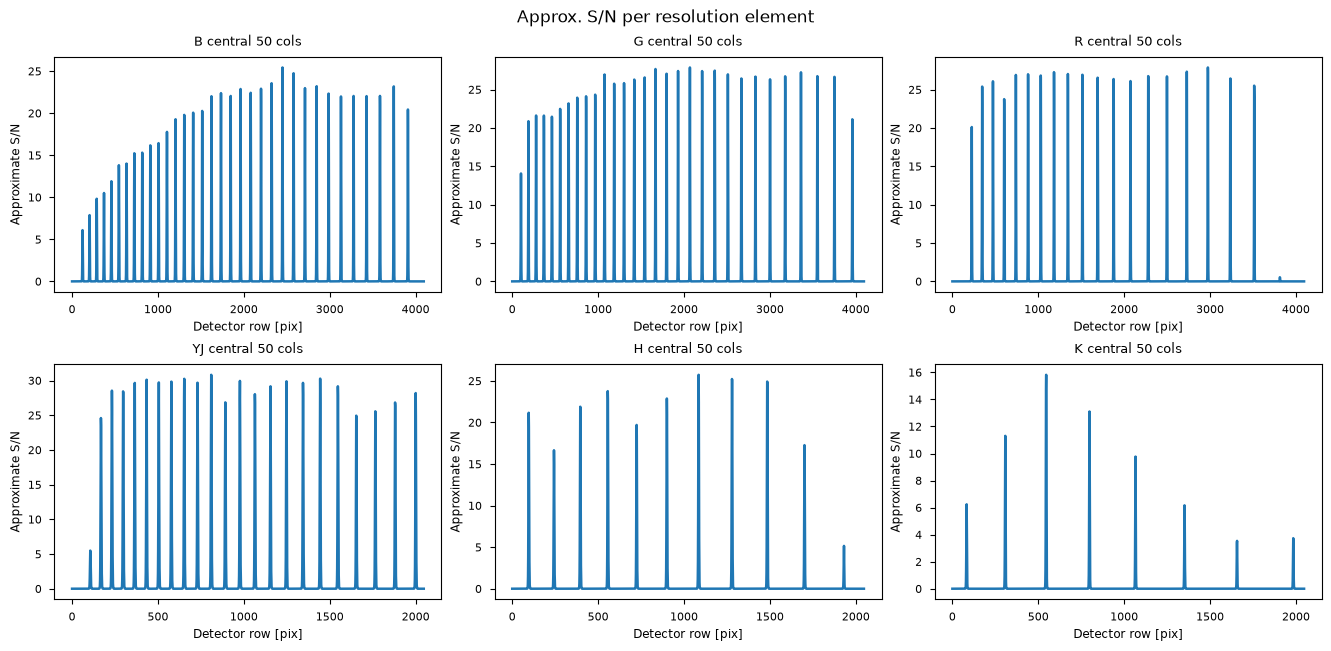

In [34]:
# Uniform-profile approximation: scale per-pixel S/N by sqrt(effective pixels).
snr_scale_by_channel = {str(row["channel"]): np.sqrt(float(row["eff_pixels_median"])) for row in trace_peak_snr_summary}
resel_snr_images = [snr * snr_scale_by_channel[title] for title, snr in zip(readout_titles, snr_images, strict=True)]

resel_snr_products = show_and_save_hdul(resel_snr_images, label="source_minus_background_snr_resel", titles=readout_titles, output_dir=output_dir, show_hdul=True, show_cross_dispersion=True, save=True, save_figures=False, figure_title="Approx. S/N per resolution element", hdul_view=SNR_VIEW, cross_dispersion_ylabel="Approximate S/N")
for figure_name, figure in resel_snr_products["figures"].items():
    if figure is None:
        continue
    display_and_save_figure(figure, "source_background_noise_floor_resel", filename_append=f"_{figure_name}")

## Detector-Aligned Trace Extraction

This section estimates the AB magnitude that gives S/N = 5 after subtracting a matched background exposure. The no-sky-line source/background pair selects one spatial extraction height per order; later comparisons reuse the resulting wavelength samples and integer rectangles.

ScopeSim maps each trace sample's wavelength center at xi=0 through the configured trace, FOV assignment, image plane, and detector. The notebook uses that continuous zero-origin detector-pixel center directly. Dispersion is detector x, spatial extraction is detector y, and no image data are used to infer or adjust the center.

The configured spectral FWHM remains continuous through multiplication by the requested resolution-element bin factor. It is then rounded once to an integer column count. Spatial FWHM also remains continuous while defining the one-to-three-FWHM search interval, but the optimization compares the actual fixed integer row counts used in the sums. Every sample in an order therefore has the same spatial pixel count.

The variance follows the observing pair. Background subtraction removes the mean sky and detector signal but not their variance:

Var(f) = f * source_counts + 2 * sky_counts + 2 * detector_variance.

Bias is a mean electronic offset and is not a variance term.


In [35]:
ZERO_POINT_TARGET_SNR = 5.0
TRACE_APERTURE_CALIBRATION_SAMPLES = 9
TRACE_APERTURE_MAX_WIDTH_FWHM = 3.0
TRACE_APERTURE_NEAR_BEST_M5_MAG = 0.01


def trace_id_sort_key(trace_id):
    prefix, order = str(trace_id).split("_", maxsplit=1)
    return prefix, int(order)


def channel_slit_label(vis_slit, nir_slit):
    vis = float(vis_slit)
    nir = float(nir_slit)
    if np.isclose(vis, nir):
        return f'{vis:.2f}" slit'
    return f'{vis:.2f}/{nir:.2f}" slit'


def trace_sample_detector_coordinates(train, trace_samples):
    """Map every native wavelength at the source position rendered on the slit grid."""
    trace_values = np.asarray(trace_samples["trace_id"], dtype=str)
    rows = []

    sub_pixel_enabled = bool(from_currsys("!SIM.sub_pixel.flag", train.cmds))
    from scopesim.optics import image_plane_utils as imp_utils

    for trace_id in sorted(set(trace_values), key=trace_id_sort_key):
        order_samples = trace_samples[trace_values == trace_id]
        channel = str(order_samples["channel"][0])
        order_samples = order_samples[np.argsort(order_samples["sample_index"])]
        wave_grid_nm = np.asarray(order_samples["wave_nm"], dtype=float)

        trace_fovs = [fov for fov in train.fov_manager.fovs if str(fov.trace_id) == trace_id]
        assert len(trace_fovs) == 1, (trace_id, len(trace_fovs))
        fov = trace_fovs[0]

        source_xpix, _ = imp_utils.val2pix(fov.header, 0.0, 0.0)
        dxi_arcsec = (fov.header["CDELT1"] * u.Unit(fov.header["CUNIT1"])).to_value(u.arcsec)

        rendered_source_xpix = source_xpix if sub_pixel_enabled else int(source_xpix)
        rendered_xi = fov.meta["xi_min"].to(u.arcsec) + rendered_source_xpix * dxi_arcsec * u.arcsec

        mapped = train.trace_detector_coordinates(xi=rendered_xi, wavelengths={trace_id: wave_grid_nm * u.nm})

        # Only one xi was requested, so do not filter for xi == 0.
        mapped_wave_nm = mapped["wavelength"].to_value(u.nm)
        mapped_order = np.argsort(mapped_wave_nm)
        mapped_wave_nm = mapped_wave_nm[mapped_order]
        center_x_pix = mapped["detector_x"][mapped_order].to_value(u.pixel)
        center_y_pix = mapped["detector_y"][mapped_order].to_value(u.pixel)
        readout_index = mapped["readout_index"][mapped_order]

        for sample in order_samples:
            wave_nm = float(sample["wave_nm"])

            wavelength_error_nm = np.abs(mapped_wave_nm - wave_nm)
            center_index = int(np.argmin(wavelength_error_nm))
            assert wavelength_error_nm[center_index] < 1e-8, (trace_id, wave_nm, mapped_wave_nm[center_index], wavelength_error_nm[center_index])

            x0, x1 = int(sample["detector_x0_pix"]), int(sample["detector_x1_pix"])
            assert x0 - 0.5 <= center_x_pix[center_index] <= x1 - 0.5
            rows.append({
                "channel": channel,
                "trace_id": trace_id,
                "sample_index": int(sample["sample_index"]),
                "readout_index": int(readout_index[center_index]),
                "wave_nm": mapped_wave_nm[center_index],
                "wave_low_nm": float(sample["wave_low_nm"]),
                "wave_high_nm": float(sample["wave_high_nm"]),
                "center_x_pix": center_x_pix[center_index],
                "center_y_pix": center_y_pix[center_index],
                "detector_x0_pix": x0,
                "detector_x1_pix": x1,
                "dispersion_nm_pix": float(sample["dispersion_nm_pix"]),
                "resolution_width_nm": float(sample["spectral_fwhm_pix"] * sample["dispersion_nm_pix"]),
                "resolving_power_R": float(sample["resolving_power_R"]),
                "spectral_fwhm_pix": float(sample["spectral_fwhm_pix"]),
                "spectral_width_pix": int(sample["spectral_width_pix"]),
                "spatial_fwhm_pix": float(sample["spatial_fwhm_pix"]),
            })
    return Table(rows=rows)


def trace_coordinate_lookup(coordinate_table):
    return {(str(row["channel"]), str(row["trace_id"]), int(row["sample_index"])): row for row in coordinate_table}


def centered_integer_pixel_bounds(center_pix, width_pix):
    """Center a fixed pixel count on a continuous detector coordinate.

    The selected pixel-center mean is nearest to the mapped center. An exact
    half-pixel tie is placed toward increasing detector index, including for
    even widths.
    """
    width_pix = int(width_pix)
    lower = int(np.floor(float(center_pix) - 0.5 * (width_pix - 1) + 0.5))
    return lower, lower + width_pix


def trace_sample_pixel_rectangle(coordinate, image_shape, spatial_width_pix):
    x0, x1 = int(coordinate["detector_x0_pix"]), int(coordinate["detector_x1_pix"])
    spectral_width_pix = x1 - x0
    spatial_width_pix = int(spatial_width_pix)
    assert spectral_width_pix > 0 and spatial_width_pix > 0
    y0, y1 = centered_integer_pixel_bounds(coordinate["center_y_pix"], spatial_width_pix)

    if x0 < 0 or x1 > image_shape[1] or y0 < 0 or y1 > image_shape[0]:
        return None

    assert x1 - x0 == spectral_width_pix
    assert y1 - y0 == spatial_width_pix
    return {
        "x0": x0,
        "x1": x1,
        "y0": y0,
        "y1": y1,
        "center_x_pix": float(coordinate["center_x_pix"]),
        "center_y_pix": float(coordinate["center_y_pix"]),
        "spectral_width_pix": spectral_width_pix,
        "spatial_width_pix": spatial_width_pix,
        "n_pix": spectral_width_pix * spatial_width_pix,
    }


def readout_signal_background_products(source_hdul, background_hdul, detector_table, titles):
    terms_by_channel = {str(row["channel"]): detector_terms_from_row(row) for row in detector_table}
    products = {}
    for title, source_hdu, background_hdu in zip(titles, source_hdul, background_hdul, strict=True):
        title = str(title)
        terms = terms_by_channel[title]
        signal = readout_image(source_hdu) - readout_image(background_hdu)
        sky = readout_image(background_hdu) - terms["bias_e_pix"] - terms["mean_detector_signal_e_pix"]
        products[title] = {
            "signal": signal,
            "sky": sky,
            "detector_variance_e2_pix": terms["detector_variance_e2_pix"],
        }
    return products


def extract_products_from_rectangle(products, rectangle):
    y0, y1 = rectangle["y0"], rectangle["y1"]
    x0, x1 = rectangle["x0"], rectangle["x1"]
    signal_pixels = products["signal"][y0:y1, x0:x1]
    sky_pixels = products["sky"][y0:y1, x0:x1]
    expected_shape = (rectangle["spatial_width_pix"], rectangle["spectral_width_pix"])
    assert signal_pixels.shape == expected_shape
    assert sky_pixels.shape == expected_shape
    assert signal_pixels.size == rectangle["n_pix"]

    signal_e = np.sum(signal_pixels)
    sky_e = np.sum(sky_pixels)
    n_pix = rectangle["n_pix"]
    source_var_e = signal_e
    sky_var_e = 2 * sky_e
    detector_var_e = 2 * n_pix * products["detector_variance_e2_pix"]
    fixed_variance_e = sky_var_e + detector_var_e
    snr_at_input = signal_e / np.sqrt(source_var_e + fixed_variance_e)
    return {
        "n_pix": n_pix,
        "variance_pixels": n_pix,
        "signal_e": signal_e,
        "source_var_e": source_var_e,
        "background_e": sky_e,
        "background_var_e": sky_var_e,
        "detector_var_e": detector_var_e,
        "fixed_variance_e": fixed_variance_e,
        "snr_at_input": snr_at_input,
    }


def flux_scale_for_target_snr(source_signal_e, source_variance_e, fixed_variance_e, target_snr=ZERO_POINT_TARGET_SNR):
    if source_signal_e <= 0 or source_variance_e < 0 or fixed_variance_e < 0:
        return np.nan
    q2 = target_snr**2
    discriminant = (q2 * source_variance_e)**2 + 4 * source_signal_e**2 * q2 * fixed_variance_e
    return (q2 * source_variance_e + np.sqrt(discriminant)) / (2 * source_signal_e**2)


def limiting_abmag_for_target_snr(input_abmag, source_signal_e, source_variance_e, fixed_variance_e, target_snr=ZERO_POINT_TARGET_SNR):
    scale = flux_scale_for_target_snr(source_signal_e, source_variance_e, fixed_variance_e, target_snr=target_snr)
    return input_abmag - 2.5 * np.log10(scale) if scale > 0 else np.nan


def select_trace_calibration_samples(order_samples, *, max_samples=TRACE_APERTURE_CALIBRATION_SAMPLES):
    order_samples = order_samples[np.argsort(order_samples["wave_nm"])]
    if len(order_samples) <= max_samples:
        return order_samples
    interior = np.arange(len(order_samples))
    edge = max(1, int(np.floor(0.06 * len(interior))))
    interior = interior[edge:-edge]
    selected = np.round(np.linspace(0, len(interior) - 1, max_samples)).astype(int)
    return order_samples[interior[selected]]


def _sample_rectangle(readout_hdul, sample, coordinate_lookup, spatial_width_pix):
    key = (str(sample["channel"]), str(sample["trace_id"]), int(sample["sample_index"]))
    coordinate = coordinate_lookup[key]
    image_shape = readout_image(readout_hdul[int(coordinate["readout_index"])]).shape
    return trace_sample_pixel_rectangle(coordinate, image_shape, spatial_width_pix)


def choose_trace_aperture_width(products, readout_hdul, calibration_samples, coordinate_lookup, input_abmag):
    spatial_fwhm_pix = float(np.median(calibration_samples["spatial_fwhm_pix"]))
    minimum_width_pix = int(np.ceil(spatial_fwhm_pix))
    maximum_width_pix = int(np.floor(TRACE_APERTURE_MAX_WIDTH_FWHM * spatial_fwhm_pix))
    assert maximum_width_pix >= minimum_width_pix
    widths_pix = np.arange(minimum_width_pix, maximum_width_pix + 1)
    m5_grid = np.full((len(calibration_samples), len(widths_pix)), np.nan)

    for sample_index, sample in enumerate(calibration_samples):
        rectangles = [_sample_rectangle(readout_hdul, sample, coordinate_lookup, width_pix) for width_pix in widths_pix]
        if any(rectangle is None for rectangle in rectangles):
            continue
        for width_index, rectangle in enumerate(rectangles):
            extraction = extract_products_from_rectangle(products, rectangle)
            m5_grid[sample_index, width_index] = limiting_abmag_for_target_snr(input_abmag, extraction["signal_e"], extraction["source_var_e"], extraction["fixed_variance_e"])

    median_m5 = np.full(len(widths_pix), np.nan)
    for width_index in range(len(widths_pix)):
        finite = np.isfinite(m5_grid[:, width_index])
        if np.any(finite):
            median_m5[width_index] = np.median(m5_grid[finite, width_index])
    if not np.any(np.isfinite(median_m5)):
        return None
    finite_width_indices = np.flatnonzero(np.isfinite(median_m5))
    best_m5 = np.max(median_m5[finite_width_indices])
    near_best_indices = finite_width_indices[median_m5[finite_width_indices] >= best_m5 - TRACE_APERTURE_NEAR_BEST_M5_MAG]
    selected_index = int(near_best_indices[-1])
    return {
        "spatial_fwhm_pix": spatial_fwhm_pix,
        "spatial_width_pix": int(widths_pix[selected_index]),
        "width_best_m5_ab": median_m5[selected_index],
        "width_grid_pix": widths_pix,
        "width_median_m5_ab": median_m5,
    }


def trace_aperture_lookup(aperture_calibration):
    if isinstance(aperture_calibration, dict):
        return aperture_calibration
    return {(str(row["channel"]), str(row["trace_id"])): {name: row[name] for name in aperture_calibration.colnames} for row in aperture_calibration}


def calibrate_trace_apertures(train, source_hdul, background_hdul, detector_table, trace_samples, titles, *, input_abmag, mapped_coordinates=None):
    products_by_channel = readout_signal_background_products(source_hdul, background_hdul, detector_table, titles)
    if mapped_coordinates is None:
        mapped_coordinates = trace_sample_detector_coordinates(train, trace_samples)
    coordinate_lookup = trace_coordinate_lookup(mapped_coordinates)
    channel_values = np.asarray(trace_samples["channel"], dtype=str)
    apertures = {}

    for channel in titles:
        channel = str(channel)
        channel_samples = trace_samples[channel_values == channel]
        trace_values = np.asarray(channel_samples["trace_id"], dtype=str)
        for trace_id in sorted(set(trace_values), key=trace_id_sort_key):
            order_samples = channel_samples[trace_values == trace_id]
            calibration_samples = select_trace_calibration_samples(order_samples)
            width_info = choose_trace_aperture_width(products_by_channel[channel], background_hdul, calibration_samples, coordinate_lookup, input_abmag)
            if width_info is None:
                continue
            apertures[(channel, trace_id)] = {
                "channel": channel,
                "trace_id": trace_id,
                "wave_low_nm": float(np.min(order_samples["wave_nm"])),
                "wave_high_nm": float(np.max(order_samples["wave_nm"])),
                "calibration_sample_indices": tuple(int(value) for value in calibration_samples["sample_index"]),
                **width_info,
            }
    return apertures


def trace_aperture_calibration_table(apertures):
    scalar_columns = ("channel", "trace_id", "wave_low_nm", "wave_high_nm", "spatial_fwhm_pix", "spatial_width_pix", "width_best_m5_ab")
    rows = [{name: aperture[name] for name in scalar_columns} for aperture in trace_aperture_lookup(apertures).values()]
    return Table(rows=sorted(rows, key=lambda row: trace_id_sort_key(row["trace_id"])))


def trace_aperture_quality_summary(apertures, titles=None):
    table = trace_aperture_calibration_table(apertures)
    channels = list(titles) if titles is not None else list(dict.fromkeys(table["channel"]))
    rows = []
    for channel in channels:
        group = table[table["channel"] == channel]
        rows.append({
            "ch": channel,
            "traces": len(group),
            "width [pix]": compact_range(np.min(group["spatial_width_pix"]), np.max(group["spatial_width_pix"]), 0),
        })
    return rows


def aggregate_native_extraction_ledger(native_table, bin_factors):
    sum_columns = ("n_pix", "variance_pixels", "signal_e", "source_var_e", "background_e", "background_var_e", "detector_var_e", "fixed_variance_e")
    rows = []
    channels = np.asarray(native_table["channel"], dtype=str)
    traces = np.asarray(native_table["trace_id"], dtype=str)

    for channel in sorted(set(channels)):
        for trace_id in sorted(set(traces[channels == channel]), key=trace_id_sort_key):
            native = native_table[(channels == channel) & (traces == trace_id)]
            native = native[np.argsort(native["sample_index"])]
            assert np.array_equal(native["sample_index"], np.arange(len(native)))
            assert np.array_equal(native["x1"][:-1], native["x0"][1:])

            for bin_factor in bin_factors:
                bin_factor = int(bin_factor)
                starts = np.arange(0, len(native), bin_factor)
                stops = np.minimum(starts + bin_factor, len(native))
                summed = {}
                for name in sum_columns:
                    cumulative = np.r_[0.0, np.cumsum(np.asarray(native[name], dtype=float))]
                    summed[name] = cumulative[stops] - cumulative[starts]
                wave_low_nm = np.asarray(native["wave_low_nm"], dtype=float)[starts]
                wave_high_nm = np.asarray(native["wave_high_nm"], dtype=float)[stops - 1]
                wave_nm = 0.5 * (wave_low_nm + wave_high_nm)
                if bin_factor == 1:
                    wave_nm = np.asarray(native["wave_nm"], dtype=float)[starts]
                native_raster_width_nm = np.asarray(native["wave_high_nm"] - native["wave_low_nm"], dtype=float)
                weights = native_raster_width_nm
                weight_cumulative = np.r_[0.0, np.cumsum(weights)]
                weight_sum = weight_cumulative[stops] - weight_cumulative[starts]
                weighted_x = np.r_[0.0, np.cumsum(weights * native["detector_x_pix"])]
                weighted_y = np.r_[0.0, np.cumsum(weights * native["detector_y_pix"])]
                detector_x_pix = (weighted_x[stops] - weighted_x[starts]) / weight_sum
                detector_y_pix = (weighted_y[stops] - weighted_y[starts]) / weight_sum
                resolution_width = np.r_[0.0, np.cumsum(native["resolution_width_nm"])]
                resolution_width = resolution_width[stops] - resolution_width[starts]
                spectral_fwhm = np.r_[0.0, np.cumsum(native["spectral_fwhm_pix"])]
                spectral_fwhm = spectral_fwhm[stops] - spectral_fwhm[starts]
                dispersion = resolution_width / spectral_fwhm
                resolving_power = wave_nm / resolution_width
                variance_at_input = summed["source_var_e"] + summed["fixed_variance_e"]
                snr_at_input = summed["signal_e"] / np.sqrt(variance_at_input)
                valid = (summed["signal_e"] > 0) & (summed["source_var_e"] >= 0) & (summed["fixed_variance_e"] >= 0)
                q2 = float(native["target_snr"][0])**2
                discriminant = (q2 * summed["source_var_e"][valid])**2 + 4 * summed["signal_e"][valid]**2 * q2 * summed["fixed_variance_e"][valid]
                scale = np.full(len(starts), np.nan)
                scale[valid] = (q2 * summed["source_var_e"][valid] + np.sqrt(discriminant)) / (2 * summed["signal_e"][valid]**2)
                m5_ab = float(native["input_abmag"][0]) - 2.5 * np.log10(scale)

                for bin_index, (start, stop) in enumerate(zip(starts, stops, strict=True)):
                    rows.append({
                        "case": str(native["case"][0]),
                        "channel": channel,
                        "trace_id": trace_id,
                        "sample_index": start,
                        "bin_index": bin_index,
                        "native_start_index": start,
                        "native_stop_index": stop,
                        "native_count": int(stop - start),
                        "bin_factor": bin_factor,
                        "bin_label": "native" if bin_factor == 1 else f"{bin_factor}x bin",
                        "wave_nm": wave_nm[bin_index],
                        "wave_low_nm": wave_low_nm[bin_index],
                        "wave_high_nm": wave_high_nm[bin_index],
                        "detector_x_pix": detector_x_pix[bin_index],
                        "detector_y_pix": detector_y_pix[bin_index],
                        "x0": int(native["x0"][start]),
                        "x1": int(native["x1"][stop - 1]),
                        "y0": int(np.min(native["y0"][start:stop])),
                        "y1": int(np.max(native["y1"][start:stop])),
                        "dispersion_nm_pix": dispersion[bin_index],
                        "resolution_width_nm": resolution_width[bin_index],
                        "resolving_power_R": resolving_power[bin_index],
                        "extraction_R": resolving_power[bin_index],
                        "spectral_fwhm_pix": spectral_fwhm[bin_index],
                        "spectral_width_pix": int(native["x1"][stop - 1] - native["x0"][start]),
                        "spatial_fwhm_pix": float(native["spatial_fwhm_pix"][start]),
                        "spatial_width_pix": int(native["spatial_width_pix"][start]),
                        **{name: values[bin_index] for name, values in summed.items()},
                        "snr_at_input": snr_at_input[bin_index],
                        "m5_ab": m5_ab[bin_index],
                        "input_abmag": float(native["input_abmag"][0]),
                        "target_snr": float(native["target_snr"][0]),
                    })
    return Table(rows=rows)


def trace_zero_point_samples_table(
    train, source_hdul, background_hdul, detector_table, trace_samples, titles, *,
    input_abmag, case_label, bin_factors=(1,), aperture_calibration=None, return_apertures=False,
):
    products_by_channel = readout_signal_background_products(source_hdul, background_hdul, detector_table, titles)
    mapped_coordinates = trace_sample_detector_coordinates(train, trace_samples)
    coordinate_lookup = trace_coordinate_lookup(mapped_coordinates)
    if aperture_calibration is None:
        aperture_calibration = calibrate_trace_apertures(train, source_hdul, background_hdul, detector_table, trace_samples, titles, input_abmag=input_abmag, mapped_coordinates=mapped_coordinates)
    apertures = trace_aperture_lookup(aperture_calibration)
    channel_values = np.asarray(trace_samples["channel"], dtype=str)
    native_rows = []

    for channel in titles:
        channel = str(channel)
        channel_samples = trace_samples[channel_values == channel]
        trace_values = np.asarray(channel_samples["trace_id"], dtype=str)
        for trace_id in sorted(set(trace_values), key=trace_id_sort_key):
            if (channel, trace_id) not in apertures:
                continue
            aperture = apertures[(channel, trace_id)]
            order_samples = channel_samples[trace_values == trace_id]
            order_samples = order_samples[np.argsort(order_samples["sample_index"])]
            coordinates = [coordinate_lookup[(channel, trace_id, int(sample["sample_index"]))] for sample in order_samples]
            rectangles = []
            for coordinate in coordinates:
                image_shape = readout_image(background_hdul[int(coordinate["readout_index"])]).shape
                rectangles.append(trace_sample_pixel_rectangle(coordinate, image_shape, aperture["spatial_width_pix"]))

            complete = np.array([rectangle is not None for rectangle in rectangles])
            if not np.any(complete):
                continue
            first, last = np.flatnonzero(complete)[[0, -1]]
            if not np.all(complete[first:last + 1]):
                raise RuntimeError(f"Trace {trace_id} has an incomplete interior native rectangle.")
            order_samples = order_samples[first:last + 1]
            coordinates = coordinates[first:last + 1]
            rectangles = rectangles[first:last + 1]

            for sample_index, (sample, coordinate, rectangle) in enumerate(zip(order_samples, coordinates, rectangles, strict=True)):
                extraction = extract_products_from_rectangle(products_by_channel[channel], rectangle)
                wave_low_nm = float(coordinate["wave_low_nm"])
                wave_high_nm = float(coordinate["wave_high_nm"])
                native_rows.append({
                    "case": str(case_label),
                    "channel": channel,
                    "trace_id": trace_id,
                    "sample_index": sample_index,
                    "wave_nm": float(coordinate["wave_nm"]),
                    "wave_low_nm": wave_low_nm,
                    "wave_high_nm": wave_high_nm,
                    "detector_x_pix": rectangle["center_x_pix"],
                    "detector_y_pix": rectangle["center_y_pix"],
                    "x0": rectangle["x0"], "x1": rectangle["x1"],
                    "y0": rectangle["y0"], "y1": rectangle["y1"],
                    "dispersion_nm_pix": float(coordinate["dispersion_nm_pix"]),
                    "resolution_width_nm": float(coordinate["resolution_width_nm"]),
                    "resolving_power_R": float(coordinate["resolving_power_R"]),
                    "spectral_fwhm_pix": float(coordinate["spectral_fwhm_pix"]),
                    "spectral_width_pix": rectangle["spectral_width_pix"],
                    "spatial_fwhm_pix": float(coordinate["spatial_fwhm_pix"]),
                    "spatial_width_pix": rectangle["spatial_width_pix"],
                    **extraction,
                    "input_abmag": float(input_abmag),
                    "target_snr": ZERO_POINT_TARGET_SNR,
                })

    native_table = Table(rows=native_rows)
    table = aggregate_native_extraction_ledger(native_table, bin_factors)
    order = np.lexsort((table["sample_index"], np.asarray(table["trace_id"], dtype=str), table["bin_factor"], np.asarray(table["channel"], dtype=str)))
    table = table[order]
    return (table, aperture_calibration) if return_apertures else table


def airglow_comparison_samples_table(airglow_disabled_samples, simulation_source_hdul, simulation_background_hdul, detector_table, titles, *, source_signal_fraction_min, bin_factors=None):
    """Extract baseline native rectangles once, then aggregate the paired ledgers."""
    simulation_products = readout_signal_background_products(simulation_source_hdul, simulation_background_hdul, detector_table, titles)
    native_reference = airglow_disabled_samples[(airglow_disabled_samples["bin_factor"] == 1) & (airglow_disabled_samples["native_count"] == 1)]
    native_rows = []
    for reference in native_reference:
        rectangle = {name: int(reference[name]) for name in ("x0", "x1", "y0", "y1", "spectral_width_pix", "spatial_width_pix", "n_pix")}
        extraction = extract_products_from_rectangle(simulation_products[str(reference["channel"])], rectangle)
        row = {name: reference[name] for name in native_reference.colnames}
        row.update(extraction)
        row["m5_ab"] = limiting_abmag_for_target_snr(reference["input_abmag"], extraction["signal_e"], extraction["source_var_e"], extraction["fixed_variance_e"])
        native_rows.append(row)

    bin_factors = sorted(set(airglow_disabled_samples["bin_factor"])) if bin_factors is None else bin_factors
    simulation_samples = aggregate_native_extraction_ledger(Table(rows=native_rows), bin_factors)
    reference_lookup = {(str(row["channel"]), str(row["trace_id"]), int(row["bin_factor"]), int(row["native_start_index"]), int(row["native_count"])): row for row in airglow_disabled_samples}
    rows = []
    for simulation in simulation_samples:
        key = (str(simulation["channel"]), str(simulation["trace_id"]), int(simulation["bin_factor"]), int(simulation["native_start_index"]), int(simulation["native_count"]))
        reference = reference_lookup[key]
        signal_fraction = simulation["signal_e"] / reference["signal_e"]
        rows.append({
            **{name: reference[name] for name in airglow_disabled_samples.colnames},
            "simulation_signal_e": simulation["signal_e"],
            "simulation_source_var_e": simulation["source_var_e"],
            "simulation_background_e": simulation["background_e"],
            "simulation_background_var_e": simulation["background_var_e"],
            "simulation_detector_var_e": simulation["detector_var_e"],
            "simulation_fixed_variance_e": simulation["fixed_variance_e"],
            "simulation_m5_ab": simulation["m5_ab"],
            "source_signal_fraction_full_vs_airglow_disabled": signal_fraction,
            "source_signal_fraction_above_min": signal_fraction >= source_signal_fraction_min,
            "airglow_background_delta_m5": reference["m5_ab"] - simulation["m5_ab"],
        })
    return Table(rows=rows)


def background_samples_table(reference_samples, background_hdul, detector_table, titles, bin_factors):
    """Extract each native background rectangle once, then aggregate it."""
    products = readout_signal_background_products(background_hdul, background_hdul, detector_table, titles)
    native_reference = reference_samples[(reference_samples["bin_factor"] == 1) & (reference_samples["native_count"] == 1)]
    rows = []
    for reference in native_reference:
        rectangle = {name: int(reference[name]) for name in ("x0", "x1", "y0", "y1", "spectral_width_pix", "spatial_width_pix", "n_pix")}
        extraction = extract_products_from_rectangle(products[str(reference["channel"])], rectangle)
        rows.append({**{name: reference[name] for name in native_reference.colnames}, **extraction})
    return aggregate_native_extraction_ledger(Table(rows=rows), bin_factors)


def trace_extraction_weight_maps(samples_table, titles, readout_hdul, *, bin_factor=1):
    selected = samples_table[samples_table["bin_factor"] == int(bin_factor)]
    channel_maps = {str(title): np.zeros_like(readout_image(hdu), dtype=bool) for title, hdu in zip(titles, readout_hdul, strict=True)}
    order_maps = {}

    for channel in titles:
        channel = str(channel)
        channel_rows = selected[selected["channel"] == channel]
        trace_values = np.asarray(channel_rows["trace_id"], dtype=str)
        for trace_id in sorted(set(trace_values), key=trace_id_sort_key):
            order_map = np.zeros_like(channel_maps[channel])
            for row in channel_rows[trace_values == trace_id]:
                x0, x1 = int(row["x0"]), int(row["x1"])
                y0, y1 = int(row["y0"]), int(row["y1"])
                assert (x1 - x0) * (y1 - y0) == int(row["n_pix"])
                order_map[y0:y1, x0:x1] = True
            order_maps[(channel, trace_id)] = order_map
            channel_maps[channel] |= order_map
    return channel_maps, order_maps


def best_zero_point_order_table(samples_table):
    rows = []
    frame = samples_table.to_pandas()
    for _keys, group in frame.groupby(["case", "channel", "bin_factor", "trace_id"], sort=False):
        finite = group[np.isfinite(group["m5_ab"])]
        if len(finite):
            rows.append(finite.loc[finite["m5_ab"].idxmax()].to_dict())
    return Table(rows=rows)


def zero_point_summary_display_table(order_table, titles=None):
    frame = order_table.to_pandas()
    channels = list(titles) if titles is not None else list(dict.fromkeys(frame["channel"]))
    rows = []
    for case in list(dict.fromkeys(frame["case"])):
        case_frame = frame[frame["case"] == case]
        for channel in channels:
            channel_frame = case_frame[case_frame["channel"] == channel]
            for bin_factor in sorted(set(channel_frame["bin_factor"])):
                group = channel_frame[channel_frame["bin_factor"] == bin_factor]
                rows.append({
                    "case": case,
                    "ch": channel,
                    "bin": int(bin_factor),
                    "R med": np.median(group["extraction_R"]),
                    "orders": len(group),
                    "med S/N": np.median(group["snr_at_input"]),
                    "med mAB5": np.median(group["m5_ab"]),
                })
    return rows


In [36]:
zero_point_input_abmag = float(source_brightness_m_am)

zero_point_case_label = channel_slit_label(cmd_value("!INST.vis_curr_slit"), cmd_value("!INST.nir_curr_slit"))
zero_point_run_label = "No-sky-line"
clip_zp_below = 18.5

zero_point_samples_raw, zero_point_trace_apertures = trace_zero_point_samples_table(zs, readouts["source_no_sky_lines"], readouts["background_no_sky_lines"], detector_budget, trace_resolution, readout_titles, input_abmag=zero_point_input_abmag, case_label=zero_point_case_label, bin_factors=(1, 18), return_apertures=True)

full_bins = zero_point_samples_raw["native_count"] == zero_point_samples_raw["bin_factor"]
no_sky_line_finite = full_bins & np.isfinite(zero_point_samples_raw["m5_ab"])
worth_extracting = no_sky_line_finite & (zero_point_samples_raw["m5_ab"] >= clip_zp_below)
zero_point_samples_complete = zero_point_samples_raw[no_sky_line_finite]
zero_point_samples_selected = zero_point_samples_raw[worth_extracting]
zero_point_order_complete = best_zero_point_order_table(zero_point_samples_complete)
zero_point_order_selected = best_zero_point_order_table(zero_point_samples_selected)
selected_aperture_keys = {(str(row["channel"]), str(row["trace_id"])) for row in zero_point_samples_selected}
zero_point_selected_trace_apertures = {key: aperture for key, aperture in zero_point_trace_apertures.items() if key in selected_aperture_keys}

print(f"{zero_point_run_label} zero points from m_AB={zero_point_input_abmag:.1f}; target S/N={ZERO_POINT_TARGET_SNR:.1f}")
print(f"Retained {len(zero_point_samples_selected):,} of {len(zero_point_samples_complete):,} finite samples at m_AB >= {clip_zp_below:.1f}")

display_frame(zero_point_summary_display_table(zero_point_order_selected, readout_titles), formats={"R med": "{:.0f}", "med S/N": "{:.1f}", "med mAB5": "{:.2f}"})
display_frame(trace_aperture_quality_summary(zero_point_selected_trace_apertures, readout_titles))

zero_point_channel_weight_maps, zero_point_order_weight_maps = trace_extraction_weight_maps(zero_point_samples_selected, readout_titles, readouts["background_no_sky_lines"], bin_factor=1)


No-sky-line zero points from m_AB=20.0; target S/N=5.0
Retained 36,845 of 37,580 finite samples at m_AB >= 18.5


case,ch,bin,R med,orders,med S/N,med mAB5
"0.70"" slit",B,1,17959,34,26.4,22.12
"0.70"" slit",B,18,998,34,102.7,23.66
"0.70"" slit",G,1,17792,30,32.3,22.28
"0.70"" slit",G,18,987,30,128.0,23.81
"0.70"" slit",R,1,17729,20,35.5,22.43
"0.70"" slit",R,18,983,20,141.8,23.96
"0.70"" slit",YJ,1,17796,23,36.2,22.43
"0.70"" slit",YJ,18,989,23,143.2,23.96
"0.70"" slit",H,1,17593,11,29.3,22.06
"0.70"" slit",H,18,980,11,115.6,23.57


ch,traces,width [pix]
B,34,6-8
G,30,5-7
R,20,5-7
YJ,23,5
H,11,4-6
K,8,4


matplotlib.font_manager - WARNING: findfont: Failed to find font weight semibold, now using 700.


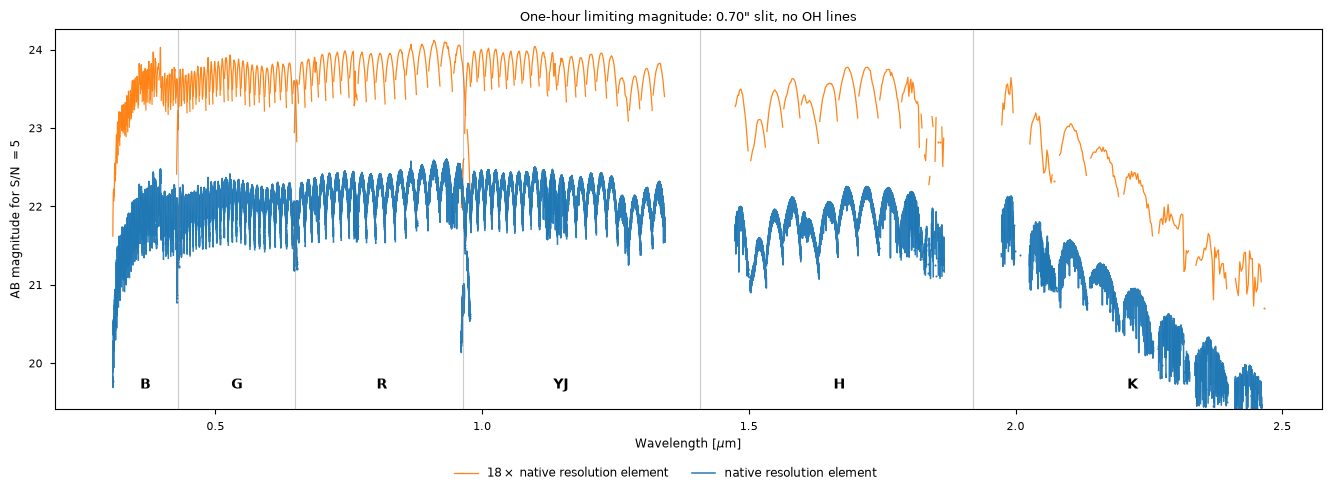

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/limiting_magnitude.pdf')

In [37]:
# Stage 3 display control; the raw calculated rows remain unchanged.
PLOT_DYNAMIC_RANGE_MAG = 0.9

initial_no_oh_limiting_magnitude_curves = fixed_bin_no_oh_limiting_magnitude_curves(zero_point_samples_raw, bin_factors=(1, 18), integration="1 hour", slit_arcsec=0.70, ao_enabled=False)
initial_no_oh_plot_specs = [
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
        "label": r"$18\times$ native resolution element",
        "color": plt.rcParams["axes.prop_cycle"].by_key()["color"][1],
        "linewidth_multiplier": 0.65,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 1,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
        "label": "native resolution element",
        "color": plt.rcParams["axes.prop_cycle"].by_key()["color"][0],
        "linewidth_multiplier": 0.80,
    },
]
fig, ax = plot_limiting_magnitude_curves(initial_no_oh_limiting_magnitude_curves, initial_no_oh_plot_specs, title=f"One-hour limiting magnitude: {zero_point_case_label}, no OH lines", dynamic_range_mag=PLOT_DYNAMIC_RANGE_MAG)
display_and_save_figure(fig, "limiting_magnitude")


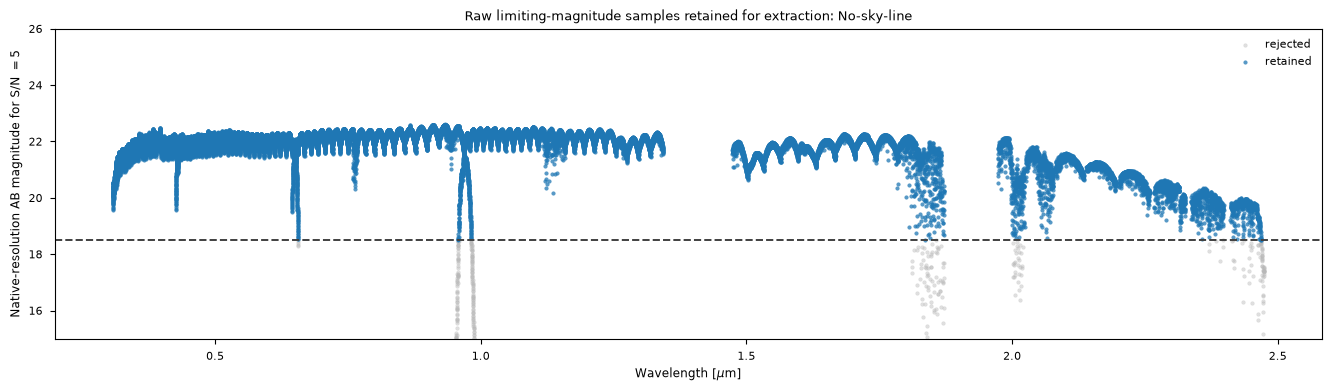

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/raw_limiting_magnitude_sampling.pdf')

In [38]:
native_rows = zero_point_samples_raw["bin_factor"] == 1
native_samples = zero_point_samples_raw[native_rows]
native_keep = worth_extracting[native_rows]

fig, ax = plt.subplots(figsize=(13.2, 3.8), constrained_layout=True)
ax.scatter(native_samples["wave_nm"][~native_keep] / 1000, native_samples["m5_ab"][~native_keep], s=7, color="0.72", alpha=0.45, label="rejected")
ax.scatter(native_samples["wave_nm"][native_keep] / 1000, native_samples["m5_ab"][native_keep], s=7, color=plt.rcParams["axes.prop_cycle"].by_key()["color"][0], alpha=0.75, label="retained")
ax.axhline(clip_zp_below, color="0.25", linestyle="--", linewidth=plt.rcParams["lines.linewidth"])
ax.set(xlabel=r"Wavelength [$\mu\mathrm{m}$]", ylabel=r"Native-resolution AB magnitude for S/N $= 5$", title=f"Raw limiting-magnitude samples retained for extraction: {zero_point_run_label}", ylim=(15, 26))
ax.legend(frameon=False)
display_and_save_figure(fig, "raw_limiting_magnitude_sampling")


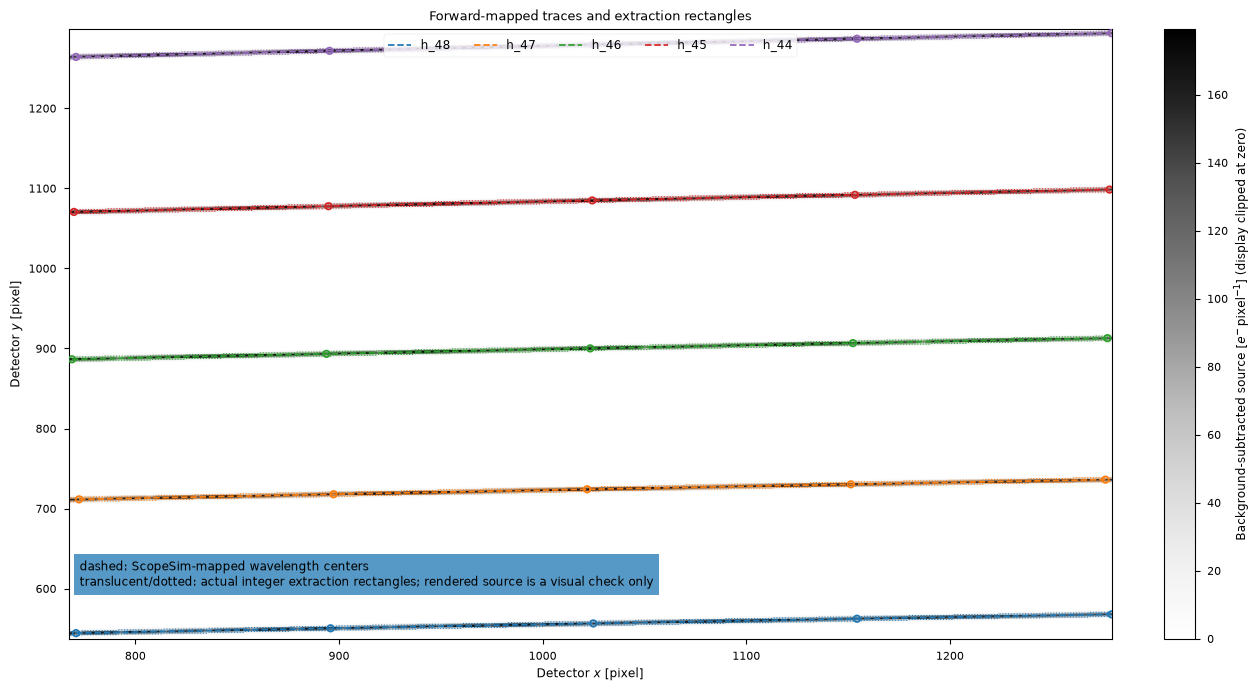

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/trace_extraction_geometry.pdf')

In [39]:
channel = "H"
channel_index = readout_titles.index(channel)
channel_trace_samples = trace_resolution[trace_resolution["channel"] == channel]
validation_coordinates = trace_sample_detector_coordinates(zs, channel_trace_samples)

source_products = readout_signal_background_products(readouts["source_no_sky_lines"], readouts["background_no_sky_lines"], detector_budget, readout_titles)[channel]
source_signal = source_products["signal"]
height, width = source_signal.shape
display_x0 = int(np.floor(0.375 * width))
display_x1 = int(np.ceil(0.625 * width))

configured_trace_ids = set(np.asarray(validation_coordinates["trace_id"], dtype=str))
central_trace_rows = []
for trace_id in configured_trace_ids:
    order_coordinates = validation_coordinates[validation_coordinates["trace_id"] == trace_id]
    central_x = (order_coordinates["center_x_pix"] >= display_x0) & (order_coordinates["center_x_pix"] < display_x1)
    if np.any(central_x):
        central_trace_rows.append((np.median(order_coordinates["center_y_pix"][central_x]), trace_id))

central_trace_rows.sort()
if len(central_trace_rows) < 5:
    raise RuntimeError("Fewer than five mapped H traces cross the central detector region")
middle = len(central_trace_rows) // 2
first = min(max(0, middle - 2), len(central_trace_rows) - 5)
selected_trace_ids = [trace_id for _center_y, trace_id in central_trace_rows[first:first + 5]]

selected_coordinates = validation_coordinates[np.isin(validation_coordinates["trace_id"], selected_trace_ids)]
central_x = (selected_coordinates["center_x_pix"] >= display_x0) & (selected_coordinates["center_x_pix"] < display_x1)
selected_coordinates = selected_coordinates[central_x]
maximum_aperture_width = max(zero_point_trace_apertures[(channel, trace_id)]["spatial_width_pix"] for trace_id in selected_trace_ids)
display_y0 = max(0, int(np.floor(np.min(selected_coordinates["center_y_pix"]) - 0.5 * maximum_aperture_width - 3)))
display_y1 = min(height, int(np.ceil(np.max(selected_coordinates["center_y_pix"]) + 0.5 * maximum_aperture_width + 3)))

signal_cut = np.clip(source_signal[display_y0:display_y1, display_x0:display_x1], 0, None)
positive_signal = signal_cut[signal_cut > 0]
display_maximum = np.percentile(positive_signal, 99.7) if positive_signal.size else 1.0

fig, ax = plt.subplots(figsize=(12.5, 6.8), constrained_layout=True)
image = ax.imshow(signal_cut, origin="lower", cmap="Greys", vmin=0, vmax=display_maximum, interpolation="nearest", aspect="auto", extent=(display_x0 - 0.5, display_x1 - 0.5, display_y0 - 0.5, display_y1 - 0.5))
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
trace_handles = []

for color, trace_id in zip(colors, selected_trace_ids, strict=False):
    order_coordinates = selected_coordinates[selected_coordinates["trace_id"] == trace_id]
    order_coordinates.sort("center_x_pix")
    center_line, = ax.plot(order_coordinates["center_x_pix"], order_coordinates["center_y_pix"], color=color, linewidth=0.9 * plt.rcParams["lines.linewidth"], linestyle="--", label=trace_id)
    trace_handles.append(center_line)

    sample_indices = np.unique(np.rint(np.linspace(0, len(order_coordinates) - 1, 5)).astype(int))
    marked = order_coordinates[sample_indices]
    ax.scatter(marked["center_x_pix"], marked["center_y_pix"], s=22, facecolor="none", edgecolor=color, linewidth=0.9 * plt.rcParams["lines.linewidth"], zorder=4)

    mask_cut = zero_point_order_weight_maps[(channel, trace_id)][display_y0:display_y1, display_x0:display_x1,]
    if np.any(mask_cut):
        ax.contourf(np.arange(display_x0, display_x1), np.arange(display_y0, display_y1), mask_cut, levels=[0.5, 1.5], colors=[color], alpha=0.12)
        ax.contour(np.arange(display_x0, display_x1), np.arange(display_y0, display_y1), mask_cut, levels=[0.5], colors=[color], linewidths=0.55 * plt.rcParams["lines.linewidth"], linestyles=":")

ax.legend(handles=trace_handles, frameon=True, ncol=5, loc="upper center", fontsize="small")
ax.set(xlabel=r"Detector $x$ [pixel]", ylabel=r"Detector $y$ [pixel]", title="Forward-mapped traces and extraction rectangles")
ax.set_xlim(display_x0 - 0.5, display_x1 - 0.5)
ax.set_ylim(display_y0 - 0.5, display_y1 - 0.5)
ax.text(0.01, 0.08, "dashed: ScopeSim-mapped wavelength centers" "\ntranslucent/dotted: actual integer extraction rectangles; rendered source is a visual check only", transform=ax.transAxes, fontsize="small", ha="left", va="bottom", bbox={ "edgecolor": "none", "alpha": 0.75})
fig.colorbar(image, ax=ax, label=r"Background-subtracted source [$e^{-}\,\mathrm{pixel}^{-1}$] (display clipped at zero)")

display_and_save_figure(fig, "trace_extraction_geometry")


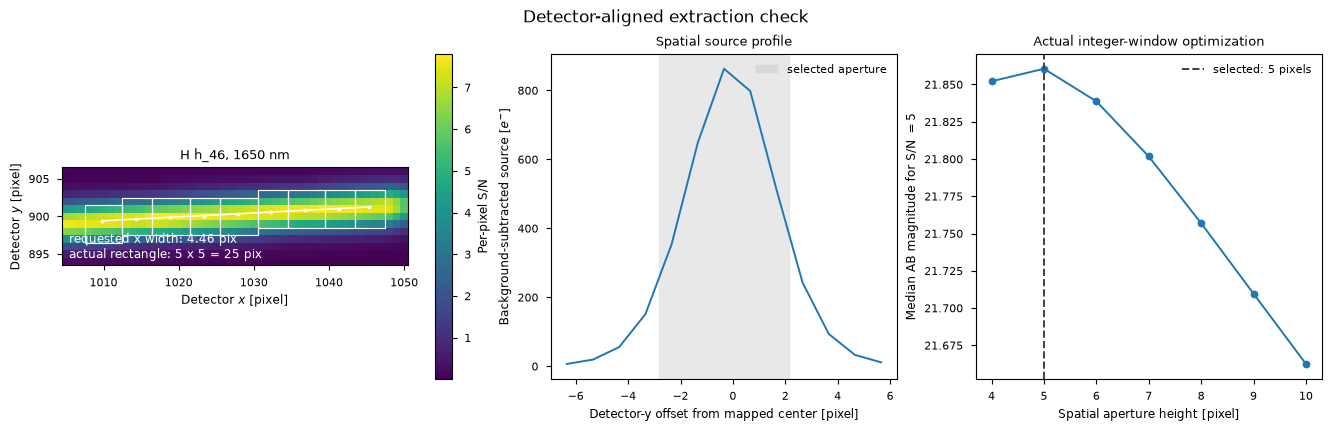

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/extraction_check.pdf')

In [40]:
channel = "H"
native_selected = zero_point_samples_selected[(zero_point_samples_selected["channel"] == channel) & (zero_point_samples_selected["bin_factor"] == 1)]
representative_row = native_selected[np.argmin(np.abs(native_selected["wave_nm"] - 1650))]
trace_id = str(representative_row["trace_id"])
trace_native = native_selected[native_selected["trace_id"] == trace_id]
trace_native = trace_native[np.argsort(trace_native["sample_index"])]
representative_index = int(np.flatnonzero(trace_native["sample_index"] == representative_row["sample_index"])[0])
display_start = max(0, representative_index - 4)
display_rows = trace_native[display_start:min(len(trace_native), display_start + 9)]
assert np.array_equal(display_rows["x1"][:-1], display_rows["x0"][1:])
assert np.all(np.diff(display_rows["sample_index"]) == 1)
aperture = zero_point_trace_apertures[(channel, trace_id)]

x0, x1 = int(representative_row["x0"]), int(representative_row["x1"])
y0, y1 = int(representative_row["y0"]), int(representative_row["y1"])
spectral_width_pix = int(representative_row["spectral_width_pix"])
spatial_width_pix = int(representative_row["spatial_width_pix"])
n_pix = int(representative_row["n_pix"])

selected_y, selected_x = np.mgrid[y0:y1, x0:x1]
selected_y = selected_y.ravel()
selected_x = selected_x.ravel()
assert n_pix == spectral_width_pix * spatial_width_pix
assert np.array_equal(np.unique(selected_x), np.arange(x0, x1))
assert np.array_equal(np.unique(selected_y), np.arange(y0, y1))
for x_pix in range(x0, x1):
    assert np.array_equal(selected_y[selected_x == x_pix], np.arange(y0, y1))
for y_pix in range(y0, y1):
    assert np.array_equal(selected_x[selected_y == y_pix], np.arange(x0, x1))

products = readout_signal_background_products(readouts["source_no_sky_lines"], readouts["background_no_sky_lines"], detector_budget, readout_titles)[channel]
height, width = products["signal"].shape
edge_coordinate = {
    "detector_x0_pix": -spectral_width_pix,
    "detector_x1_pix": 0,
    "center_x_pix": 0.0,
    "center_y_pix": float(representative_row["detector_y_pix"]),
    "spectral_fwhm_pix": float(representative_row["spectral_fwhm_pix"]),
}
assert trace_sample_pixel_rectangle(edge_coordinate, (height, width), spatial_width_pix) is None
plot_x0, plot_x1 = max(0, int(display_rows["x0"][0]) - 3), min(width, int(display_rows["x1"][-1]) + 3)
plot_y0 = max(0, int(np.min(display_rows["y0"])) - 3)
plot_y1 = min(height, int(np.max(display_rows["y1"])) + 3)
signal_cut = products["signal"][plot_y0:plot_y1, plot_x0:plot_x1]
variance_cut = signal_cut + 2 * products["sky"][plot_y0:plot_y1, plot_x0:plot_x1] + 2 * products["detector_variance_e2_pix"]
snr_cut = signal_cut / np.sqrt(variance_cut)

profile_coordinate = np.arange(plot_y0, plot_y1) - float(representative_row["detector_y_pix"])
source_profile = products["signal"][plot_y0:plot_y1, x0:x1].sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), constrained_layout=True)
image = axes[0].imshow(snr_cut, origin="lower", cmap="viridis", extent=(plot_x0 - 0.5, plot_x1 - 0.5, plot_y0 - 0.5, plot_y1 - 0.5))
for row in display_rows:
    axes[0].add_patch(plt.Rectangle((int(row["x0"]) - 0.5, int(row["y0"]) - 0.5), int(row["x1"] - row["x0"]), int(row["y1"] - row["y0"]), fill=False, edgecolor="white", linewidth=0.6 * plt.rcParams["lines.linewidth"]))
axes[0].plot(display_rows["detector_x_pix"], display_rows["detector_y_pix"], color="white", linewidth=0.8 * plt.rcParams["lines.linewidth"], marker=".")
axes[0].set(title=rf"{channel} {trace_id}, {float(representative_row['wave_nm']):.0f} nm", xlabel=r"Detector $x$ [pixel]", ylabel=r"Detector $y$ [pixel]")
axes[0].text(0.02, 0.03, f"requested x width: {float(representative_row['spectral_fwhm_pix']):.2f} pix" f"\nactual rectangle: {spectral_width_pix} x {spatial_width_pix} = {n_pix} pix", transform=axes[0].transAxes, fontsize="small", color="white", ha="left", va="bottom")
fig.colorbar(image, ax=axes[0], label="Per-pixel S/N")

axes[1].plot(profile_coordinate, source_profile)
axes[1].axvspan(y0 - 0.5 - float(representative_row["detector_y_pix"]), y1 - 0.5 - float(representative_row["detector_y_pix"]), color="0.75", alpha=0.35, label="selected aperture")
axes[1].set(xlabel="Detector-y offset from mapped center [pixel]", ylabel=r"Background-subtracted source [$e^{-}$]", title="Spatial source profile")
axes[1].legend(frameon=False)

axes[2].plot(aperture["width_grid_pix"], aperture["width_median_m5_ab"], marker="o")
axes[2].axvline(aperture["spatial_width_pix"], color="0.25", linestyle="--", label=f"selected: {aperture['spatial_width_pix']} pixels")
axes[2].set(xlabel="Spatial aperture height [pixel]", ylabel=r"Median AB magnitude for S/N $= 5$", title="Actual integer-window optimization")
axes[2].legend(frameon=False)

fig.suptitle("Detector-aligned extraction check")
display_and_save_figure(fig, "extraction_check")


## Airglow-background difference and order peaks

The airglow-disabled calculation defines the aperture widths, detector rectangles, and wavelength samples. The baseline simulation is re-extracted at those exact locations. The source-signal fraction is retained as a numerical guard on the paired extraction, not as a sky-line mask or wavelength-coverage rule; every current sample passes it.


In [41]:
SOURCE_SIGNAL_FRACTION_MIN = 0.90

natural_airglow_comparison_samples_raw = airglow_comparison_samples_table(zero_point_samples_raw, readouts["source_full_background"], readouts["full_background"], detector_budget, readout_titles, source_signal_fraction_min=SOURCE_SIGNAL_FRACTION_MIN)
natural_airglow_complete = (natural_airglow_comparison_samples_raw["native_count"] == natural_airglow_comparison_samples_raw["bin_factor"]) & np.isfinite(natural_airglow_comparison_samples_raw["m5_ab"]) & (natural_airglow_comparison_samples_raw["m5_ab"] >= clip_zp_below)
natural_airglow_comparison_samples = natural_airglow_comparison_samples_raw[natural_airglow_complete]
assert np.all(natural_airglow_comparison_samples["source_signal_fraction_above_min"])

natural_airglow_rows = natural_airglow_comparison_samples.to_pandas()
natural_airglow_finite = natural_airglow_rows[natural_airglow_rows["source_signal_fraction_above_min"] & np.isfinite(natural_airglow_rows["simulation_m5_ab"]) & np.isfinite(natural_airglow_rows["airglow_background_delta_m5"])]
order_airglow_deltas = natural_airglow_finite.groupby(["channel", "bin_factor", "trace_id"], sort=False)["airglow_background_delta_m5"].median().reset_index()

airglow_delta_rows = []
for channel in readout_titles:
    for bin_factor in sorted(set(natural_airglow_rows["bin_factor"])):
        candidates = natural_airglow_rows[(natural_airglow_rows["channel"] == channel) & (natural_airglow_rows["bin_factor"] == bin_factor)]
        order_deltas = order_airglow_deltas[(order_airglow_deltas["channel"] == channel) & (order_airglow_deltas["bin_factor"] == bin_factor)]["airglow_background_delta_m5"].to_numpy()
        airglow_delta_rows.append({
            "ch": channel,
            "bin": int(bin_factor),
            "orders": len(order_deltas),
            "source fraction above minimum": np.count_nonzero(candidates["source_signal_fraction_above_min"]),
            "samples": len(candidates),
            "delta m5 minimum": np.min(order_deltas),
            "delta m5 median": np.median(order_deltas),
            "delta m5 maximum": np.max(order_deltas),
        })

print("delta m5 = m5(OH/airglow disabled) - m5(simulation); " "positive values mean the baseline simulation is shallower.")
print(f"Source-signal fraction guard: {len(natural_airglow_rows):,}/{len(natural_airglow_rows):,} " f"samples are at least {SOURCE_SIGNAL_FRACTION_MIN:.0%} of the airglow-disabled signal.")
display_frame(airglow_delta_rows,
    formats={
        "delta m5 minimum": "{:+.2f}",
        "delta m5 median": "{:+.2f}",
        "delta m5 maximum": "{:+.2f}",
    }
)


delta m5 = m5(OH/airglow disabled) - m5(simulation); positive values mean the baseline simulation is shallower.
Source-signal fraction guard: 36,845/36,845 samples are at least 90% of the airglow-disabled signal.


ch,bin,orders,source fraction above minimum,samples,delta m5 minimum,delta m5 median,delta m5 maximum
B,1,34,6046,6046,+0.00,+0.00,+0.01
B,18,34,319,319,+0.00,+0.01,+0.03
G,1,30,7730,7730,+0.00,+0.00,+0.00
G,18,30,415,415,+0.00,+0.00,+0.08
R,1,20,7438,7438,+0.00,+0.00,+0.04
R,18,20,408,408,+0.00,+0.16,+0.64
YJ,1,23,6029,6029,+0.00,+0.00,+1.07
YJ,18,23,327,327,+0.13,+0.75,+1.71
H,1,11,4144,4144,+0.00,+0.00,+0.16
H,18,11,233,233,+0.22,+1.01,+1.48


### Focused R\~1000 calculation

The baseline simulation includes the configured airglow lines and interline continuum, and every detector pixel in each broad R\~1000 rectangle contributes to the extracted signal and variance. The hypothetical comparison disables that entire background effect; it does not identify or reject contaminated pixels. The display keys selected from the disabled-airglow calculation are imposed unchanged on the baseline simulation so that strongly airglow-contaminated rectangles remain visible.


In [42]:
R1000_CASE_LABEL = zero_point_case_label
R1000_BIN_FACTOR = 18

# These are the existing bin-18 rows in the paired natural-seeing ledger.
# They are identical to the former separately reconstructed R~1000 table.
r1000_no_rejection_samples = natural_airglow_comparison_samples[natural_airglow_comparison_samples["bin_factor"] == R1000_BIN_FACTOR]
assert np.all(r1000_no_rejection_samples["native_count"] == R1000_BIN_FACTOR)
assert np.all(r1000_no_rejection_samples["source_signal_fraction_above_min"])
print(f"Focused R~1000 product: {len(r1000_no_rejection_samples):,} complete " "paired samples from the natural-seeing ledger.")


Focused R~1000 product: 1,901 complete paired samples from the natural-seeing ledger.


case,ch,bin,order,N,min mAB5,median mAB5,max mAB5,peak wavelength [nm]
airglow_disabled,B,1,b_85,212,20.87,21.84,22.11,427.4
airglow_disabled,B,1,b_86,209,21.45,21.98,22.28,422.8
airglow_disabled,B,1,b_87,207,21.38,21.98,22.21,418.8
airglow_disabled,B,1,b_88,203,21.37,21.92,22.16,413.6
airglow_disabled,B,1,b_89,201,21.34,21.95,22.13,410.1
airglow_disabled,B,1,b_90,200,21.36,21.90,22.20,404.7
airglow_disabled,B,1,b_91,197,21.33,21.90,22.13,400.6
airglow_disabled,B,1,b_92,194,21.42,22.09,22.48,396.9
airglow_disabled,B,1,b_93,192,21.64,22.07,22.25,393.2
airglow_disabled,B,1,b_94,191,21.46,22.10,22.35,387.3


Numerical peaks are raw sampled maxima. No smoothing is used to select them; the explicit limiting-magnitude display threshold removes lower values.


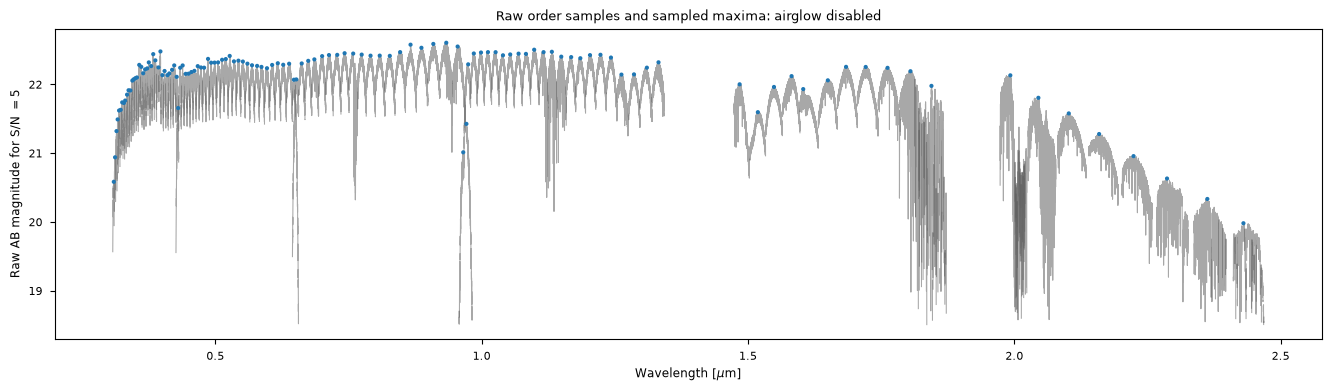

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/order_peak_sampling.pdf')

In [43]:
ORDER_PEAK_CASES = ("airglow_disabled",)  # add "simulation" to inspect both
ORDER_PEAK_BIN_FACTORS = (1,)
ORDER_PEAK_M5_MIN = clip_zp_below

peak_case_rows_by_sky = {}
airglow_disabled_rows = natural_airglow_comparison_samples.to_pandas()
peak_case_rows_by_sky["airglow_disabled"] = airglow_disabled_rows[np.isfinite(airglow_disabled_rows["m5_ab"]) & (airglow_disabled_rows["m5_ab"] >= ORDER_PEAK_M5_MIN)].copy()

simulation_rows = airglow_disabled_rows[airglow_disabled_rows["source_signal_fraction_above_min"] & np.isfinite(airglow_disabled_rows["simulation_m5_ab"]) & (airglow_disabled_rows["simulation_m5_ab"] >= ORDER_PEAK_M5_MIN)].copy()
simulation_rows["m5_ab"] = simulation_rows["simulation_m5_ab"]
peak_case_rows_by_sky["simulation"] = simulation_rows

order_peak_rows = []
for case_name in ORDER_PEAK_CASES:
    case_rows = peak_case_rows_by_sky[case_name]
    case_rows = case_rows[case_rows["bin_factor"].isin(ORDER_PEAK_BIN_FACTORS)]
    for (channel, bin_factor, trace_id), order_rows in case_rows.groupby(["channel", "bin_factor", "trace_id"], sort=False):
        values = order_rows["m5_ab"].to_numpy(dtype=float)
        peak = order_rows.iloc[int(np.argmax(values))]
        order_peak_rows.append({
            "case": case_name,
            "ch": channel,
            "bin": int(bin_factor),
            "order": trace_id,
            "N": len(order_rows),
            "min mAB5": np.min(values),
            "median mAB5": np.median(values),
            "max mAB5": np.max(values),
            "peak wavelength [nm]": peak["wave_nm"],
        })

order_peak_table = Table(rows=order_peak_rows)
display_frame(order_peak_table,
    formats={
        "min mAB5": "{:.2f}",
        "median mAB5": "{:.2f}",
        "max mAB5": "{:.2f}",
        "peak wavelength [nm]": "{:.1f}",
    }
)

fig, axes = plt.subplots(len(ORDER_PEAK_CASES), 1, figsize=(13.2, 3.8 * len(ORDER_PEAK_CASES)), squeeze=False, constrained_layout=True)
for ax, case_name in zip(axes[:, 0], ORDER_PEAK_CASES, strict=True):
    case_rows = peak_case_rows_by_sky[case_name]
    case_rows = case_rows[case_rows["bin_factor"].isin(ORDER_PEAK_BIN_FACTORS)]
    for (_channel, _bin_factor, _trace_id), order_rows in case_rows.groupby(["channel", "bin_factor", "trace_id"], sort=False):
        order_rows = order_rows.sort_values("bin_index")
        run = np.cumsum(np.r_[True, np.diff(order_rows["bin_index"].to_numpy(dtype=int)) != 1])
        for _run, run_rows in order_rows.groupby(run, sort=False):
            ax.plot(run_rows["wave_nm"] / 1000, run_rows["m5_ab"], color="0.38", linewidth=0.55 * plt.rcParams["lines.linewidth"], alpha=0.55)
        peak = order_rows.iloc[int(np.argmax(order_rows["m5_ab"].to_numpy(dtype=float)))]
        ax.scatter(peak["wave_nm"] / 1000, peak["m5_ab"], s=9, color=plt.rcParams["axes.prop_cycle"].by_key()["color"][0], edgecolor="none", zorder=3)
    ax.set(xlabel=r"Wavelength [$\mu\mathrm{m}$]", ylabel=r"Raw AB magnitude for S/N $= 5$", title=f"Raw order samples and sampled maxima: {case_name.replace('_', ' ')}")

print("Numerical peaks are raw sampled maxima. No smoothing is used to select them; " "the explicit limiting-magnitude display threshold removes lower values.")
display_and_save_figure(fig, "order_peak_sampling")


## Slit, Resolution, AO, And Integration Cases

The paper cases below reuse one live `OpticalTrain`. Slit and exposure settings are changed on `zs.cmds`, AO is toggled on the configured PSF effect, and ScopeSim performs its normal update for every observation so each readout starts from empty image planes.

The one-hour cases use the AB 20 flat point source. The five-minute cases use the otherwise identical AB 17 source: the shorter exposure and three-magnitude source change produce only about 1.32 times the one-hour source electrons, improving subtraction precision without requiring a different zero-point equation. Backgrounds are shared between AO and natural-seeing source readouts at the same slit and exposure.

Each readout group is reduced immediately to trace-sample tables. Spectral bin factors are calculations on those tables, not additional simulations. The final table contains the eight requested slit/resolution/AO cases for each integration.

All scenario readouts below disable the `sky_lines` effect. The baseline reuses the completed no-line pair; only the changed slit, AO, and exposure cases require new simulations.


In [44]:
def set_train_ao_state(train, enabled):
    psf = get_effect(train, "seeing_psf", active_only=False)
    psf.meta["enable_ao"] = bool(enabled)


def reduce_zero_point_case(label, *, source_hdul, background_hdul, detector_table, trace_samples,
                           input_abmag, bin_factors, slit_arcsec, ao_enabled, integration, dit, ndit,
                           aperture_calibration=None):

    samples, apertures = trace_zero_point_samples_table(zs, source_hdul, background_hdul, detector_table, trace_samples, readout_titles, input_abmag=input_abmag, case_label=label, bin_factors=bin_factors, aperture_calibration=aperture_calibration, return_apertures=True)

    full_bins = samples["native_count"] == samples["bin_factor"]
    finite = full_bins & np.isfinite(samples["m5_ab"])
    selected = finite & (samples["m5_ab"] >= clip_zp_below)

    best_zp_table = best_zero_point_order_table(samples[selected])

    return {"label": label, "integration": integration, "dit": dit, "ndit": ndit, "slit_arcsec": slit_arcsec, "ao_enabled": ao_enabled, "input_abmag": input_abmag,
            "samples_raw": samples, "samples_complete": samples[finite], "samples_selected": samples[selected], "order_best": best_zp_table, "apertures": apertures,
            }


paper_case_results = {}

# Existing .70", one-hour, natural-seeing readouts.
paper_case_results[("1 hour", 0.70, False)] = reduce_zero_point_case('1 hour, 0.70" slit', source_hdul=readouts["source_no_sky_lines"], background_hdul=readouts["background_no_sky_lines"], detector_table=detector_budget, trace_samples=trace_resolution, input_abmag=20.0, bin_factors=(1, 2, 18), slit_arcsec=0.70, ao_enabled=False, integration="1 hour", dit=1800, ndit=2, aperture_calibration=zero_point_trace_apertures)

# .33", one hour. The background is common to natural seeing and AO.
set_channel_exposure(zs.cmds, dit=1800, ndit=2)
zs.cmds["!INST.vis_curr_slit"] = 0.33
zs.cmds["!INST.nir_curr_slit"] = 0.33
zs.update()
set_train_ao_state(zs, False)
narrow_detector_budget_1h = detector_background_budget_table(zs)
narrow_background_1h = observe_readout(None, ["sky_lines"])
narrow_trace_noao_1h = trace_resolution_diagnostic_table(zs)
narrow_source_noao_1h = observe_readout(flat_ab_point_center, ["sky_lines"])
paper_case_results[("1 hour", 0.33, False)] = reduce_zero_point_case('1 hour, 0.33" slit, natural', source_hdul=narrow_source_noao_1h, background_hdul=narrow_background_1h, detector_table=narrow_detector_budget_1h, trace_samples=narrow_trace_noao_1h, input_abmag=20.0, bin_factors=(1, 18, 40), slit_arcsec=0.33, ao_enabled=False, integration="1 hour", dit=1800, ndit=2)

set_train_ao_state(zs, True)
narrow_trace_ao_1h = trace_resolution_diagnostic_table(zs)
narrow_source_ao_1h = observe_readout(flat_ab_point_center, ["sky_lines"])
paper_case_results[("1 hour", 0.33, True)] = reduce_zero_point_case('1 hour, 0.33" slit, AO', source_hdul=narrow_source_ao_1h, background_hdul=narrow_background_1h, detector_table=narrow_detector_budget_1h, trace_samples=narrow_trace_ao_1h, input_abmag=20.0, bin_factors=(1, 2, 4, 18, 38, 40), slit_arcsec=0.33, ao_enabled=True, integration="1 hour", dit=1800, ndit=2)
del narrow_background_1h, narrow_source_noao_1h, narrow_source_ao_1h

# .70", five minutes, natural seeing.
set_channel_exposure(zs.cmds, dit=300, ndit=1)
zs.cmds["!INST.vis_curr_slit"] = 0.70
zs.cmds["!INST.nir_curr_slit"] = 0.70
zs.update()
set_train_ao_state(zs, False)
wide_detector_budget_5m = detector_background_budget_table(zs)
wide_background_5m = observe_readout(None, ["sky_lines"])
wide_trace_5m = trace_resolution_diagnostic_table(zs)
wide_source_5m = observe_readout(flat_ab_point_center_5min, ["sky_lines"])
paper_case_results[("5 minutes", 0.70, False)] = reduce_zero_point_case('5 minutes, 0.70" slit', source_hdul=wide_source_5m, background_hdul=wide_background_5m, detector_table=wide_detector_budget_5m, trace_samples=wide_trace_5m, input_abmag=17.0, bin_factors=(1, 2, 18), slit_arcsec=0.70, ao_enabled=False, integration="5 minutes", dit=300, ndit=1)
del wide_background_5m, wide_source_5m

# .33", five minutes. The background is common to natural seeing and AO.
zs.cmds["!INST.vis_curr_slit"] = 0.33
zs.cmds["!INST.nir_curr_slit"] = 0.33
zs.update()
set_train_ao_state(zs, False)
narrow_detector_budget_5m = detector_background_budget_table(zs)
narrow_background_5m = observe_readout(None, ["sky_lines"])
narrow_trace_noao_5m = trace_resolution_diagnostic_table(zs)
narrow_source_noao_5m = observe_readout(flat_ab_point_center_5min, ["sky_lines"])
paper_case_results[("5 minutes", 0.33, False)] = reduce_zero_point_case('5 minutes, 0.33" slit, natural', source_hdul=narrow_source_noao_5m, background_hdul=narrow_background_5m, detector_table=narrow_detector_budget_5m, trace_samples=narrow_trace_noao_5m, input_abmag=17.0, bin_factors=(1, 18, 40), slit_arcsec=0.33, ao_enabled=False, integration="5 minutes", dit=300, ndit=1)

set_train_ao_state(zs, True)
narrow_trace_ao_5m = trace_resolution_diagnostic_table(zs)
narrow_source_ao_5m = observe_readout(flat_ab_point_center_5min, ["sky_lines"])
paper_case_results[("5 minutes", 0.33, True)] = reduce_zero_point_case('5 minutes, 0.33" slit, AO', source_hdul=narrow_source_ao_5m, background_hdul=narrow_background_5m, detector_table=narrow_detector_budget_5m, trace_samples=narrow_trace_ao_5m, input_abmag=17.0, bin_factors=(1, 2, 4, 18, 38, 40), slit_arcsec=0.33, ao_enabled=True, integration="5 minutes", dit=300, ndit=1)
del narrow_background_5m, narrow_source_noao_5m, narrow_source_ao_5m

for key, result in paper_case_results.items():
    print(f"{result['label']}: retained {len(result['samples_selected']):,}/" f"{len(result['samples_complete']):,} samples")

# Leave the notebook in its baseline state.
set_channel_exposure(zs.cmds, dit=1800, ndit=2)
zs.cmds["!INST.vis_curr_slit"] = 0.70
zs.cmds["!INST.nir_curr_slit"] = 0.70
set_train_ao_state(zs, False)
zs.update()
trace_resolution = trace_resolution_diagnostic_table(zs)
trace_resolution_summary = trace_resolution_summary_table(trace_resolution)
detector_budget = detector_background_budget_table(zs)


1 hour, 0.70" slit: retained 54,345/55,376 samples
1 hour, 0.33" slit, natural: retained 79,561/81,764 samples
1 hour, 0.33" slit, AO: retained 137,584/140,468 samples
5 minutes, 0.70" slit: retained 52,852/55,385 samples
5 minutes, 0.33" slit, natural: retained 73,327/81,763 samples
5 minutes, 0.33" slit, AO: retained 132,550/140,467 samples


### AO sky-background calculation

The saved airglow-disabled AO calculation supplies the 38-times-native wavelength samples, optimized spatial widths, and detector rectangles. The baseline source/background pair below is re-extracted through those exact rectangles with the same one-hour exposure; no aperture or wavelength is re-optimized.


In [45]:
AO_LIMITING_CASE_KEY = ("1 hour", 0.33, True)
AO_LIMITING_BIN_FACTOR = 38

ao_limiting_case = paper_case_results[AO_LIMITING_CASE_KEY]
set_channel_exposure(zs.cmds, dit=1800, ndit=2)
zs.cmds["!INST.vis_curr_slit"] = 0.33
zs.cmds["!INST.nir_curr_slit"] = 0.33
zs.update()
set_train_ao_state(zs, True)

ao_detector_budget_1h = detector_background_budget_table(zs)
ao_simulation_background_1h = observe_readout(None, None)
ao_simulation_source_1h = observe_readout(flat_ab_point_center, None)
ao_airglow_comparison_samples_raw = airglow_comparison_samples_table(ao_limiting_case["samples_raw"], ao_simulation_source_1h, ao_simulation_background_1h, ao_detector_budget_1h, readout_titles, source_signal_fraction_min=SOURCE_SIGNAL_FRACTION_MIN, bin_factors=(1, 18, AO_LIMITING_BIN_FACTOR, 40))
ao_airglow_complete = (ao_airglow_comparison_samples_raw["bin_factor"] == AO_LIMITING_BIN_FACTOR) & (ao_airglow_comparison_samples_raw["native_count"] == AO_LIMITING_BIN_FACTOR) & np.isfinite(ao_airglow_comparison_samples_raw["m5_ab"]) & (ao_airglow_comparison_samples_raw["m5_ab"] >= clip_zp_below)
ao_airglow_comparison_samples = ao_airglow_comparison_samples_raw[ao_airglow_complete]
assert np.all(ao_airglow_comparison_samples["bin_factor"] == AO_LIMITING_BIN_FACTOR)
assert np.all(ao_airglow_comparison_samples["source_signal_fraction_above_min"])
print(f"AO source-signal fraction guard: {len(ao_airglow_comparison_samples):,}/" f"{len(ao_airglow_comparison_samples):,} samples pass.")
# del ao_simulation_background_1h, ao_simulation_source_1h, ao_detector_budget_1h

# Restore the baseline train and its derived diagnostics.
set_channel_exposure(zs.cmds, dit=1800, ndit=2)
zs.cmds["!INST.vis_curr_slit"] = 0.70
zs.cmds["!INST.nir_curr_slit"] = 0.70
set_train_ao_state(zs, False)
zs.update()
trace_resolution = trace_resolution_diagnostic_table(zs)
trace_resolution_summary = trace_resolution_summary_table(trace_resolution)
detector_budget = detector_background_budget_table(zs)


AO source-signal fraction guard: 1,911/1,911 samples pass.


## Limiting-magnitude curve catalog

`sky_model` distinguishes the configured baseline simulation (including airglow lines and interline continuum) from the matched hypothetical `no OH` calculation with that effect disabled. `native_element_selection` records whether every native element contributes or whether the S/N-ranked subset is used.

`contiguous_order_run` starts again when native sample indices, detector rectangles, or wavelength edges cease to be contiguous; `bin_index_within_run` is zero-based within that run. `complete_native_bin` means that a bin contains the requested number of valid contiguous native elements. `retained_wavelength_fraction` is the retained native wavelength-edge width divided by the available width, while `retained_source_signal_fraction` is the corresponding fraction of source signal.

Variance columns are in electron squared. `source_shot_variance_e2` scales with trial source flux. `non_source_variance_e2` is the matched-sky plus detector variance that does not scale with trial source flux; `total_variance_e2` is their sum. The fixed-bin `no OH / all elements` rows below reshape the already calculated `paper_case_results`; they do not recalculate those authoritative limiting magnitudes.


In [46]:
from astropy.table import vstack

# Reusable paired-ledger calculations. Adding another setup is one function
# call here and one table in selection_curve_tables below.
natural_curves, natural_native_selection = snr_selected_spectral_bins(natural_airglow_comparison_samples_raw, bin_factors=(1, 2, 18), integration="1 hour", slit_arcsec=0.70, ao_enabled=False)
ao_curves, ao_native_selection = snr_selected_spectral_bins(ao_airglow_comparison_samples_raw, bin_factors=(1, 2, 4, 38), integration="1 hour", slit_arcsec=0.33, ao_enabled=True)
selection_curve_tables = [natural_curves, ao_curves]

# Reshape every signed-off fixed-bin no-OH product into the same long form.
fixed_curve_tables = []
for (integration, slit_arcsec, ao_enabled), result in paper_case_results.items():
    available_bin_factors = tuple(sorted(set(int(value) for value in result["samples_raw"]["bin_factor"])))
    fixed_curve_tables.append(fixed_bin_no_oh_limiting_magnitude_curves(result["samples_raw"], bin_factors=available_bin_factors, integration=integration, slit_arcsec=slit_arcsec, ao_enabled=ao_enabled))
fixed_bin_no_oh_catalog_rows = vstack(fixed_curve_tables, metadata_conflicts="silent")

# The reusable calculation must reconstruct every corresponding authoritative
# fixed no-OH curve at identical physical bins before duplicates are omitted.
catalog_row_key_columns = [
    "channel", "trace_id", "contiguous_order_run",
    "bin_index_within_run",
]
for reconstructed, slit_arcsec, ao_enabled, bin_factor in (
    (natural_curves, 0.70, False, 1),
    (natural_curves, 0.70, False, 2),
    (natural_curves, 0.70, False, 18),
    (ao_curves, 0.33, True, 1),
    (ao_curves, 0.33, True, 2),
    (ao_curves, 0.33, True, 4),
    (ao_curves, 0.33, True, 38),
):
    reconstructed_frame = reconstructed[(reconstructed["sky_model"] == "no OH") & (reconstructed["native_element_selection"] == "all elements") & (reconstructed["bin_factor"] == bin_factor)].to_pandas().sort_values(catalog_row_key_columns).reset_index(drop=True)
    authoritative_setup = (fixed_bin_no_oh_catalog_rows["integration"] == "1 hour") & np.isclose(fixed_bin_no_oh_catalog_rows["slit_arcsec"], slit_arcsec) & (fixed_bin_no_oh_catalog_rows["ao_enabled"] == ao_enabled) & (fixed_bin_no_oh_catalog_rows["bin_factor"] == bin_factor)
    authoritative_case = (fixed_bin_no_oh_catalog_rows["sky_model"] == "no OH") & (fixed_bin_no_oh_catalog_rows["native_element_selection"] == "all elements")
    authoritative_frame = fixed_bin_no_oh_catalog_rows[authoritative_setup & authoritative_case].to_pandas().sort_values(catalog_row_key_columns).reset_index(drop=True)
    assert reconstructed_frame[catalog_row_key_columns].equals(authoritative_frame[catalog_row_key_columns])
    np.testing.assert_allclose(reconstructed_frame["limiting_magnitude_ab"], authoritative_frame["limiting_magnitude_ab"], rtol=0, atol=2e-13)

selection_curve_rows = vstack(selection_curve_tables, metadata_conflicts="silent")
selection_rows_for_catalog = ~((selection_curve_rows["sky_model"] == "no OH") & (selection_curve_rows["native_element_selection"] == "all elements"))
limiting_magnitude_curves = vstack([
    fixed_bin_no_oh_catalog_rows,
    selection_curve_rows[selection_rows_for_catalog],
], metadata_conflicts="silent")

catalog_curve_key_columns = [
    "integration", "slit_arcsec", "ao_enabled", "bin_factor",
    "sky_model", "native_element_selection",
]
catalog_frame = limiting_magnitude_curves.to_pandas()
assert not catalog_frame.duplicated([*catalog_curve_key_columns, "channel", "trace_id", "contiguous_order_run", "bin_index_within_run",]).any()

limiting_magnitude_curve_inventory = catalog_frame.groupby(catalog_curve_key_columns, sort=False)["calculated_resolving_power"].median().reset_index().rename(columns={
        "slit_arcsec": "slit [as]",
        "ao_enabled": "observing mode",
        "bin_factor": "bin factor",
        "calculated_resolving_power": "median R",
        "sky_model": "sky model",
        "native_element_selection": "native-element selection",
    })
limiting_magnitude_curve_inventory["observing mode"] = np.where(limiting_magnitude_curve_inventory["observing mode"], "AO", "natural seeing")
display_frame(limiting_magnitude_curve_inventory, formats={"slit [as]": "{:.2f}", "median R": "{:.0f}"})


integration,slit [as],observing mode,bin factor,sky model,native-element selection,median R
1 hour,0.70,natural seeing,1,no OH,all elements,17941
1 hour,0.70,natural seeing,2,no OH,all elements,8973
1 hour,0.70,natural seeing,18,no OH,all elements,999
1 hour,0.33,natural seeing,1,no OH,all elements,38057
1 hour,0.33,natural seeing,18,no OH,all elements,2117
1 hour,0.33,natural seeing,40,no OH,all elements,954
1 hour,0.33,AO,1,no OH,all elements,38057
1 hour,0.33,AO,2,no OH,all elements,19031
1 hour,0.33,AO,4,no OH,all elements,9516
1 hour,0.33,AO,18,no OH,all elements,2117


## Limiting magnitude with simulated sky and disabled airglow

These three one-hour diagnostics use the same wavelength samples and detector rectangles within each pair. The baseline **Simulation** retains the configured airglow lines and interline continuum. **OH/airglow disabled** is a hypothetical change to that configured background component; it is not a pixel-selection algorithm.

1. The focused natural-seeing, 0.70-arcsec-slit, R\~1000 figure includes every detector pixel in each broad extraction rectangle. Its disabled-airglow display keys are imposed unchanged on the simulation, deliberately retaining the large variation from contaminated broad rectangles.
2. The natural-seeing, 0.70-arcsec-slit, approximately R\~1000 figure selects the simulation and disabled-airglow displays independently.
3. The AO, 0.33-arcsec-slit, approximately R\~1000 figure also selects the two displays independently.

For the latter two figures, gaps are display-defined useful coverage rather than a common-sample comparison. The source-signal-fraction threshold is only a guard on recovered source signal, and every current row passes it. The compact table reports $\Delta m_5=m_5(\mathrm{OH/airglow\ disabled})-m_5(\mathrm{simulation})$ at the common displayed R\~1000 wavelengths; positive values mean that the baseline simulation is shallower.

**Deferred diagnostic:** native-resolution samples independently established to lie off the airglow lines could be used to isolate the expected smooth interline contribution. The present selection does not establish that its samples are line-free.


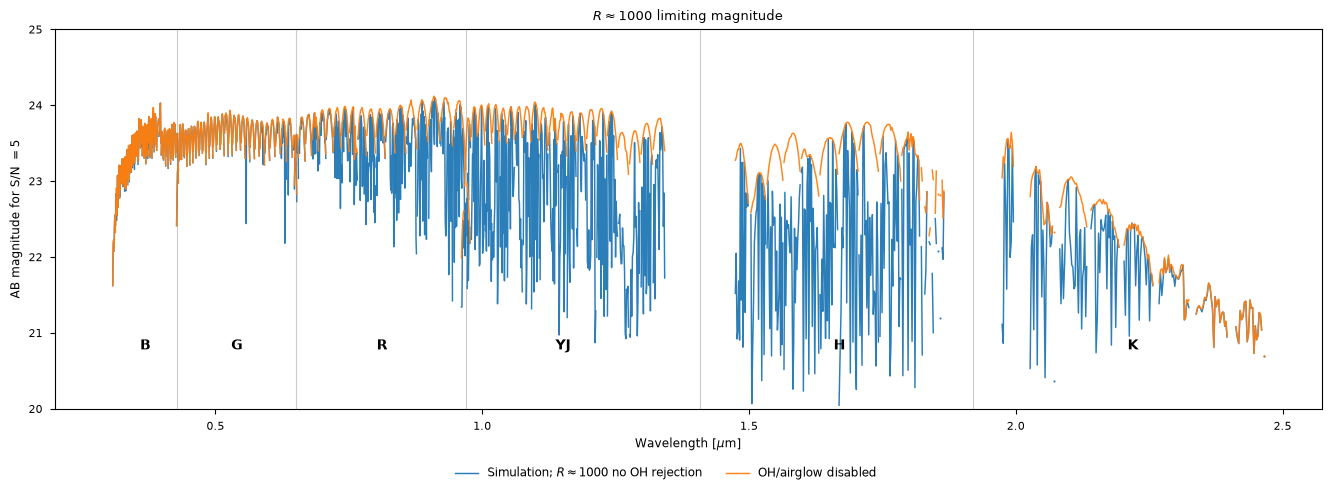

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/r1000_oh_rejection_comparison.pdf')

In [47]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# 1. Baseline R~1000 simulation and the hypothetical disabled-airglow calculation.
r1000_sky_plot_specs = [
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "simulation",
        "native_element_selection": "all elements",
        "label": r"Simulation; $R\approx1000$ no OH rejection",
        "color": colors[0],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
        "label": "OH/airglow disabled",
        "color": colors[1],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
    },
]
fig, ax = plot_limiting_magnitude_curves(limiting_magnitude_curves, r1000_sky_plot_specs,
    title=r"$R\approx1000$ limiting magnitude",
    dynamic_range_mag=PLOT_DYNAMIC_RANGE_MAG,
    shared_presentation_mask_selector={
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
    },
    minimum_limiting_magnitude_ab=clip_zp_below,
    ylim=(20, 25)
)
display_and_save_figure(fig, "r1000_oh_rejection_comparison")



## Effect of native-element selection

The S/N-ranked result is compared with both simple unweighted strategies at identical fixed native-bin boundaries. The no-OH selected curve remains in the catalog and diagnostics but is intentionally omitted here.


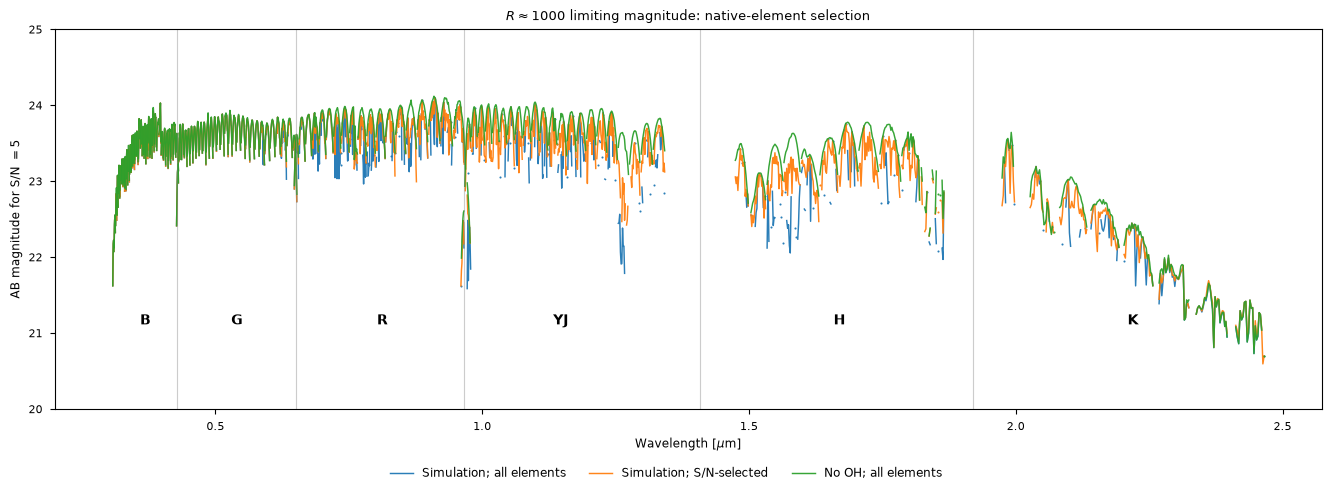

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/snr_selected_r1000_sensitivity.pdf')

In [48]:
native_selection_effect_plot_specs = [
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "simulation",
        "native_element_selection": "all elements",
        "label": "Simulation; all elements",
        "color": colors[0],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "simulation",
        "native_element_selection": "S/N-selected",
        "label": "Simulation; S/N-selected",
        "color": colors[1],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
        "label": "No OH; all elements",
        "color": colors[2],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
    },
]
fig, ax = plot_limiting_magnitude_curves(limiting_magnitude_curves, native_selection_effect_plot_specs, title=r"$R\approx1000$ limiting magnitude: native-element selection", dynamic_range_mag=PLOT_DYNAMIC_RANGE_MAG, ylim=(20, 25))
display_and_save_figure(fig, "snr_selected_r1000_sensitivity")


## Selected AO and natural-seeing comparison

The two simple no-OH curves are the existing fixed-bin products; the paired configured-sky curves use S/N-ranked native elements. Plot and report choices are independent of catalog construction.


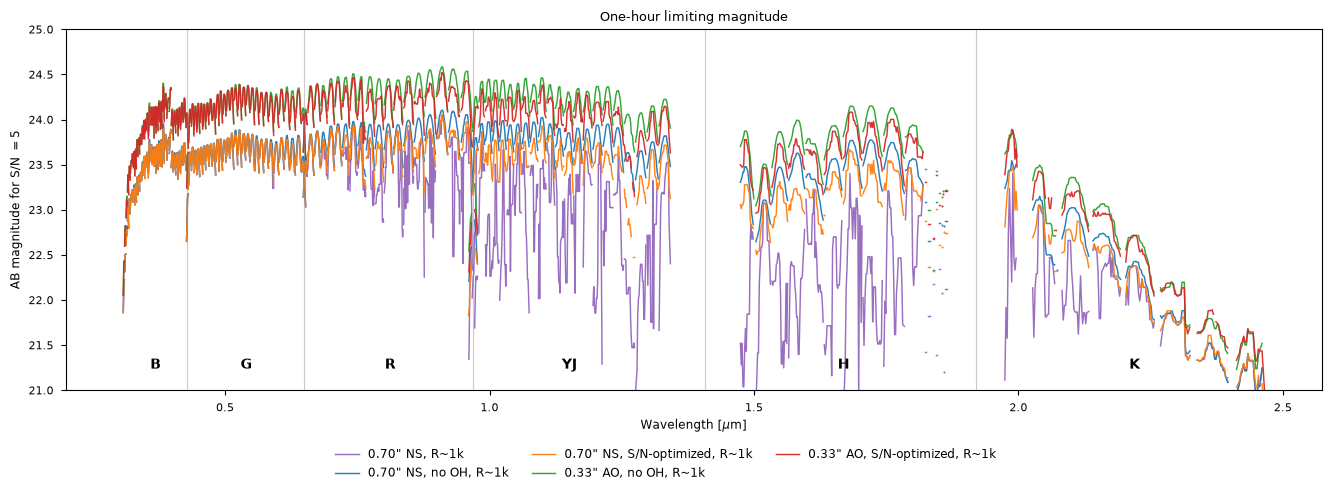

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/selected_ao_natural_comparison.pdf')

In [49]:
# The full-simulation curve uses the signed-off no-OH display rows. Its
# 9-bin median changes plotted magnitudes only and restarts at every order gap.
selected_ao_natural_plot_specs = [
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "simulation",
        "native_element_selection": "all elements",
        "label": '0.70" NS, R~1k',
        "color": colors[4],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
        "presentation_mask_selector": {
            "integration": "1 hour",
            "slit_arcsec": 0.70,
            "ao_enabled": False,
            "bin_factor": 18,
            "sky_model": "no OH",
            "native_element_selection": "all elements",
        },
        "order_rolling_median_bins": 5,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
        "label": '0.70" NS, no OH, R~1k',
        "color": colors[0],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
        "order_rolling_median_bins": 5,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "simulation",
        "native_element_selection": "S/N-selected",
        "label": '0.70" NS, S/N-optimized, R~1k',
        "color": colors[1],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
        "order_rolling_median_bins": 5,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.33,
        "ao_enabled": True,
        "bin_factor": 38,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
        "label": '0.33" AO, no OH, R~1k',
        "color": colors[2],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
        "order_rolling_median_bins": 5,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.33,
        "ao_enabled": True,
        "bin_factor": 38,
        "sky_model": "simulation",
        "native_element_selection": "S/N-selected",
        "label": '0.33" AO, S/N-optimized, R~1k',
        "color": colors[3],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
        "order_rolling_median_bins": 5,
    },
]
fig, ax = plot_limiting_magnitude_curves(limiting_magnitude_curves, selected_ao_natural_plot_specs, title="One-hour limiting magnitude", dynamic_range_mag=PLOT_DYNAMIC_RANGE_MAG, minimum_limiting_magnitude_ab=clip_zp_below, ylim=(21, 25))
display_and_save_figure(fig, "selected_ao_natural_comparison")


## Native-element selection diagnostic

This optional two-panel diagnostic uses the returned native-selection table. It is separate from the principal limiting-magnitude result.


In [50]:
SHOW_NATIVE_SELECTION_DIAGNOSTIC = False
SPECTRAL_SELECTION_DIAGNOSTIC_CHANNEL = "H"
SPECTRAL_SELECTION_DIAGNOSTIC_TRACE_ID = None

if SHOW_NATIVE_SELECTION_DIAGNOSTIC:
    native_selection_frame = natural_native_selection.to_pandas()
    channel_rows = native_selection_frame[native_selection_frame["channel"] == SPECTRAL_SELECTION_DIAGNOSTIC_CHANNEL]
    if SPECTRAL_SELECTION_DIAGNOSTIC_TRACE_ID is None:
        trace_medians = channel_rows.groupby("trace_id", sort=False)["native_wavelength_nm"].median()
        channel_median = np.median(channel_rows["native_wavelength_nm"])
        diagnostic_trace_id = trace_medians.index[np.argmin(np.abs(trace_medians.to_numpy() - channel_median))]
    else:
        diagnostic_trace_id = SPECTRAL_SELECTION_DIAGNOSTIC_TRACE_ID

    fig, axes = plt.subplots(2, 1, figsize=(13.2, 6.3), sharex=True, constrained_layout=True, height_ratios=(3, 1))
    diagnostic_case_specs = (("simulation", "configured sky", 0, 1), ("no OH", "no OH", 1, 0))
    for sky_model, label, color_index, retained_row in diagnostic_case_specs:
        rows = channel_rows[(channel_rows["trace_id"] == diagnostic_trace_id) & (channel_rows["sky_model"] == sky_model)].sort_values("native_wavelength_nm")
        retained = rows["retained_by_snr_selection"].to_numpy(dtype=bool)
        wave_um = rows["native_wavelength_nm"].to_numpy() / 1000
        native_snr = rows["native_snr"].to_numpy()
        axes[0].plot(wave_um, native_snr, color=colors[color_index], linewidth=0.65 * plt.rcParams["lines.linewidth"], label=label)
        axes[0].scatter(wave_um[retained], native_snr[retained], s=11, facecolor="none", edgecolor=colors[color_index], linewidth=0.6 * plt.rcParams["lines.linewidth"])
        axes[1].scatter(wave_um[retained], np.full(np.count_nonzero(retained), retained_row), s=8, color=colors[color_index])
    axes[0].set(ylabel="Native-element S/N", title=(f"{SPECTRAL_SELECTION_DIAGNOSTIC_CHANNEL} {diagnostic_trace_id}: " "native quality and selected elements"))
    axes[0].legend(frameon=False)
    axes[1].set(xlabel=r"Wavelength [$\mu\mathrm{m}$]", ylabel="Retained", yticks=(0, 1), yticklabels=("no OH", "configured sky"), ylim=(-0.5, 1.5))
    display_and_save_figure(fig, "snr_selected_native_diagnostic")
else:
    print("Native-element selection diagnostic disabled.")


Native-element selection diagnostic disabled.


## AO and slit sensitivity (1 hour, no OH lines)

This signed-off broader slit/AO comparison is retained independently of the selected four-curve comparison above.


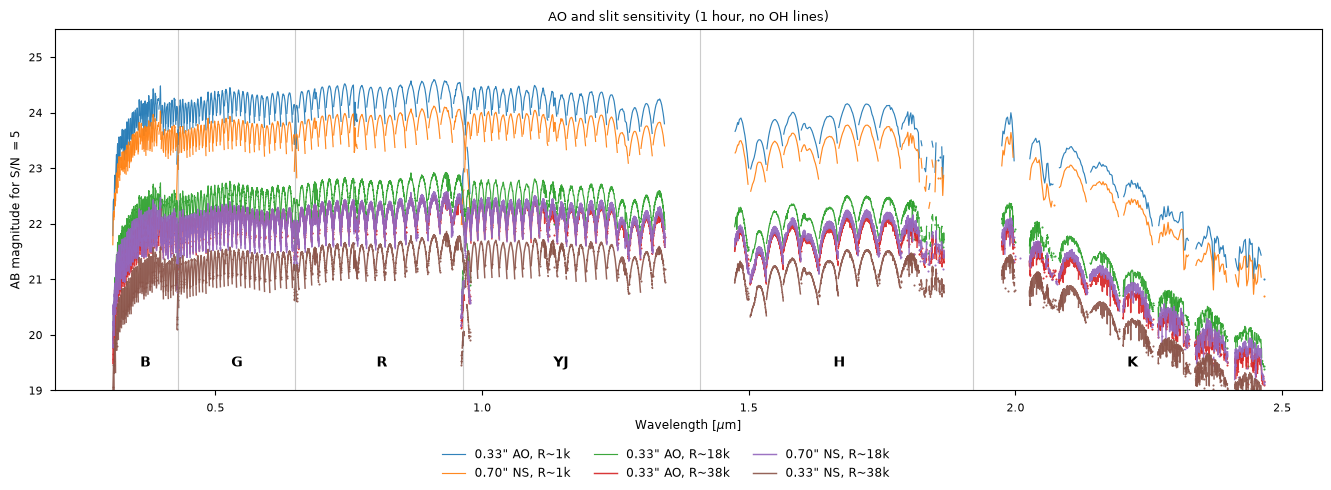

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/ao_slit_sensitivity.pdf')

In [51]:
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
one_hour_plot_specs = [
    {
        "integration": "1 hour",
        "slit_arcsec": 0.33,
        "ao_enabled": True,
        "bin_factor": 38,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
        "label": '0.33" AO, R~1k',
        "color": colors[0],
        "linestyle": "-",
        "linewidth_multiplier": 0.60,
        "alpha": 0.92,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
        "label": '0.70" NS, R~1k',
        "color": colors[1],
        "linestyle": "-",
        "linewidth_multiplier": 0.60,
        "alpha": 0.92,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.33,
        "ao_enabled": True,
        "bin_factor": 2,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
        "label": '0.33" AO, R~18k',
        "color": colors[2],
        "linestyle": "-",
        "linewidth_multiplier": 0.60,
        "alpha": 0.92,
                "order_rolling_median_bins": 5,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.33,
        "ao_enabled": True,
        "bin_factor": 1,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
        "label": '0.33" AO, R~38k',
        "color": colors[3],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
        "alpha": 0.92,
                "order_rolling_median_bins": 5,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 1,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
        "label": '0.70" NS, R~18k',
        "color": colors[4],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
        "alpha": 0.92,
                "order_rolling_median_bins": 5,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.33,
        "ao_enabled": False,
        "bin_factor": 1,
        "sky_model": "no OH",
        "native_element_selection": "all elements",
        "label": '0.33" NS, R~38k',
        "color": colors[5],
        "linestyle": "-",
        "linewidth_multiplier": 0.75,
        "alpha": 0.92,
                "order_rolling_median_bins": 5,
    },
]
fig, ax = plot_limiting_magnitude_curves(limiting_magnitude_curves, one_hour_plot_specs, title="AO and slit sensitivity (1 hour, no OH lines)", dynamic_range_mag=PLOT_DYNAMIC_RANGE_MAG, ylim=(19, 25.5))
display_and_save_figure(fig, "ao_slit_sensitivity")


## Paper limiting-magnitude summary

The first table gives the arm limiting magnitudes for each available sky and extraction case. The second compresses those same values into BGR and YJH means and the signed difference K-YJH; these are summaries of arm limits, not coadded broadband sensitivities. For matched catalog cases, `favorable_quantile = 0.80` means that each curve independently identifies the best-performing 20% of its raw, complete, finite bins within every order. Tables 1 and 2 report the mean limiting magnitude within that curve-specific favorable region followed by the median across orders, with no plot masking or smoothing. Rows without a corresponding catalog calculation remain unavailable.

The selection diagnostic uses a different statistic, labelled *avg. median*: the median raw limiting magnitude within each contiguous order run followed by the median of those order medians across the arm. Its OH-disabled S/N-optimization control is printed separately as an algorithm diagnostic, not an instrument-performance result.


In [52]:
paper_scenario_specs = [
    ("1 hour", 0.70, False, 18, "R~1,000"),
    ("1 hour", 0.33, True, 38, "R~1,000"),
    ("1 hour", 0.70, False, 2, "R~10,000"),
    ("1 hour", 0.33, True, 4, "R~10,000"),
    ("1 hour", 0.70, False, 1, "R~18,000"),
    ("1 hour", 0.33, True, 2, "R~18,000"),
    ("1 hour", 0.33, True, 1, "R~38,000"),
    ("1 hour", 0.33, False, 1, "R~38,000"),
    ("5 minutes", 0.70, False, 18, "R~1,000"),
    ("5 minutes", 0.33, True, 38, "R~1,000"),
    ("5 minutes", 0.70, False, 2, "R~10,000"),
    ("5 minutes", 0.33, True, 4, "R~10,000"),
    ("5 minutes", 0.70, False, 1, "R~18,000"),
    ("5 minutes", 0.33, True, 2, "R~18,000"),
    ("5 minutes", 0.33, True, 1, "R~38,000"),
    ("5 minutes", 0.33, False, 1, "R~38,000"),
]

paper_zero_point_rows = []
for integration, slit, ao_enabled, bin_factor, approximate_R in paper_scenario_specs:
    result = paper_case_results[(integration, slit, ao_enabled)]
    order_best = result["order_best"]
    selected_orders = order_best[order_best["bin_factor"] == bin_factor]
    row = {
        "integration": integration,
        "DITxNDIT": f"{result['dit']}x{result['ndit']}",
        "slit": f'{slit:.2f}"',
        "AO": "AO" if ao_enabled else "Natural",
        "bin": bin_factor,
        "design": approximate_R,
        "R median": np.median(selected_orders["extraction_R"]),
    }
    for channel in readout_titles:
        channel_orders = selected_orders[selected_orders["channel"] == channel]
        if len(channel_orders) == 0:
            raise ValueError(f"No selected {channel} orders for " f"{(integration, slit, ao_enabled, bin_factor)}")
        row[channel] = np.median(channel_orders["m5_ab"])
    paper_zero_point_rows.append(row)

paper_zero_point_table = Table(rows=paper_zero_point_rows)

paper_setup_columns = {
    "integration": paper_zero_point_table["integration"],
    "DIT x NDIT": paper_zero_point_table["DITxNDIT"],
    "slit [\"]": paper_zero_point_table["slit"],
    "mode": np.where(paper_zero_point_table["AO"] == "AO", "AO", "natural seeing"),
    "native bin": paper_zero_point_table["bin"],
    "median R": paper_zero_point_table["R median"],
}
paper_limiting_magnitude_summary = Table(paper_setup_columns)
paper_case_labels = ("OH disabled", "OH included", "OH included, S/N optimized")
paper_case_columns = {case: {channel: f"{channel} {case}" for channel in readout_titles} for case in paper_case_labels}
for channel in readout_titles:
    paper_limiting_magnitude_summary[paper_case_columns["OH disabled"][channel]] = paper_zero_point_table[channel]
    for case in paper_case_labels[1:]:
        paper_limiting_magnitude_summary[paper_case_columns[case][channel]] = np.ma.masked_all(len(paper_zero_point_table), dtype=float)

# Report matching is independent of plot labels and styles.
percentile=.75
paper_selection_report_specs = [
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "favorable_quantile": percentile,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.33,
        "ao_enabled": True,
        "bin_factor": 38,
        "favorable_quantile": percentile,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 2,
        "favorable_quantile": percentile,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.33,
        "ao_enabled": True,
        "bin_factor": 4,
        "favorable_quantile": percentile,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 1,
        "favorable_quantile": percentile,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.33,
        "ao_enabled": True,
        "bin_factor": 2,
        "favorable_quantile": percentile,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.33,
        "ao_enabled": True,
        "bin_factor": 1,
        "favorable_quantile": percentile,
    },
]
selection_diagnostic_specs = [
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.33,
        "ao_enabled": True,
        "bin_factor": 38,
    },
]

# Verify that the catalog reproduces the original paper statistic for every
# no-OH row before adding independently selected simulation cases.
# The original order_best table used samples_selected >= clip_zp_below;
# the new simulation-selected columns below use every raw complete bin.
for row_index, (integration, slit_arcsec, ao_enabled, bin_factor, _approximate_R) in enumerate(paper_scenario_specs):
    curve_setup = (catalog_frame["integration"] == integration) & np.isclose(catalog_frame["slit_arcsec"], slit_arcsec) & (catalog_frame["ao_enabled"] == ao_enabled) & (catalog_frame["bin_factor"] == bin_factor)
    curve_case = (catalog_frame["sky_model"] == "no OH") & (catalog_frame["native_element_selection"] == "all elements")
    curve_valid = catalog_frame["complete_native_bin"] & np.isfinite(catalog_frame["limiting_magnitude_ab"]) & (catalog_frame["limiting_magnitude_ab"] >= clip_zp_below)
    curve = catalog_frame[curve_setup & curve_case & curve_valid]
    order_peaks = curve.groupby(["channel", "trace_id"], sort=False)["limiting_magnitude_ab"].max().reset_index()
    for channel in readout_titles:
        catalog_statistic = np.median(order_peaks.loc[order_peaks["channel"] == channel, "limiting_magnitude_ab",])
        assert np.isclose(catalog_statistic, paper_zero_point_table[channel][row_index], rtol=0, atol=0.005)

selection_diagnostic_rows = []
oh_disabled_control_rows = []
for report_spec in paper_selection_report_specs:
    report_curves = catalog_frame[(catalog_frame["integration"] == report_spec["integration"]) & np.isclose(catalog_frame["slit_arcsec"], report_spec["slit_arcsec"]) & (catalog_frame["ao_enabled"] == report_spec["ao_enabled"]) & (catalog_frame["bin_factor"] == report_spec["bin_factor"]) & catalog_frame["complete_native_bin"]]
    report_row = (paper_limiting_magnitude_summary["integration"] == report_spec["integration"]) & (paper_limiting_magnitude_summary["slit [\"]"] == f'{report_spec["slit_arcsec"]:.2f}"') & (paper_limiting_magnitude_summary["mode"] == ("AO" if report_spec["ao_enabled"] else "natural seeing")) & (paper_limiting_magnitude_summary["native bin"] == report_spec["bin_factor"])
    assert np.count_nonzero(report_row) == 1
    report_row_index = np.flatnonzero(report_row)[0]

    curve_key = [
        "channel", "trace_id", "contiguous_order_run",
        "bin_index_within_run",
    ]
    curves_by_case = {}
    for sky_model, native_selection in (
        ("simulation", "all elements"),
        ("simulation", "S/N-selected"),
        ("no OH", "all elements"),
        ("no OH", "S/N-selected"),
    ):
        curves_by_case[(sky_model, native_selection)] = report_curves[(report_curves["sky_model"] == sky_model) & (report_curves["native_element_selection"] == native_selection)].sort_values(curve_key).reset_index(drop=True)
    reference_keys = curves_by_case[("simulation", "all elements")][curve_key]
    assert all(reference_keys.equals(curve[curve_key]) for curve in curves_by_case.values())
    assert len(reference_keys) > 0

    order_favorable_means_by_case = {case: (curve.loc[np.isfinite(curve["limiting_magnitude_ab"])].groupby(["channel", "trace_id"], sort=False)["limiting_magnitude_ab"].apply(lambda m: m[m >= m.quantile( report_spec["favorable_quantile"])].mean()).reset_index()) for case, curve in curves_by_case.items()}
    finite_limiting_magnitude = np.isfinite(curves_by_case[("simulation", "all elements")]["limiting_magnitude_ab"])

    assert all(np.array_equal(finite_limiting_magnitude, np.isfinite(curve["limiting_magnitude_ab"])) for curve in curves_by_case.values())
    assert all((curve.loc[~finite_limiting_magnitude, "source_signal_e"] == 0).all() for curve in curves_by_case.values())

    curves_by_case = {case: curve.loc[finite_limiting_magnitude].reset_index(drop=True) for case, curve in curves_by_case.items()}

    simulation_all = curves_by_case[("simulation", "all elements")]
    simulation_selected = curves_by_case[("simulation", "S/N-selected")]
    no_oh_all = curves_by_case[("no OH", "all elements")]
    no_oh_selected = curves_by_case[("no OH", "S/N-selected")]
    include_selection_diagnostic = any(report_spec["integration"] == diagnostic_spec["integration"] and np.isclose(report_spec["slit_arcsec"], diagnostic_spec["slit_arcsec"]) and report_spec["ao_enabled"] == diagnostic_spec["ao_enabled"] and report_spec["bin_factor"] == diagnostic_spec["bin_factor"] for diagnostic_spec in selection_diagnostic_specs)
    setup_label = f'{report_spec["slit_arcsec"]:.2f}" ' + ("AO" if report_spec["ao_enabled"] else "natural seeing") + f', bin {report_spec["bin_factor"]}'
    oh_disabled_control = {"setup": setup_label}
    for channel in readout_titles:
        arm_limiting_magnitude = {case: np.median(order_favorable_means.loc[order_favorable_means["channel"] == channel, "limiting_magnitude_ab",]) for case, order_favorable_means in order_favorable_means_by_case.items()}
        n = arm_limiting_magnitude[("no OH", "all elements")]
        a = arm_limiting_magnitude[("simulation", "all elements")]
        s = arm_limiting_magnitude[("simulation", "S/N-selected")]
        for column, value in (
            (paper_case_columns["OH disabled"][channel], n),
            (paper_case_columns["OH included"][channel], a),
            (paper_case_columns["OH included, S/N optimized"][channel], s),
        ):
            paper_limiting_magnitude_summary[column][report_row_index] = value

        if not include_selection_diagnostic:
            continue
        order_key = ["channel", "trace_id", "contiguous_order_run"]
        order_medians_by_case = {case: (curve.groupby(order_key, sort=False)["limiting_magnitude_ab"].median().reset_index()) for case, curve in curves_by_case.items()}
        order_reference = order_medians_by_case[("simulation", "all elements")][order_key]
        assert all(order_reference.equals(order_medians[order_key]) for order_medians in order_medians_by_case.values())
        arm_order_medians = {case: order_medians.loc[order_medians["channel"] == channel, "limiting_magnitude_ab",] for case, order_medians in order_medians_by_case.items()}
        n = np.median(arm_order_medians[("no OH", "all elements")])
        a_median = np.median(arm_order_medians[("simulation", "all elements")])
        s_median = np.median(arm_order_medians[("simulation", "S/N-selected")])
        loss_without_optimization = n - a_median
        residual_loss = n - s_median
        optimization_gain = s_median - a_median
        assert np.isclose(optimization_gain, loss_without_optimization - residual_loss, rtol=0, atol=1e-12)

        retained_columns = ["retained_native_elements", "retained_wavelength_fraction"]
        retained_order_medians = simulation_selected.groupby(order_key, sort=False)[retained_columns].median().reset_index()
        retained_arm = retained_order_medians["channel"] == channel
        selection_diagnostic_rows.append({
            "setup": setup_label,
            "arm": channel,
            "median retained native elements": np.median(retained_order_medians.loc[retained_arm, "retained_native_elements"]),
            "median retained wavelength fraction": np.median(retained_order_medians.loc[retained_arm, "retained_wavelength_fraction"]),
            "avg. median OH loss without optimization [mag]": loss_without_optimization,
            "avg. median residual OH loss [mag]": residual_loss,
            "avg. median S/N optimization gain [mag]": optimization_gain,
        })
        arm = simulation_selected["channel"] == channel
        oh_disabled_control[channel] = np.median(no_oh_selected.loc[arm, "limiting_magnitude_ab"] - no_oh_all.loc[arm, "limiting_magnitude_ab"])
    if include_selection_diagnostic:
        oh_disabled_control_rows.append(oh_disabled_control)

paper_limiting_magnitude_combined_summary = Table(paper_setup_columns)
paper_combined_columns = {case: {quantity: f"{case} {quantity}" for quantity in ("BGR", "YJH", "K-YJH")} for case in paper_case_labels}
for case in paper_case_labels:
    for column in paper_combined_columns[case].values():
        paper_limiting_magnitude_combined_summary[column] = np.ma.masked_all(len(paper_zero_point_table), dtype=float)
    for row_index in range(len(paper_zero_point_table)):
        bgr = [paper_limiting_magnitude_summary[paper_case_columns[case][channel]][row_index] for channel in ("B", "G", "R")]
        yjh = [paper_limiting_magnitude_summary[paper_case_columns[case][channel]][row_index] for channel in ("YJ", "H")]
        k = paper_limiting_magnitude_summary[paper_case_columns[case]["K"]][row_index]
        if any(np.ma.is_masked(value) for value in (*bgr, *yjh, k)):
            continue
        bgr_mean = np.mean(bgr)
        yjh_mean = np.mean(yjh)
        paper_limiting_magnitude_combined_summary[paper_combined_columns[case]["BGR"]][row_index] = bgr_mean
        paper_limiting_magnitude_combined_summary[paper_combined_columns[case]["YJH"]][row_index] = yjh_mean
        paper_limiting_magnitude_combined_summary[paper_combined_columns[case]["K-YJH"]][row_index] = k - yjh_mean

print("For matched catalog cases, Tables 1 and 2 report the median across " "orders of the mean raw limiting magnitude in each curve's own " f"best-performing {100*(1-percentile):.0f}% of complete finite bins (favorable_quantile={percentile:.2f}). " "No plot mask or smoothing is used. A dash means no matched catalog " "calculation is available.")
display_frame(paper_limiting_magnitude_summary,
    formats={
        "median R": "{:.0f}",
        **{column: "{:.2f}" for columns in paper_case_columns.values() for column in columns.values()},
    }
)
print("BGR and YJH are arithmetic means of the displayed arm limits, not " "coadded broadband sensitivities. K-YJH is signed; negative means K " "is shallower.")
display_frame(paper_limiting_magnitude_combined_summary,
    formats={
        "median R": "{:.0f}",
        **{column: "{:.2f}" for columns in paper_combined_columns.values() for column in columns.values()},
    }
)
selection_arm_diagnostic = Table(rows=selection_diagnostic_rows)
print("The selection diagnostic reports the median within each contiguous " "order run followed by the median of those order medians across the arm.")
display_frame(selection_arm_diagnostic,
    formats={
        "median retained native elements": "{:.0f}",
        "median retained wavelength fraction": "{:.2f}",
        "avg. median OH loss without optimization [mag]": "{:+.2f}",
        "avg. median residual OH loss [mag]": "{:+.2f}",
        "avg. median S/N optimization gain [mag]": "{:+.2f}",
    }
)
print("OH-disabled S/N-optimization controls are algorithm diagnostics, not " "instrument performance. They should be near zero; |gain| approaching " "or exceeding 0.10 mag requires investigation.")
for control in oh_disabled_control_rows:
    values = ", ".join(f"{channel}={control[channel]:+.3f}" for channel in readout_titles)
    print(f"{control['setup']}: {values}")


For matched catalog cases, Tables 1 and 2 report the median across orders of the mean raw limiting magnitude in each curve's own best-performing 25% of complete finite bins (favorable_quantile=0.75). No plot mask or smoothing is used. A dash means no matched catalog calculation is available.


integration,DIT x NDIT,"slit [""]",mode,native bin,median R,B OH disabled,B OH included,"B OH included, S/N optimized",G OH disabled,G OH included,"G OH included, S/N optimized",R OH disabled,R OH included,"R OH included, S/N optimized",YJ OH disabled,YJ OH included,"YJ OH included, S/N optimized",H OH disabled,H OH included,"H OH included, S/N optimized",K OH disabled,K OH included,"K OH included, S/N optimized"
1 hour,1800x2,"0.70""",natural seeing,18,987,23.65,23.64,23.64,23.79,23.79,23.79,23.95,23.85,23.88,23.93,23.70,23.80,23.56,23.11,23.31,22.57,22.48,22.51
1 hour,1800x2,"0.33""",AO,38,992,24.11,24.10,24.10,24.31,24.30,24.30,24.47,24.36,24.38,24.36,24.13,24.25,23.93,23.47,23.78,22.89,22.81,22.85
1 hour,1800x2,"0.70""",natural seeing,2,8889,22.43,22.42,22.42,22.58,22.57,22.57,22.73,22.70,22.70,22.73,22.69,22.69,22.36,22.29,22.29,21.40,21.38,21.38
1 hour,1800x2,"0.33""",AO,4,9433,22.84,22.84,22.84,23.05,23.05,23.05,23.21,23.17,23.17,23.11,23.08,23.08,22.70,22.64,22.65,21.69,21.68,21.68
1 hour,1800x2,"0.70""",natural seeing,1,17784,22.06,22.05,22.05,22.21,22.21,22.21,22.36,22.33,22.33,22.36,22.32,22.32,22.01,21.95,21.95,21.04,21.02,21.02
1 hour,1800x2,"0.33""",AO,2,18871,22.44,22.43,22.43,22.66,22.66,22.66,22.81,22.78,22.78,22.72,22.69,22.69,22.31,22.30,22.30,21.32,21.31,21.31
1 hour,1800x2,"0.33""",AO,1,37734,22.01,22.01,22.01,22.25,22.25,22.25,22.40,22.38,22.38,22.32,22.29,22.29,21.92,21.91,21.91,20.94,20.93,20.93
1 hour,1800x2,"0.33""",natural seeing,1,37764,21.52,--,--,21.72,--,--,21.87,--,--,21.90,--,--,21.57,--,--,20.66,--,--
5 minutes,300x1,"0.70""",natural seeing,18,987,22.24,--,--,22.42,--,--,22.57,--,--,22.55,--,--,22.18,--,--,21.25,--,--
5 minutes,300x1,"0.33""",AO,38,991,22.66,--,--,22.91,--,--,23.06,--,--,22.93,--,--,22.55,--,--,21.60,--,--


BGR and YJH are arithmetic means of the displayed arm limits, not coadded broadband sensitivities. K-YJH is signed; negative means K is shallower.


integration,DIT x NDIT,"slit [""]",mode,native bin,median R,OH disabled BGR,OH disabled YJH,OH disabled K-YJH,OH included BGR,OH included YJH,OH included K-YJH,"OH included, S/N optimized BGR","OH included, S/N optimized YJH","OH included, S/N optimized K-YJH"
1 hour,1800x2,"0.70""",natural seeing,18,987,23.79,23.75,-1.17,23.76,23.40,-0.92,23.77,23.56,-1.05
1 hour,1800x2,"0.33""",AO,38,992,24.29,24.14,-1.25,24.25,23.80,-0.99,24.26,24.01,-1.17
1 hour,1800x2,"0.70""",natural seeing,2,8889,22.58,22.55,-1.15,22.57,22.49,-1.11,22.57,22.49,-1.11
1 hour,1800x2,"0.33""",AO,4,9433,23.03,22.91,-1.21,23.02,22.86,-1.18,23.02,22.86,-1.19
1 hour,1800x2,"0.70""",natural seeing,1,17784,22.21,22.18,-1.14,22.20,22.14,-1.11,22.20,22.14,-1.11
1 hour,1800x2,"0.33""",AO,2,18871,22.63,22.52,-1.20,22.63,22.49,-1.19,22.63,22.49,-1.19
1 hour,1800x2,"0.33""",AO,1,37734,22.22,22.12,-1.18,22.21,22.10,-1.17,22.21,22.10,-1.17
1 hour,1800x2,"0.33""",natural seeing,1,37764,21.70,21.74,-1.08,--,--,--,--,--,--
5 minutes,300x1,"0.70""",natural seeing,18,987,22.41,22.36,-1.12,--,--,--,--,--,--
5 minutes,300x1,"0.33""",AO,38,991,22.87,22.74,-1.14,--,--,--,--,--,--


The selection diagnostic reports the median within each contiguous order run followed by the median of those order medians across the arm.


setup,arm,median retained native elements,median retained wavelength fraction,avg. median OH loss without optimization [mag],avg. median residual OH loss [mag],avg. median S/N optimization gain [mag]
"0.70"" natural seeing, bin 18",B,18,1.00,+0.01,+0.01,+0.00
"0.70"" natural seeing, bin 18",G,18,1.00,+0.04,+0.03,+0.01
"0.70"" natural seeing, bin 18",R,18,0.99,+0.27,+0.09,+0.17
"0.70"" natural seeing, bin 18",YJ,15,0.84,+0.96,+0.25,+0.71
"0.70"" natural seeing, bin 18",H,14,0.78,+1.17,+0.28,+0.89
"0.70"" natural seeing, bin 18",K,16,0.87,+0.42,+0.15,+0.27
"0.33"" AO, bin 38",B,38,1.00,+0.01,+0.01,+0.00
"0.33"" AO, bin 38",G,38,1.00,+0.05,+0.03,+0.02
"0.33"" AO, bin 38",R,37,0.98,+0.27,+0.10,+0.17
"0.33"" AO, bin 38",YJ,34,0.90,+0.84,+0.18,+0.66


OH-disabled S/N-optimization controls are algorithm diagnostics, not instrument performance. They should be near zero; |gain| approaching or exceeding 0.10 mag requires investigation.
0.70" natural seeing, bin 18: B=+0.000, G=+0.000, R=+0.000, YJ=+0.000, H=+0.000, K=+0.000
0.33" AO, bin 38: B=+0.000, G=+0.000, R=+0.000, YJ=+0.000, H=+0.000, K=+0.009


In [53]:
from scopesim.effects import SpectralQuantumEfficiency, TaperedQuantumEfficiency

qe_selectors = [effect for effect in zs.optics_manager.all_effects if effect_name(effect) == "detector_qe_selector"]
standard_ccd_selector = [effect for effect in qe_selectors if not effect.include][0]
active_qe_selector = [effect for effect in qe_selectors if effect.include][0]
h2rg_qe = SpectralQuantumEfficiency(filename="detector_specs/H2RG_TER.dat", cmds=zs.cmds)

assert all(not isinstance(effect, TaperedQuantumEfficiency) for detector_id in range(3) for effect in [standard_ccd_selector.wheel_effects[detector_id]])

# User-editable paper assumptions. Dark current is kept in e-/hour/pixel here.
conventional_detector_assumptions = {
    "CCD": {"read_noise_e": 2.5, "dark_current_e_hr_pix": 0.01},
    "H2RG": {"read_noise_e": 6.0, "dark_current_e_hr_pix": 23.0},
}


def qe_at_selected_samples(effect, samples, rows, *, detector_position=False):
    qe = np.empty(np.count_nonzero(rows))
    selected_indices = np.flatnonzero(rows)
    selected_trace_ids = np.asarray(samples["trace_id"][rows], dtype=str)
    selected_bin_factors = np.asarray(samples["bin_factor"][rows], dtype=int)

    for trace_id, bin_factor in sorted(set(zip(selected_trace_ids, selected_bin_factors, strict=True))):
        group = (selected_trace_ids == trace_id) & (selected_bin_factors == bin_factor)
        group_indices = selected_indices[group]
        wavelength_order = np.argsort(np.asarray(samples["wave_nm"][group_indices], dtype=float))
        sorted_indices = group_indices[wavelength_order]
        kwargs = {}
        if detector_position:
            kwargs = {
                "detector_x": np.asarray(samples["detector_x_pix"][sorted_indices], dtype=float),
                "detector_y": np.asarray(samples["detector_y_pix"][sorted_indices], dtype=float),
            }
        group_qe = effect.throughput_at(np.asarray(samples["wave_nm"][sorted_indices], dtype=float) * u.nm, **kwargs)
        qe[np.flatnonzero(group)[wavelength_order]] = group_qe
    return qe


def conventional_detector_samples(result):
    native = result["samples_raw"][result["samples_raw"]["bin_factor"] == 1].copy()
    current_qe = np.empty(len(native))
    conventional_qe = np.empty(len(native))

    for detector_id, channel in enumerate(readout_titles):
        rows = np.asarray(native["channel"], dtype=str) == channel
        current_qe[rows] = qe_at_selected_samples(active_qe_selector.wheel_effects[detector_id], native, rows, detector_position=detector_id < 3)
        conventional_effect = standard_ccd_selector.wheel_effects[detector_id] if detector_id < 3 else h2rg_qe
        conventional_qe[rows] = qe_at_selected_samples(conventional_effect, native, rows)

    qe_ratio = conventional_qe / current_qe
    conventional_signal = np.asarray(native["signal_e"], dtype=float) * qe_ratio
    conventional_sky = np.asarray(native["background_e"], dtype=float) * qe_ratio
    n_pix = np.asarray(native["n_pix"], dtype=float)
    detector_name = np.where(np.isin(np.asarray(native["channel"], dtype=str), ["B", "G", "R"]), "CCD", "H2RG")
    read_noise = np.array([conventional_detector_assumptions[name]["read_noise_e"] for name in detector_name])
    dark_current = np.array([conventional_detector_assumptions[name]["dark_current_e_hr_pix"] / 3600 for name in detector_name])
    conventional_detector_variance = 2 * n_pix * (dark_current * result["dit"] * result["ndit"] + read_noise**2 * result["ndit"])
    conventional_sky_variance = 2 * conventional_sky
    conventional_fixed_variance = conventional_sky_variance + conventional_detector_variance
    conventional_native = native.copy()
    conventional_native["signal_e"] = conventional_signal
    conventional_native["source_var_e"] = conventional_signal
    conventional_native["background_e"] = conventional_sky
    conventional_native["background_var_e"] = conventional_sky_variance
    conventional_native["detector_var_e"] = conventional_detector_variance
    conventional_native["fixed_variance_e"] = conventional_fixed_variance
    bin_factors = sorted(set(result["samples_raw"]["bin_factor"]))
    conventional = aggregate_native_extraction_ledger(conventional_native, bin_factors)
    conventional_lookup = {(str(row["channel"]), str(row["trace_id"]), int(row["bin_factor"]), int(row["native_start_index"])): row for row in conventional}

    samples = result["samples_selected"].copy()
    current_qe_binned, conventional_qe_binned = [], []
    conventional_signal_binned, conventional_sky_var_binned = [], []
    conventional_detector_var_binned, conventional_m5 = [], []
    native_channels = np.asarray(native["channel"], dtype=str)
    native_traces = np.asarray(native["trace_id"], dtype=str)
    qe_cumulative = {}
    for channel in sorted(set(native_channels)):
        for trace_id in sorted(set(native_traces[native_channels == channel]), key=trace_id_sort_key):
            indices = np.flatnonzero((native_channels == channel) & (native_traces == trace_id))
            indices = indices[np.argsort(native["sample_index"][indices])]
            assert np.array_equal(native["sample_index"][indices], np.arange(len(indices)))
            qe_cumulative[(channel, trace_id)] = (np.r_[0.0, np.cumsum(current_qe[indices])], np.r_[0.0, np.cumsum(conventional_qe[indices])])
    for sample in samples:
        key = (str(sample["channel"]), str(sample["trace_id"]), int(sample["bin_factor"]), int(sample["native_start_index"]))
        row = conventional_lookup[key]
        start, stop = int(sample["native_start_index"]), int(sample["native_stop_index"])
        current_cumulative, conventional_cumulative = qe_cumulative[key[:2]]
        current_qe_binned.append((current_cumulative[stop] - current_cumulative[start]) / (stop - start))
        conventional_qe_binned.append((conventional_cumulative[stop] - conventional_cumulative[start]) / (stop - start))
        conventional_signal_binned.append(row["signal_e"])
        conventional_sky_var_binned.append(row["background_var_e"])
        conventional_detector_var_binned.append(row["detector_var_e"])
        conventional_m5.append(row["m5_ab"])

    samples["current_qe"] = current_qe_binned
    samples["conventional_qe"] = conventional_qe_binned
    samples["conventional_signal_e"] = conventional_signal_binned
    samples["conventional_sky_var_e"] = conventional_sky_var_binned
    samples["conventional_detector_var_e"] = conventional_detector_var_binned
    samples["conventional_m5_ab"] = conventional_m5
    samples["conventional_delta_m5"] = conventional_m5 - np.asarray(samples["m5_ab"], dtype=float)
    return samples


for result in paper_case_results.values():
    result["detector_samples"] = conventional_detector_samples(result)

detector_assumption_rows = [{"detector": name, "read noise [e-/read]": values["read_noise_e"], "dark current [e-/hour/pix]": values["dark_current_e_hr_pix"],} for name, values in conventional_detector_assumptions.items()]
print("Conventional B/G/R QE uses the inactive SpectralQuantumEfficiency curves, not tapered QE.")
display_frame(detector_assumption_rows,
    formats={
        "read noise [e-/read]": "{:.1f}",
        "dark current [e-/hour/pix]": "{:.2f}",
    }
)

paired_impact_rows = []
for integration, slit, ao_enabled, bin_factor, approximate_R in paper_scenario_specs:
    samples = paper_case_results[(integration, slit, ao_enabled)]["detector_samples"]
    samples = samples[samples["bin_factor"] == bin_factor].to_pandas()
    for (channel, trace_id), order_rows in samples.groupby(["channel", "trace_id"], sort=False):
        current_peak = order_rows.loc[order_rows["m5_ab"].idxmax()]
        paired_impact_rows.append({
            "integration": integration,
            "slit": slit,
            "AO": ao_enabled,
            "design": approximate_R,
            "detector": "CCD" if channel in {"B", "G", "R"} else "H2RG",
            "channel": channel,
            "trace_id": trace_id,
            "wave_nm": current_peak["wave_nm"],
            "current_m5_ab": current_peak["m5_ab"],
            "conventional_m5_ab": current_peak["conventional_m5_ab"],
            "conventional_minus_current_m5": current_peak["conventional_delta_m5"],
        })

paired_detector_impact_samples = Table(rows=paired_impact_rows)
detector_impact_rows = []
for detector_name in ("CCD", "H2RG"):
    values = np.asarray(paired_detector_impact_samples["conventional_minus_current_m5"][paired_detector_impact_samples["detector"] == detector_name], dtype=float)
    detector_impact_rows.append({
        "detector": detector_name,
        "paired order peaks": len(values),
        "median impact": np.median(values),
        "worst impact": np.min(values),
        "best impact": np.max(values),
    })

print("Impact sign: conventional minus current mAB5, evaluated at each current-detector " "order-peak wavelength.")
display_frame(detector_impact_rows,
    formats={
        "median impact": "{:+.2f}",
        "worst impact": "{:+.2f}",
        "best impact": "{:+.2f}",
    }
)


Conventional B/G/R QE uses the inactive SpectralQuantumEfficiency curves, not tapered QE.


detector,read noise [e-/read],dark current [e-/hour/pix]
CCD,2.5,0.01
H2RG,6.0,23.00


Impact sign: conventional minus current mAB5, evaluated at each current-detector order-peak wavelength.


detector,paired order peaks,median impact,worst impact,best impact
CCD,1341,-0.67,-2.50,-0.11
H2RG,669,-0.51,-2.06,+0.09


In [54]:
from IPython.display import Markdown, display

# Recalculate the conventional-detector version of the existing one-hour,
# 0.70" natural-seeing paired ledger. No new ScopeSim readout is required.
paired_detector_samples = natural_airglow_comparison_samples_raw
native_rows = (paired_detector_samples["bin_factor"] == 1) & (paired_detector_samples["native_count"] == 1)
conventional_paired_samples = paired_detector_samples[native_rows].copy()

channels = np.asarray(conventional_paired_samples["channel"], dtype=str)
current_qe = np.empty(len(conventional_paired_samples))
conventional_qe = np.empty(len(conventional_paired_samples))

for detector_id, channel in enumerate(readout_titles):
    rows = channels == channel
    current_effect = active_qe_selector.wheel_effects[detector_id]
    current_qe[rows] = qe_at_selected_samples(current_effect, conventional_paired_samples, rows, detector_position=detector_id < 3)

    if detector_id < 3:
        conventional_effect = standard_ccd_selector.wheel_effects[detector_id]
    else:
        conventional_effect = h2rg_qe
    conventional_qe[rows] = qe_at_selected_samples(conventional_effect, conventional_paired_samples, rows)

qe_ratio = conventional_qe / current_qe
is_ccd = np.isin(channels, ("B", "G", "R"))
ccd_assumptions = conventional_detector_assumptions["CCD"]
h2rg_assumptions = conventional_detector_assumptions["H2RG"]

read_noise_e = np.where(is_ccd, ccd_assumptions["read_noise_e"], h2rg_assumptions["read_noise_e"])
dark_current_e_s_pix = np.where(is_ccd, ccd_assumptions["dark_current_e_hr_pix"] / 3600, h2rg_assumptions["dark_current_e_hr_pix"] / 3600)

dit_s = 1800
ndit = 2
exposure_time_s = dit_s * ndit
n_pix = np.asarray(conventional_paired_samples["n_pix"], dtype=float)
conventional_detector_variance_e2 = 2 * n_pix * (dark_current_e_s_pix * exposure_time_s + read_noise_e**2 * ndit)

for prefix in ("", "simulation_"):
    source_signal_e = np.asarray(conventional_paired_samples[f"{prefix}signal_e"], dtype=float) * qe_ratio
    sky_e = np.asarray(conventional_paired_samples[f"{prefix}background_e"], dtype=float) * qe_ratio
    source_shot_variance_e2 = source_signal_e
    sky_variance_e2 = 2 * sky_e
    non_source_variance_e2 = sky_variance_e2 + conventional_detector_variance_e2

    conventional_paired_samples[f"{prefix}signal_e"] = source_signal_e
    conventional_paired_samples[f"{prefix}source_var_e"] = source_shot_variance_e2
    conventional_paired_samples[f"{prefix}background_e"] = sky_e
    conventional_paired_samples[f"{prefix}background_var_e"] = sky_variance_e2
    conventional_paired_samples[f"{prefix}detector_var_e"] = conventional_detector_variance_e2
    conventional_paired_samples[f"{prefix}fixed_variance_e"] = non_source_variance_e2

    m5_column = "m5_ab" if prefix == "" else "simulation_m5_ab"
    conventional_paired_samples[m5_column] = [limiting_abmag_for_target_snr(input_abmag, signal, source_variance, fixed_variance) for input_abmag, signal, source_variance, fixed_variance in zip(conventional_paired_samples["input_abmag"], source_signal_e, source_shot_variance_e2, non_source_variance_e2, strict=True)]

conventional_paired_samples["snr_at_input"] = conventional_paired_samples["signal_e"] / np.sqrt(conventional_paired_samples["source_var_e"] + conventional_paired_samples["fixed_variance_e"])
conventional_paired_samples["airglow_background_delta_m5"] = conventional_paired_samples["m5_ab"] - conventional_paired_samples["simulation_m5_ab"]

conventional_natural_curves, conventional_natural_selection = snr_selected_spectral_bins(conventional_paired_samples, bin_factors=(18,), integration="1 hour", slit_arcsec=0.70, ao_enabled=False)

current_detector_curve = natural_curves[(natural_curves["bin_factor"] == 18) & (natural_curves["sky_model"] == "simulation") & (natural_curves["native_element_selection"] == "S/N-selected")].to_pandas()
conventional_detector_curve = conventional_natural_curves[(conventional_natural_curves["bin_factor"] == 18) & (conventional_natural_curves["sky_model"] == "simulation") & (conventional_natural_curves["native_element_selection"] == "S/N-selected")].to_pandas()

matched_bin_keys = [
    "channel", "trace_id", "contiguous_order_run", "bin_index_within_run",
]
matched_detector_bins = current_detector_curve.merge(conventional_detector_curve, on=matched_bin_keys, suffixes=("_current", "_conventional"), validate="one_to_one")
matched_detector_bins = matched_detector_bins[matched_detector_bins["complete_native_bin_current"] & matched_detector_bins["complete_native_bin_conventional"]]
matched_detector_bins["conventional minus current m5 [mag]"] = matched_detector_bins["limiting_magnitude_ab_conventional"] - matched_detector_bins["limiting_magnitude_ab_current"]

current_native_frame = paired_detector_samples[native_rows].to_pandas()
conventional_native_frame = conventional_paired_samples.to_pandas()

no_oh_detector_impacts = {}
for integration in ("1 hour", "5 minutes"):
    samples = paper_case_results[(integration, 0.70, False)]["detector_samples"]
    samples = samples[samples["bin_factor"] == 18].to_pandas()
    no_oh_detector_impacts[integration] = samples

detector_sensitivity_rows = []
detector_exposure_rows = []
for channel in readout_titles:
    current_bins = current_detector_curve[(current_detector_curve["channel"] == channel) & current_detector_curve["complete_native_bin"]]
    conventional_bins = conventional_detector_curve[(conventional_detector_curve["channel"] == channel) & conventional_detector_curve["complete_native_bin"]]
    matched_bins = matched_detector_bins[matched_detector_bins["channel"] == channel]
    current_native = current_native_frame[current_native_frame["channel"] == channel]
    conventional_native = conventional_native_frame[conventional_native_frame["channel"] == channel]

    current_variance_e2_pix = np.median(current_native["simulation_detector_var_e"] / current_native["n_pix"])
    conventional_variance_e2_pix = np.median(conventional_native["simulation_detector_var_e"] / conventional_native["n_pix"])
    detector_name = "CCD" if channel in {"B", "G", "R"} else "H2RG"
    detector_pair = "qCCD -> CCD" if detector_name == "CCD" else "LMAPD -> H2RG"

    detector_sensitivity_rows.append({
        "arm": channel,
        "detector pair": detector_pair,
        "median conventional/current QE": np.median(qe_ratio[channels == channel]),
        "current detector variance [e2/pix]": current_variance_e2_pix,
        "conventional detector variance [e2/pix]": conventional_variance_e2_pix,
        "median retained detector pixels/bin": np.median(conventional_bins["detector_variance_e2"] / conventional_variance_e2_pix),
        "conventional sky variance [e2/bin]": np.median(conventional_bins["sky_variance_e2"]),
        "conventional detector variance [e2/bin]": np.median(conventional_bins["detector_variance_e2"]),
        "detector fraction of non-source variance": np.median(conventional_bins["detector_variance_e2"] / conventional_bins["non_source_variance_e2"]),
        "median conventional-current m5 [mag]": np.median(matched_bins["conventional minus current m5 [mag]"]),
    })

    one_hour = no_oh_detector_impacts["1 hour"]
    five_minutes = no_oh_detector_impacts["5 minutes"]
    detector_exposure_rows.append({
        "arm": channel,
        "detector pair": detector_pair,
        "1 hour OH-disabled median delta m5 [mag]": np.median(one_hour.loc[one_hour["channel"] == channel, "conventional_delta_m5"]),
        "5 minute OH-disabled median delta m5 [mag]": np.median(five_minutes.loc[five_minutes["channel"] == channel, "conventional_delta_m5"]),
    })

display(Markdown(r"""
### Conventional-detector sensitivity regime

This diagnostic uses the one-hour, 0.70" natural-seeing, approximately
$R=1000$ calculation with OH included and each detector system independently
S/N optimized. Values are medians across raw, complete, matched output bins;
no presentation mask or smoothing enters the table.

A one-hour result means one hour on source plus a separate one-hour matched
background exposure. Source shot noise enters once. Sky and detector variance
enter twice. The matched detector term per extracted pixel is

$$
\sigma_{\mathrm{det,pair}}^2 =
2\left(i_{\mathrm{dark}}\,\mathrm{DIT}\,\mathrm{NDIT}
+ \mathrm{RN}^2\,\mathrm{NDIT}\right).
$$

For the adopted H2RG assumptions this is
$2(23 + 6^2\times2)=190\ \mathrm{e^2/pix}$: 46 $\mathrm{e^2/pix}$ from
two total hours of dark current and 144 $\mathrm{e^2/pix}$ from four total
readouts. The variance is multiplied by every retained physical extraction
pixel; no NIR on-chip binning is assumed.

The sign convention is
$\Delta m_5=m_5(\mathrm{CCD/H2RG})-m_5(\mathrm{qCCD/LMAPD})$.
Negative values mean the conventional detector is shallower. The second table
uses the existing OH-disabled, all-element products to expose the integration
time dependence; it is a detector diagnostic, not the OH-included optimized
science curve.
"""))

display_frame(detector_sensitivity_rows,
    formats={
        "median conventional/current QE": "{:.3f}",
        "current detector variance [e2/pix]": "{:.2f}",
        "conventional detector variance [e2/pix]": "{:.2f}",
        "median retained detector pixels/bin": "{:.0f}",
        "conventional sky variance [e2/bin]": "{:,.0f}",
        "conventional detector variance [e2/bin]": "{:,.0f}",
        "detector fraction of non-source variance": "{:.1%}",
        "median conventional-current m5 [mag]": "{:+.3f}",
    }
)

display(Markdown("**Exposure-time check:** matched OH-disabled, all-element R~1000 bins."))
display_frame(detector_exposure_rows,
    formats={
        "1 hour OH-disabled median delta m5 [mag]": "{:+.3f}",
        "5 minute OH-disabled median delta m5 [mag]": "{:+.3f}",
    }
)


### Conventional-detector sensitivity regime

This diagnostic uses the one-hour, 0.70" natural-seeing, approximately
$R=1000$ calculation with OH included and each detector system independently
S/N optimized. Values are medians across raw, complete, matched output bins;
no presentation mask or smoothing enters the table.

A one-hour result means one hour on source plus a separate one-hour matched
background exposure. Source shot noise enters once. Sky and detector variance
enter twice. The matched detector term per extracted pixel is

$$
\sigma_{\mathrm{det,pair}}^2 =
2\left(i_{\mathrm{dark}}\,\mathrm{DIT}\,\mathrm{NDIT}
+ \mathrm{RN}^2\,\mathrm{NDIT}\right).
$$

For the adopted H2RG assumptions this is
$2(23 + 6^2\times2)=190\ \mathrm{e^2/pix}$: 46 $\mathrm{e^2/pix}$ from
two total hours of dark current and 144 $\mathrm{e^2/pix}$ from four total
readouts. The variance is multiplied by every retained physical extraction
pixel; no NIR on-chip binning is assumed.

The sign convention is
$\Delta m_5=m_5(\mathrm{CCD/H2RG})-m_5(\mathrm{qCCD/LMAPD})$.
Negative values mean the conventional detector is shallower. The second table
uses the existing OH-disabled, all-element products to expose the integration
time dependence; it is a detector diagnostic, not the OH-included optimized
science curve.


arm,detector pair,median conventional/current QE,current detector variance [e2/pix],conventional detector variance [e2/pix],median retained detector pixels/bin,conventional sky variance [e2/bin],conventional detector variance [e2/bin],detector fraction of non-source variance,median conventional-current m5 [mag]
B,qCCD -> CCD,0.611,1.24,25.02,560,"9,220","14,011",59.7%,-0.757
G,qCCD -> CCD,0.949,1.24,25.02,480,"36,684","12,010",25.0%,-0.177
R,qCCD -> CCD,0.956,1.24,25.02,450,"31,524","11,259",25.6%,-0.191
YJ,LMAPD -> H2RG,1.200,1.72,190.00,360,"58,386","68,400",54.1%,-0.346
H,LMAPD -> H2RG,1.200,1.72,190.00,300,"92,612","57,000",38.5%,-0.164
K,LMAPD -> H2RG,1.200,1.72,190.00,304,"862,198","57,760",7.2%,+0.057


**Exposure-time check:** matched OH-disabled, all-element R~1000 bins.

arm,detector pair,1 hour OH-disabled median delta m5 [mag],5 minute OH-disabled median delta m5 [mag]
B,qCCD -> CCD,-0.767,-1.484
G,qCCD -> CCD,-0.179,-0.608
R,qCCD -> CCD,-0.201,-0.660
YJ,LMAPD -> H2RG,-0.385,-0.977
H,LMAPD -> H2RG,-0.183,-0.670
K,LMAPD -> H2RG,+0.056,-0.081


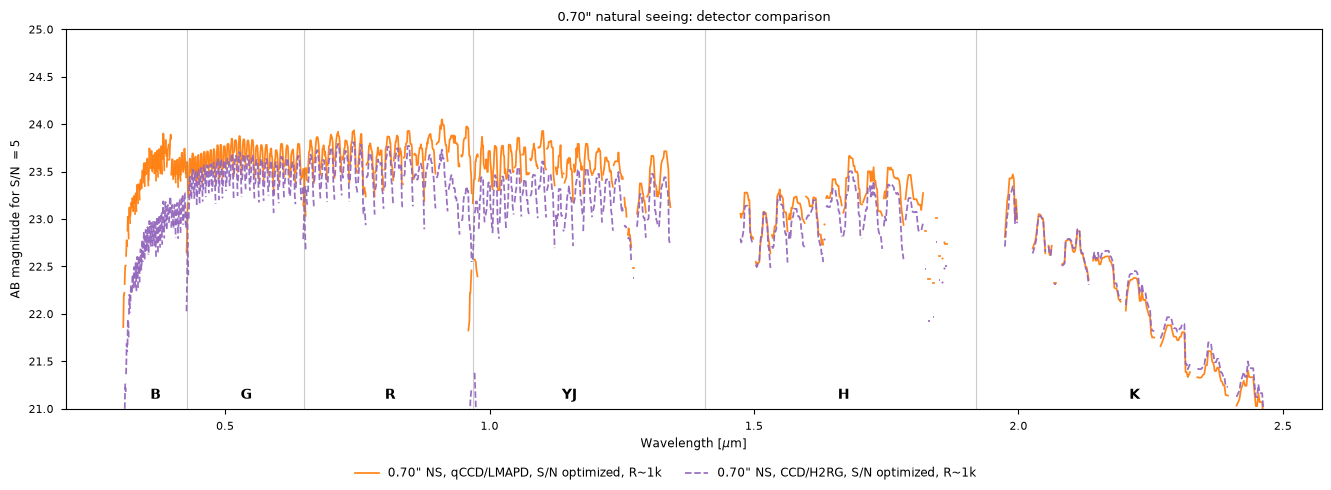

Raw matched-bin limiting-magnitude difference; negative means CCD/H2RG is shallower:


,median,p16,p84,minimum,maximum
channel,,,,,
B,-0.769,-0.974,-0.548,-1.716,-0.437
G,-0.181,-0.259,-0.149,-1.360,-0.114
R,-0.198,-0.502,-0.127,-3.032,-0.077
YJ,-0.351,-0.567,-0.226,-2.276,+0.050
H,-0.167,-0.314,-0.069,-0.633,+0.027
K,+0.057,-0.025,+0.092,-0.221,+0.096


Native-element selection comparison:


,native_elements,changed_elements,current_retained_fraction,conventional_retained_fraction
channel,,,,
B,6046,0,1.000,1.000
G,7734,10,0.995,0.997
R,7661,99,0.931,0.941
YJ,6266,278,0.808,0.842
H,4288,128,0.723,0.731
K,3669,30,0.834,0.841


Conventional/current detector QE ratio at the native samples:


,median,minimum,maximum
channel,,,
B,0.611,0.547,0.655
G,0.949,0.926,0.974
R,0.956,0.251,0.995
YJ,1.200,1.200,1.200
H,1.200,1.200,1.200
K,1.200,1.200,1.200


In [55]:
from astropy.table import vstack
import pandas as pd


# Select the two OH-included, independently S/N-optimized R~1000 curves.
current_curve = natural_curves[(natural_curves["bin_factor"] == 18) & (natural_curves["sky_model"] == "simulation") & (natural_curves["native_element_selection"] == "S/N-selected")].copy()

conventional_curve = conventional_natural_curves[(conventional_natural_curves["bin_factor"] == 18) & (conventional_natural_curves["sky_model"] == "simulation") & (conventional_natural_curves["native_element_selection"] == "S/N-selected")].copy()

# Short plot-only tags fit the existing fixed-width Astropy string column.
current_curve["sky_model"] = "qCCD"
conventional_curve["sky_model"] = "CCD-H2RG"

detector_comparison_curves = vstack([current_curve, conventional_curve], metadata_conflicts="silent")

detector_comparison_specs = [
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "qCCD",
        "native_element_selection": "S/N-selected",
        "label": '0.70" NS, qCCD/LMAPD, S/N optimized, R~1k',
        "color": colors[1],
        "linestyle": "-",
        "linewidth_multiplier": 0.9,
        "order_rolling_median_bins": 5,
    },
    {
        "integration": "1 hour",
        "slit_arcsec": 0.70,
        "ao_enabled": False,
        "bin_factor": 18,
        "sky_model": "CCD-H2RG",
        "native_element_selection": "S/N-selected",
        "label": '0.70" NS, CCD/H2RG, S/N optimized, R~1k',
        "color": colors[4],
        "linestyle": "--",
        "linewidth_multiplier": 0.9,
        "order_rolling_median_bins": 5,
    },
]

current_detector_selector = {
    "integration": "1 hour",
    "slit_arcsec": 0.70,
    "ao_enabled": False,
    "bin_factor": 18,
    "sky_model": "qCCD",
    "native_element_selection": "S/N-selected",
}

fig, ax = plot_limiting_magnitude_curves(detector_comparison_curves, detector_comparison_specs, title='0.70" natural seeing: detector comparison', shared_presentation_mask_selector=current_detector_selector, dynamic_range_mag=PLOT_DYNAMIC_RANGE_MAG, minimum_limiting_magnitude_ab=clip_zp_below, ylim=(21, 25))
display_and_save_figure(fig, "conventional_vs_current_detector_natural_r1000")


# Raw matched-bin magnitude differences, before display masks or smoothing.
row_keys = [
    "channel",
    "trace_id",
    "contiguous_order_run",
    "bin_index_within_run",
]

current_raw = current_curve.to_pandas()
conventional_raw = conventional_curve.to_pandas()

matched_bins = current_raw.merge(conventional_raw, on=row_keys, suffixes=("_current", "_conventional"), validate="one_to_one")
matched_bins["CCD/H2RG minus qCCD/LMAPD [mag]"] = matched_bins["limiting_magnitude_ab_conventional"] - matched_bins["limiting_magnitude_ab_current"]

magnitude_difference_summary = matched_bins.groupby("channel", sort=False)["CCD/H2RG minus qCCD/LMAPD [mag]"].agg(median="median", p16=lambda values: values.quantile(0.16), p84=lambda values: values.quantile(0.84), minimum="min", maximum="max").reindex(readout_titles)

print("Raw matched-bin limiting-magnitude difference; negative means CCD/H2RG is shallower:")
display(magnitude_difference_summary.style.format("{:+.3f}"))


# Verify that the conventional detector calculation produced a new S/N mask.
current_native = natural_native_selection[(natural_native_selection["bin_factor"] == 18) & (natural_native_selection["sky_model"] == "simulation")].to_pandas()

conventional_native = conventional_natural_selection[(conventional_natural_selection["bin_factor"] == 18) & (conventional_natural_selection["sky_model"] == "simulation")].to_pandas()

native_keys = row_keys + ["native_sample_index"]

mask_comparison = current_native[native_keys + ["retained_by_snr_selection"]].merge(conventional_native[native_keys + ["retained_by_snr_selection"]], on=native_keys, suffixes=("_current", "_conventional"), validate="one_to_one")

mask_comparison["mask changed"] = mask_comparison["retained_by_snr_selection_current"] != mask_comparison["retained_by_snr_selection_conventional"]

selection_mask_summary = mask_comparison.groupby("channel", sort=False).agg(native_elements=("mask changed", "size"), changed_elements=("mask changed", "sum"), current_retained_fraction=("retained_by_snr_selection_current", "mean"), conventional_retained_fraction=("retained_by_snr_selection_conventional", "mean")).reindex(readout_titles)

print("Native-element selection comparison:")
display(selection_mask_summary.style.format({
    "current_retained_fraction": "{:.3f}",
    "conventional_retained_fraction": "{:.3f}",
}))


# Confirm that the conventional/current QE transformation was nontrivial.
qe_frame = pd.DataFrame({"channel": channels, "conventional/current QE": qe_ratio})
qe_summary = qe_frame.groupby("channel", sort=False)["conventional/current QE"].agg(median="median", minimum="min", maximum="max").reindex(readout_titles)

print("Conventional/current detector QE ratio at the native samples:")
display(qe_summary.style.format("{:.3f}"))

In [56]:
SKY_EQUALITY_SLIT_ARCSEC = 0.33
SKY_EQUALITY_BIN_FACTORS = (1, 18,  40)
SKY_EQUALITY_AO_STATES = (False, True)
SKY_EQUALITY_REFERENCE_TIMES_S = (10, 300, 3600)
SKY_EQUALITY_VISIBLE_CHECK = ("B", 370.0)
SKY_EQUALITY_INFRARED_CHECK = ("H", 1650.0)
SKY_EQUALITY_MAX_CCD_BIN = 5

equality_budget_by_channel = {str(row["channel"]): row for row in ao_detector_budget_1h}
sky_equality_rows = []
ccd_binning_rows = []
for ao_enabled in SKY_EQUALITY_AO_STATES:
    seeing = "AO" if ao_enabled else "Natural"
    case = paper_case_results[("1 hour", SKY_EQUALITY_SLIT_ARCSEC, ao_enabled)]
    if ao_enabled:
        background_ledger = ao_airglow_comparison_samples_raw[np.isin(ao_airglow_comparison_samples_raw["bin_factor"], SKY_EQUALITY_BIN_FACTORS)].copy()
        background_ledger["background_e"] = background_ledger["simulation_background_e"]
    else:
        background_ledger = background_samples_table(case["samples_raw"], ao_simulation_background_1h, ao_detector_budget_1h, readout_titles, SKY_EQUALITY_BIN_FACTORS)
    background_ledger = background_ledger[background_ledger["native_count"] == background_ledger["bin_factor"]]
    native_background = background_ledger[background_ledger["bin_factor"] == 1]
    native_channels = np.asarray(native_background["channel"], dtype=str)
    current_qe = np.empty(len(native_background))
    conventional_qe = np.empty(len(native_background))
    ccd_bins = {}

    for detector_id, channel in enumerate(readout_titles):
        channel_rows = native_channels == channel
        current_qe[channel_rows] = qe_at_selected_samples(active_qe_selector.wheel_effects[detector_id], native_background, channel_rows, detector_position=detector_id < 3)
        conventional_effect = standard_ccd_selector.wheel_effects[detector_id] if detector_id < 3 else h2rg_qe
        conventional_qe[channel_rows] = qe_at_selected_samples(conventional_effect, native_background, channel_rows)
        if channel in {"B", "G", "R"}:
            channel_native = native_background[channel_rows]
            min_nx = int(np.min(channel_native["spectral_width_pix"]))
            min_ny = int(np.min(channel_native["spatial_width_pix"]))
            ccd_bins[channel] = (max(1, min(SKY_EQUALITY_MAX_CCD_BIN, min_nx // 2)), max(1, min(SKY_EQUALITY_MAX_CCD_BIN, min_ny // 2)))

    conventional_sky_e = np.asarray(native_background["background_e"], dtype=float) * conventional_qe / current_qe
    native_traces = np.asarray(native_background["trace_id"], dtype=str)
    native_cumulative = {}
    for channel in sorted(set(native_channels)):
        for trace_id in sorted(set(native_traces[native_channels == channel]), key=trace_id_sort_key):
            indices = np.flatnonzero((native_channels == channel) & (native_traces == trace_id))
            indices = indices[np.argsort(native_background["sample_index"][indices])]
            assert np.array_equal(native_background["sample_index"][indices], np.arange(len(indices)))
            if channel in {"B", "G", "R"}:
                bin_x, bin_y = ccd_bins[channel]
                conventional_reads = np.ceil(native_background["spectral_width_pix"][indices] / bin_x) * np.ceil(native_background["spatial_width_pix"][indices] / bin_y)
            else:
                conventional_reads = native_background["n_pix"][indices]
            native_cumulative[(channel, trace_id)] = (np.r_[0.0, np.cumsum(conventional_sky_e[indices])], np.r_[0.0, np.cumsum(conventional_reads)])
    for bin_factor in SKY_EQUALITY_BIN_FACTORS:
        samples = background_ledger[background_ledger["bin_factor"] == bin_factor]
        for sample in samples:
            channel = str(sample["channel"])
            budget = equality_budget_by_channel[channel]
            start, stop = int(sample["native_start_index"]), int(sample["native_stop_index"])
            conventional_sky_cumulative, conventional_read_cumulative = native_cumulative[(channel, str(sample["trace_id"]))]
            assert stop - start == int(sample["native_count"])
            n_x = int(sample["spectral_width_pix"])
            n_y = int(sample["spatial_width_pix"])
            n_phys = int(sample["n_pix"])
            full_sky_rate = float(sample["background_e"]) / float(budget["exposure_time_s"])
            current_dark_rate = n_phys * float(budget["dark_current_e_s_pix"])
            current_read_noise = float(budget["read_noise_e_rms"]) / np.sqrt(float(budget["ndit"]))
            current_n_read = n_phys
            current_read_variance = current_n_read * current_read_noise**2
            current_rate_difference = full_sky_rate - current_dark_rate
            current_time = current_read_variance / current_rate_difference if current_rate_difference > 0 else np.nan

            conventional_name = "CCD" if channel in {"B", "G", "R"} else "H2RG"
            conventional_assumptions = conventional_detector_assumptions[conventional_name]
            conventional_sky_rate = (conventional_sky_cumulative[stop] - conventional_sky_cumulative[start]) / float(budget["exposure_time_s"])
            conventional_dark_rate = n_phys * conventional_assumptions["dark_current_e_hr_pix"] / 3600
            if conventional_name == "CCD":
                bin_x, bin_y = ccd_bins[channel]
                conventional_n_read = int(conventional_read_cumulative[stop] - conventional_read_cumulative[start])
            else:
                bin_x, bin_y = 1, 1
                conventional_n_read = n_phys
            conventional_read_variance = conventional_n_read * conventional_assumptions["read_noise_e"]**2
            conventional_rate_difference = conventional_sky_rate - conventional_dark_rate
            conventional_time = conventional_read_variance / conventional_rate_difference if conventional_rate_difference > 0 else np.nan

            sky_equality_rows.append({
                "seeing": seeing, "ao_enabled": ao_enabled, "bin_factor": bin_factor,
                "channel": channel, "trace_id": str(sample["trace_id"]),
                "sample_index": int(sample["sample_index"]), "bin_index": int(sample["bin_index"]),
                "wave_nm": float(sample["wave_nm"]), "n_x_phys": n_x,
                "n_y_phys": n_y, "n_phys": n_phys,
                "current_detector": "qCCD" if channel in {"B", "G", "R"} else "LMAPD",
                "current_n_read": current_n_read, "current_read_variance_e2": current_read_variance,
                "current_dark_rate_e_s": current_dark_rate, "current_full_sky_rate_e_s": full_sky_rate,
                "current_t_equal_s": current_time, "conventional_detector": conventional_name,
                "ccd_bin_x": bin_x, "ccd_bin_y": bin_y, "conventional_n_read": conventional_n_read,
                "conventional_read_variance_e2": conventional_read_variance,
                "conventional_dark_rate_e_s": conventional_dark_rate,
                "conventional_full_sky_rate_e_s": conventional_sky_rate,
                "conventional_t_equal_s": conventional_time,
            })

    for bin_factor in SKY_EQUALITY_BIN_FACTORS:
        for channel in ("B", "G", "R"):
            channel_native = native_background[native_channels == channel]
            bin_x, bin_y = ccd_bins[channel]
            ccd_binning_rows.append({
                "seeing": seeing, "bin factor": bin_factor, "channel": channel,
                "minimum physical Nx": int(np.min(channel_native["spectral_width_pix"])),
                "minimum physical Ny": int(np.min(channel_native["spatial_width_pix"])),
                "CCD bin x": bin_x, "CCD bin y": bin_y,
            })

sky_equality_samples = Table(rows=sky_equality_rows)
ccd_binning_summary = Table(rows=ccd_binning_rows)
display_frame(ccd_binning_summary)

sky_equality_table_rows = sky_equality_samples.to_pandas()
representative_rows = []
for channel, target_wave_nm in (SKY_EQUALITY_VISIBLE_CHECK, SKY_EQUALITY_INFRARED_CHECK):
    candidates = sky_equality_table_rows[(sky_equality_table_rows["seeing"] == "Natural") & (sky_equality_table_rows["bin_factor"] == 1) & (sky_equality_table_rows["channel"] == channel)]
    row = candidates.iloc[int(np.argmin(np.abs(candidates["wave_nm"] - target_wave_nm)))]
    representative_rows.append({
        "channel": channel,
        "wavelength [nm]": row["wave_nm"],
        "physical pixels": int(row["n_phys"]),
        "current read samples": int(row["current_n_read"]),
        "conventional read samples": int(row["conventional_n_read"]),
        "current read variance [e2]": row["current_read_variance_e2"],
        "current sky rate [e-/s]": row["current_full_sky_rate_e_s"],
        "current dark rate [e-/s]": row["current_dark_rate_e_s"],
        "current equality [s]": row["current_t_equal_s"],
        "conventional read variance [e2]": row["conventional_read_variance_e2"],
        "conventional sky rate [e-/s]": row["conventional_full_sky_rate_e_s"],
        "conventional dark rate [e-/s]": row["conventional_dark_rate_e_s"],
        "conventional equality [s]": row["conventional_t_equal_s"],
    })
display_frame(representative_rows,
    formats={
        "wavelength [nm]": "{:.1f}",
        "current read variance [e2]": "{:.3g}",
        "current sky rate [e-/s]": "{:.3g}",
        "current dark rate [e-/s]": "{:.3g}",
        "current equality [s]": "{:.3g}",
        "conventional read variance [e2]": "{:.3g}",
        "conventional sky rate [e-/s]": "{:.3g}",
        "conventional dark rate [e-/s]": "{:.3g}",
        "conventional equality [s]": "{:.3g}",
    }
)


seeing,bin factor,channel,minimum physical Nx,minimum physical Ny,CCD bin x,CCD bin y
Natural,1,B,2,6,1,3
Natural,1,G,2,6,1,3
Natural,1,R,2,5,1,2
Natural,18,B,2,6,1,3
Natural,18,G,2,6,1,3
Natural,18,R,2,5,1,2
Natural,40,B,2,6,1,3
Natural,40,G,2,6,1,3
Natural,40,R,2,5,1,2
AO,1,B,2,4,1,2


channel,wavelength [nm],physical pixels,current read samples,conventional read samples,current read variance [e2],current sky rate [e-/s],current dark rate [e-/s],current equality [s],conventional read variance [e2],conventional sky rate [e-/s],conventional dark rate [e-/s],conventional equality [s]
B,370.0,14,14,6,0.14,0.0246,0.00232,6.28,37.5,0.0137,3.89e-05,2.75e+03
H,1650.0,10,10,10,2.5,0.246,0.001,10.2,360,0.295,0.0639,1.56e+03


SKY_EQUALITY per-order median diagnostics (current/conventional; spans are 16th-84th percentiles in log10 seconds):
  Natural, 1x: 127 order runs; 255/613 finite runs; within-order 0.33/0.31 -> 0.00/0.00 dex; order medians 1.27/1.32 dex; 0 same-channel overlapping-order pairs.
  Natural, 18x: 127 order runs; 128/153 finite runs; within-order 0.41/0.31 -> 0.00/0.00 dex; order medians 1.16/1.18 dex; 0 same-channel overlapping-order pairs.
  Natural, 40x: 127 order runs; 127/134 finite runs; within-order 0.36/0.28 -> 0.00/0.00 dex; order medians 1.02/0.97 dex; 0 same-channel overlapping-order pairs.
  AO, 1x: 127 order runs; 257/613 finite runs; within-order 0.33/0.32 -> 0.00/0.00 dex; order medians 1.27/1.02 dex; 0 same-channel overlapping-order pairs.
  AO, 18x: 127 order runs; 128/153 finite runs; within-order 0.41/0.31 -> 0.00/0.00 dex; order medians 1.16/0.97 dex; 0 same-channel overlapping-order pairs.
  AO, 40x: 127 order runs; 127/134 finite runs; within-order 0.36/0.28 -> 0.00/0.

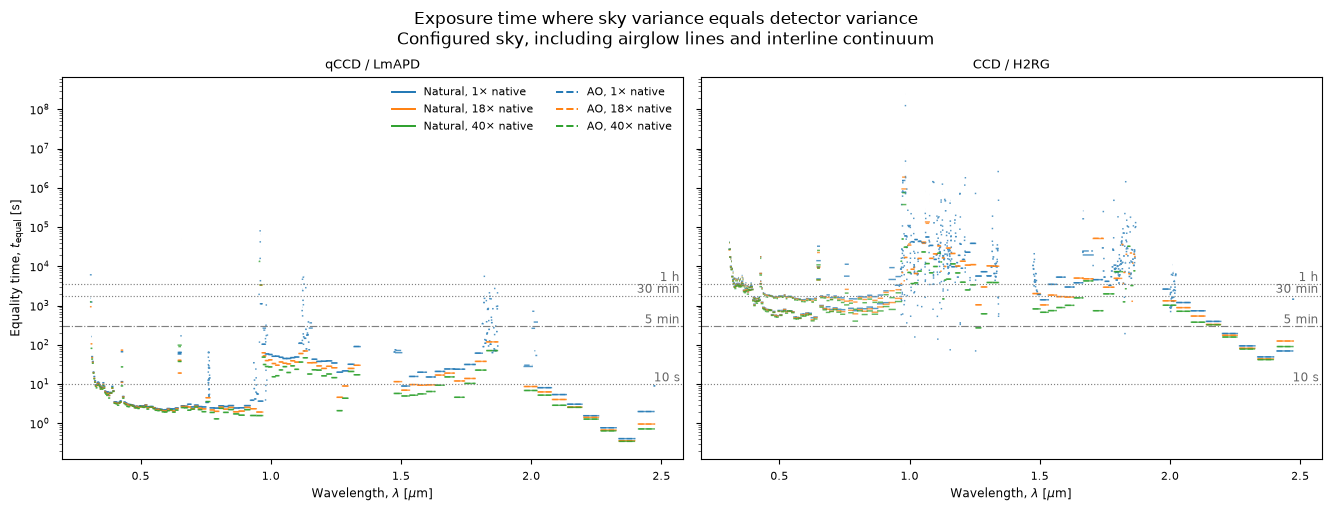

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/sky_equality_time.pdf')

In [57]:
from matplotlib.lines import Line2D

# Visible plotting controls. These do not alter the calculated cases or either table above.
# Natural uses ao_simulation_background_1h directly; AO uses its simulation_background_e
# extraction in ao_airglow_comparison_samples_raw. Neither path disables configured airglow.
SKY_EQUALITY_PLOT_CASES = (("Natural", 1), ("Natural", 18), ("Natural", 40), ("AO", 1), ("AO", 18), ("AO", 40))
SKY_EQUALITY_COLOR_BY = "bin factor"  # choose "bin factor", "seeing", or None
SKY_EQUALITY_LINESTYLE_BY = "seeing"  # choose "bin factor", "seeing", or None

SKY_EQUALITY_BIN_COLORS = {1: "C0", 18: "C1", 40: "C2"}
SKY_EQUALITY_SEEING_COLORS = {"Natural": "C0", "AO": "C1"}
SKY_EQUALITY_UNIFORM_COLOR = "0.25"
SKY_EQUALITY_BIN_LINESTYLES = {1: "-", 18: "--", 40: ":"}
SKY_EQUALITY_SEEING_LINESTYLES = {"Natural": "-", "AO": "--"}
SKY_EQUALITY_UNIFORM_LINESTYLE = "-"

SKY_EQUALITY_FILTER_PERCENTILE = 50

def sky_equality_filter(samples):
    # median = np.median(samples)
    filt_val = samples[samples >= np.percentile(samples, SKY_EQUALITY_FILTER_PERCENTILE)].mean()
    return np.full_like(samples, filt_val, dtype=float)

SKY_EQUALITY_PLOT_FILTER = sky_equality_filter
# Called separately for each contiguous finite order run. NaN order and physical-gap
# separators remain explicit, so this plotting filter never crosses them.

SKY_EQUALITY_REFERENCE_LABELS = {10: "10 s", 300: "5 min", 1800: "30 min", 3600: "1 h"}


def filter_sky_equality_runs(raw_equality_time_s, plot_filter):
    """Return plotting values, filtering each contiguous finite run independently."""
    plotting_equality_time_s = raw_equality_time_s.copy()
    if plot_filter is None:
        return plotting_equality_time_s

    finite = np.isfinite(raw_equality_time_s)
    run_starts = np.flatnonzero(finite & np.r_[True, ~finite[:-1]])
    run_ends = np.flatnonzero(finite & np.r_[~finite[1:], True]) + 1
    for run_start, run_end in zip(run_starts, run_ends, strict=True):
        plotting_equality_time_s[run_start:run_end] = plot_filter(raw_equality_time_s[run_start:run_end])
    return plotting_equality_time_s


# One directly inspectable entry per calculated seeing/binning case.
sky_equality_plot_samples = {}
for seeing in ("Natural", "AO"):
    for bin_factor in SKY_EQUALITY_BIN_FACTORS:
        case_rows = sky_equality_table_rows[(sky_equality_table_rows["seeing"] == seeing) & (sky_equality_table_rows["bin_factor"] == bin_factor)]
        wavelength_runs = []
        current_time_runs = []
        conventional_time_runs = []
        order_intervals = []

        for (_channel, _trace_id), order_rows in case_rows.groupby(["channel", "trace_id"], sort=False):
            order_rows = order_rows.sort_values("bin_index")
            sample_index = order_rows["bin_index"].to_numpy(dtype=int)
            starts_new_run = np.r_[True, np.diff(sample_index) != 1,]
            order_run = np.cumsum(starts_new_run)

            for run_number in np.unique(order_run):
                run_rows = order_rows[order_run == run_number]
                run_wave_um = run_rows["wave_nm"].to_numpy(dtype=float) / 1000
                order_intervals.append((_channel, np.min(run_wave_um), np.max(run_wave_um)))
                wavelength_runs.extend((run_wave_um, [np.nan]))
                current_time_runs.extend((run_rows["current_t_equal_s"].to_numpy(dtype=float), [np.nan]))
                conventional_time_runs.extend((run_rows["conventional_t_equal_s"].to_numpy(dtype=float), [np.nan]))

        wavelength_um = np.concatenate(wavelength_runs)[:-1]
        current_t_equal_s_raw = np.concatenate(current_time_runs)[:-1]
        conventional_t_equal_s_raw = np.concatenate(conventional_time_runs)[:-1]
        sky_equality_plot_samples[(seeing, bin_factor)] = {
            "wavelength_um": wavelength_um,
            "order_intervals": order_intervals,
            "current_t_equal_s_raw": current_t_equal_s_raw,
            "conventional_t_equal_s_raw": conventional_t_equal_s_raw,
            "current_t_equal_s_plot": filter_sky_equality_runs(current_t_equal_s_raw, SKY_EQUALITY_PLOT_FILTER),
            "conventional_t_equal_s_plot": filter_sky_equality_runs(conventional_t_equal_s_raw, SKY_EQUALITY_PLOT_FILTER),
        }


def sky_equality_filter_statistics(samples, raw_column, plot_column):
    """Summarize variation within and between the explicit order runs."""
    wavelength_um = samples["wavelength_um"]
    raw_values = samples[raw_column]
    plot_values = samples[plot_column]
    finite_wavelength = np.isfinite(wavelength_um)
    order_starts = np.flatnonzero(finite_wavelength & np.r_[True, ~finite_wavelength[:-1]])
    order_ends = np.flatnonzero(finite_wavelength & np.r_[~finite_wavelength[1:], True]) + 1
    raw_within_order_spans_dex = []
    plot_within_order_spans_dex = []
    plot_order_medians_dex = []
    finite_run_count = 0

    for order_start, order_end in zip(order_starts, order_ends, strict=True):
        raw_order = raw_values[order_start:order_end]
        plot_order = plot_values[order_start:order_end]
        finite = np.isfinite(raw_order)
        if not np.any(finite):
            continue
        finite_run_starts = np.flatnonzero(finite & np.r_[True, ~finite[:-1]])
        finite_run_ends = np.flatnonzero(finite & np.r_[~finite[1:], True]) + 1
        finite_run_count += len(finite_run_starts)
        for run_start, run_end in zip(finite_run_starts, finite_run_ends, strict=True):
            assert np.all(plot_order[run_start:run_end] == plot_order[run_start])
        raw_log_s = np.log10(raw_order[finite])
        plot_log_s = np.log10(plot_order[finite])
        raw_within_order_spans_dex.append(np.diff(np.percentile(raw_log_s, [16, 84]))[0])
        plot_within_order_spans_dex.append(np.diff(np.percentile(plot_log_s, [16, 84]))[0])
        plot_order_medians_dex.append(np.median(plot_log_s))

    return {
        "order_runs": len(order_starts),
        "finite_runs": finite_run_count,
        "raw_within_order_span_dex": np.median(raw_within_order_spans_dex),
        "plot_within_order_span_dex": np.median(plot_within_order_spans_dex),
        "order_median_span_dex": np.diff(np.percentile(plot_order_medians_dex, [16, 84]))[0],
    }


sky_equality_filter_diagnostics = {}
print("SKY_EQUALITY per-order median diagnostics " "(current/conventional; spans are 16th-84th percentiles in log10 seconds):")
for case in SKY_EQUALITY_PLOT_CASES:
    samples = sky_equality_plot_samples[case]
    current = sky_equality_filter_statistics(samples, "current_t_equal_s_raw", "current_t_equal_s_plot")
    conventional = sky_equality_filter_statistics(samples, "conventional_t_equal_s_raw", "conventional_t_equal_s_plot")
    intervals = samples["order_intervals"]
    overlap_pairs = sum(channel_i == channel_j and max(low_i, low_j) <= min(high_i, high_j) for interval_index, (channel_i, low_i, high_i) in enumerate(intervals) for channel_j, low_j, high_j in intervals[interval_index + 1:])
    sky_equality_filter_diagnostics[case] = {"current": current, "conventional": conventional, "same_channel_overlap_pairs": overlap_pairs}
    run_counts = f"{current['finite_runs']}/{conventional['finite_runs']} finite runs"
    within_order_spans = f"within-order {current['raw_within_order_span_dex']:.2f}/{conventional['raw_within_order_span_dex']:.2f} -> {current['plot_within_order_span_dex']:.2f}/{conventional['plot_within_order_span_dex']:.2f} dex"
    order_median_spans = f"order medians {current['order_median_span_dex']:.2f}/{conventional['order_median_span_dex']:.2f} dex"
    print(f"  {case[0]}, {case[1]}x: {current['order_runs']} order runs; {run_counts}; {within_order_spans}; {order_median_spans}; {overlap_pairs} same-channel overlapping-order pairs.")

sky_equality_case_colors = {
    "bin factor": {case: SKY_EQUALITY_BIN_COLORS[case[1]] for case in SKY_EQUALITY_PLOT_CASES},
    "seeing": {case: SKY_EQUALITY_SEEING_COLORS[case[0]] for case in SKY_EQUALITY_PLOT_CASES},
    None: {case: SKY_EQUALITY_UNIFORM_COLOR for case in SKY_EQUALITY_PLOT_CASES},
}[SKY_EQUALITY_COLOR_BY]
sky_equality_case_linestyles = {
    "bin factor": {case: SKY_EQUALITY_BIN_LINESTYLES[case[1]] for case in SKY_EQUALITY_PLOT_CASES},
    "seeing": {case: SKY_EQUALITY_SEEING_LINESTYLES[case[0]] for case in SKY_EQUALITY_PLOT_CASES},
    None: {case: SKY_EQUALITY_UNIFORM_LINESTYLE for case in SKY_EQUALITY_PLOT_CASES},
}[SKY_EQUALITY_LINESTYLE_BY]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.0), sharex=True, sharey=True, constrained_layout=True)
panel_specs = (("current_t_equal_s_plot", "qCCD / LmAPD"), ("conventional_t_equal_s_plot", "CCD / H2RG"))
for ax, (plot_column, panel_title) in zip(axes, panel_specs, strict=True):
    for case in SKY_EQUALITY_PLOT_CASES:
        samples = sky_equality_plot_samples[case]
        ax.plot(samples["wavelength_um"], samples[plot_column], color=sky_equality_case_colors[case], linestyle=sky_equality_case_linestyles[case], linewidth=0.75 * plt.rcParams["lines.linewidth"], alpha=0.75)

    for reference_time_s, reference_label in SKY_EQUALITY_REFERENCE_LABELS.items():
        ax.axhline(reference_time_s, color="0.5", linewidth=0.6 * plt.rcParams["lines.linewidth"], linestyle=":" if reference_time_s != 300 else "-.")
        ax.text(0.995, reference_time_s, reference_label, transform=ax.get_yaxis_transform(), ha="right", va="bottom", color="0.4", fontsize="small")

    ax.set_title(panel_title)
    ax.set_xlabel(r"Wavelength, $\lambda$ [$\mu$m]")
    ax.set_yscale("log")

axes[0].set_ylabel(r"Equality time, $t_{\rm equal}$ [s]")
fig.suptitle("Exposure time where sky variance equals detector variance\n" "Configured sky, including airglow lines and interline continuum")
selected_case_legend = [Line2D([0], [0], color=sky_equality_case_colors[case], linestyle=sky_equality_case_linestyles[case], label=fr"{case[0]}, {case[1]}$\times$ native") for case in SKY_EQUALITY_PLOT_CASES]
axes[0].legend(handles=selected_case_legend, frameon=False, ncol=2)
display_and_save_figure(fig, "sky_equality_time")


## TIS Configured Scattered-Line Rate

channel,sigma_RMS_nm,slit_area_arcsec2,camera_acceptance,detector_pixels,pixels_per_resel,rate_e_s_pix,rate_e_s_resel
B,2.4,7,0.02986,8388608,560.0,8.79e-09,4.92e-06
G,2.4,7,0.02986,8388608,480.0,3.54e-08,1.7e-05
R,2.4,7,0.02986,8388608,480.0,2.66e-07,0.000128
YJ,2.4,7,0.02986,4194304,405.0,3.29e-06,0.00133
H,2.4,7,0.02986,4194304,400.0,6.27e-06,0.00251
K,2.4,7,0.02986,4194304,362.0,1.19e-06,0.000429


channel,slit [arcsec],bin factor,rate [e-/s/pix],median pixels/resel,direct rate [e-/s/resel],stored rate [e-/s/resel]
B,0.70,18,8.79e-09,560.0,4.92e-06,4.92e-06
H,0.70,18,6.27e-06,400.0,0.00251,0.00251


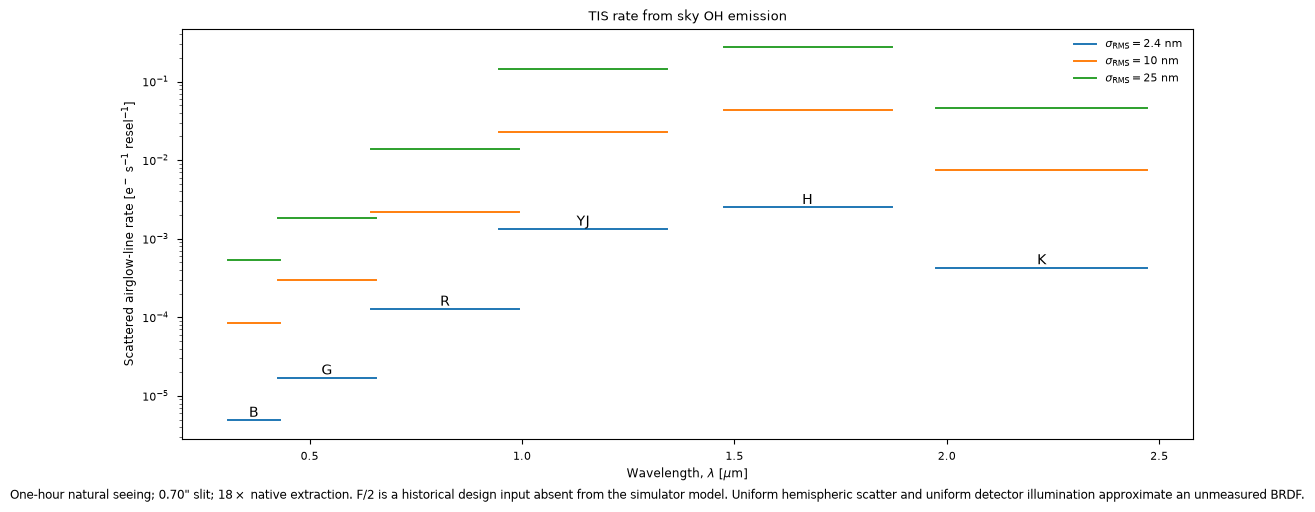

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/tis_scattered_line_rate.pdf')

In [58]:
from matplotlib.lines import Line2D

TIS_CASE_KEY = ("1 hour", 0.70, False)
TIS_BIN_FACTOR = 18
TIS_SIGMA_RMS_NM = (2.4, 10.0, 25.0)
TIS_CAMERA_F_NUMBER = 2.0  # external optical-design input; not encoded in the simulator
TIS_LINE_EFFECT_NAME = "airglow_and_interline_continuum"
TIS_LINE_EFFECT_ATTRIBUTE = "line_TER.emission"

tis_line_wave_nm, tis_line_flux_density, _ = fetch_sky_component(TIS_LINE_EFFECT_NAME, TIS_LINE_EFFECT_ATTRIBUTE, nominal_resolving_power=None)
tis_line_wave_nm = tis_line_wave_nm * 1000
tis_bin_edges_nm = np.empty(len(tis_line_wave_nm) + 1)
tis_bin_edges_nm[1:-1] = 0.5 * (tis_line_wave_nm[:-1] + tis_line_wave_nm[1:])
tis_bin_edges_nm[0] = tis_line_wave_nm[0] - 0.5 * (tis_line_wave_nm[1] - tis_line_wave_nm[0])
tis_bin_edges_nm[-1] = tis_line_wave_nm[-1] + 0.5 * (tis_line_wave_nm[-1] - tis_line_wave_nm[-2])
tis_bin_width_nm = np.diff(tis_bin_edges_nm)

tis_telescope_area_m2 = u.Quantity(from_currsys("!TEL.area", zs.cmds)).to_value(u.m**2)
tis_case = paper_case_results[TIS_CASE_KEY]
tis_slit_arcsec = float(tis_case["slit_arcsec"])
if not np.isclose(tis_slit_arcsec, 0.70):
    raise ValueError(f"TIS requires the 0.70 arcsec paper case, got {tis_slit_arcsec}.")
tis_slit_effect = get_effect(zs, "slitwheel_selector").wheel_effects[0]
tis_slit_rows = tis_slit_effect.table[np.isclose(tis_slit_effect.table["name"], tis_slit_arcsec)]
assert len(tis_slit_rows) == 1
tis_slit_length_arcsec = u.Quantity(tis_slit_rows[0]["length"], tis_slit_effect.table["length"].unit).to_value(u.arcsec)
tis_slit_width_arcsec = u.Quantity(tis_slit_rows[0]["width"], tis_slit_effect.table["width"].unit).to_value(u.arcsec)
tis_slit_area_arcsec2 = tis_slit_length_arcsec * tis_slit_width_arcsec

tis_camera_half_angle = np.arctan(1 / (2 * TIS_CAMERA_F_NUMBER))
tis_camera_solid_angle_sr = 2 * np.pi * (1 - np.cos(tis_camera_half_angle))
tis_camera_acceptance = tis_camera_solid_angle_sr / (2 * np.pi)
tis_detector_geometry = detector_geometry_table(zs)
tis_trace_efficiency = get_effect(zs, "trace_eff_analytical")
tis_transmission_wave_nm = transmission_data["wave_nm"].to_value(u.nm)
tis_samples = tis_case["samples_complete"]
tis_samples = tis_samples[tis_samples["bin_factor"] == TIS_BIN_FACTOR]
if len(tis_samples) == 0:
    raise ValueError(f"No TIS extraction rows use bin factor {TIS_BIN_FACTOR}.")

tis_rate_rows = []
for aperture_id, channel_data in transmission_data["channels"].items():
    channel = str(channel_data["label"])
    channel_samples = tis_samples[np.asarray(tis_samples["channel"], dtype=str) == channel]
    wave_min_nm = float(np.min(channel_samples["wave_nm"]))
    wave_max_nm = float(np.max(channel_samples["wave_nm"]))
    pixels_per_resel = float(np.median(channel_samples["n_pix"]))
    line_rows = (tis_line_wave_nm >= wave_min_nm) & (tis_line_wave_nm <= wave_max_nm)

    pre_scatter_throughput = channel_data["telescope_throughput"] * channel_data["dichroic_total"] * channel_data["instrument_optics_groups"]["preoptics"] * channel_data["instrument_optics_groups"]["collimator"]
    downstream_throughput = channel_data["instrument_optics_groups"]["camera"] * channel_data["detector_qe"]
    pre_scatter_at_lines = np.interp(tis_line_wave_nm[line_rows], tis_transmission_wave_nm, pre_scatter_throughput)
    downstream_at_lines = np.interp(tis_line_wave_nm[line_rows], tis_transmission_wave_nm, downstream_throughput)
    spectrograph = tis_trace_efficiency._spectrographs[channel.lower()]
    cross_disperser_efficiency = spectrograph.xdisp_efficiency(tis_line_wave_nm[line_rows] * u.nm)
    incident_line_rate = tis_line_flux_density[line_rows] * tis_bin_width_nm[line_rows] * tis_telescope_area_m2 * tis_slit_area_arcsec2 * pre_scatter_at_lines

    geometry = tis_detector_geometry[np.asarray(tis_detector_geometry["channel"], dtype=str) == channel][0]
    pixel_size_mm = float(geometry["pixel_size_mm"])
    detector_half_x_mm = 0.5 * int(geometry["x_size"]) * pixel_size_mm
    detector_half_y_mm = 0.5 * int(geometry["y_size"]) * pixel_size_mm
    camera_focal_length_mm = spectrograph.focal_length.to_value(u.mm)
    detector_solid_angle_sr = 4 * np.arctan(detector_half_x_mm * detector_half_y_mm / (camera_focal_length_mm * np.sqrt(camera_focal_length_mm**2 + detector_half_x_mm**2 + detector_half_y_mm**2)))
    pixel_half_size_mm = 0.5 * pixel_size_mm
    pixel_solid_angle_sr = 4 * np.arctan(pixel_half_size_mm**2 / (camera_focal_length_mm * np.sqrt(camera_focal_length_mm**2 + 2 * pixel_half_size_mm**2)))
    pixel_fraction_of_detector = pixel_solid_angle_sr / detector_solid_angle_sr

    for sigma_rms_nm in TIS_SIGMA_RMS_NM:
        tis_total = (4 * np.pi * sigma_rms_nm / tis_line_wave_nm[line_rows])**2
        accepted_detector_rate = np.sum(incident_line_rate * tis_total * tis_camera_acceptance * cross_disperser_efficiency * downstream_at_lines)
        rate_per_pixel = accepted_detector_rate * pixel_fraction_of_detector
        tis_rate_rows.append({
            "channel": channel,
            "wave_min_nm": wave_min_nm,
            "wave_max_nm": wave_max_nm,
            "sigma_RMS_nm": sigma_rms_nm,
            "slit_area_arcsec2": tis_slit_area_arcsec2,
            "camera_acceptance": tis_camera_acceptance,
            "detector_pixels": int(geometry["x_size"]) * int(geometry["y_size"]),
            "pixel_fraction_of_detector": pixel_fraction_of_detector,
            "pixels_per_resel": pixels_per_resel,
            "rate_e_s_pix": rate_per_pixel,
            "rate_e_s_resel": rate_per_pixel * pixels_per_resel,
        })

tis_rate_table = Table(rows=tis_rate_rows)
tis_primary = tis_rate_table[tis_rate_table["sigma_RMS_nm"] == TIS_SIGMA_RMS_NM[0]]
display_frame(tis_primary[[
        "channel", "sigma_RMS_nm", "slit_area_arcsec2", "camera_acceptance",
        "detector_pixels", "pixels_per_resel", "rate_e_s_pix", "rate_e_s_resel",
    ]],
    formats={
        "sigma_RMS_nm": "{:.1f}",
        "slit_area_arcsec2": "{:.3g}",
        "camera_acceptance": "{:.4g}",
        "pixels_per_resel": "{:.1f}",
        "rate_e_s_pix": "{:.3g}",
        "rate_e_s_resel": "{:.3g}",
    }
)

tis_dimensional_checks = []
for channel in ("B", "H"):
    row = tis_primary[np.asarray(tis_primary["channel"], dtype=str) == channel][0]
    direct_resel_rate = float(row["rate_e_s_pix"]) * float(row["pixels_per_resel"])
    tis_dimensional_checks.append({
        "channel": channel,
        "slit [arcsec]": tis_slit_arcsec,
        "bin factor": TIS_BIN_FACTOR,
        "rate [e-/s/pix]": float(row["rate_e_s_pix"]),
        "median pixels/resel": float(row["pixels_per_resel"]),
        "direct rate [e-/s/resel]": direct_resel_rate,
        "stored rate [e-/s/resel]": float(row["rate_e_s_resel"]),
    })
display_frame(tis_dimensional_checks,
    formats={
        "slit [arcsec]": "{:.2f}",
        "rate [e-/s/pix]": "{:.3g}",
        "median pixels/resel": "{:.1f}",
        "direct rate [e-/s/resel]": "{:.3g}",
        "stored rate [e-/s/resel]": "{:.3g}",
    }
)

tis_colors = dict(zip(TIS_SIGMA_RMS_NM, plt.rcParams["axes.prop_cycle"].by_key()["color"][:len(TIS_SIGMA_RMS_NM)], strict=True))
fig, ax = plt.subplots(figsize=(10.8, 4.8), constrained_layout=True)
for row in tis_rate_table:
    ax.plot(np.array([row["wave_min_nm"], row["wave_max_nm"]]) / 1000, np.repeat(row["rate_e_s_resel"], 2), color=tis_colors[float(row["sigma_RMS_nm"])], linewidth=plt.rcParams["lines.linewidth"])
for row in tis_primary:
    ax.text(0.5 * (row["wave_min_nm"] + row["wave_max_nm"]) / 1000, row["rate_e_s_resel"], str(row["channel"]), ha="center", va="bottom")
ax.set_title("TIS rate from sky OH emission")
ax.set_xlabel(r"Wavelength, $\lambda$ [$\mu$m]")
ax.set_ylabel(r"Scattered airglow-line rate [e$^-$ s$^{-1}$ resel$^{-1}$]")
ax.set_yscale("log")
ax.legend(handles=[Line2D([0], [0], color=tis_colors[sigma_rms_nm], label=rf"$\sigma_{{\rm RMS}}={sigma_rms_nm:g}$ nm") for sigma_rms_nm in TIS_SIGMA_RMS_NM], frameon=False)
fig.text(0.5, -0.01, r'One-hour natural seeing; 0.70" slit; $18\times$ native extraction. ' "F/2 is a historical design input absent from the simulator model. " "Uniform hemispheric scatter and uniform detector illumination approximate an unmeasured BRDF.", ha="center", va="top", fontsize="small")
display_and_save_figure(fig, "tis_scattered_line_rate")

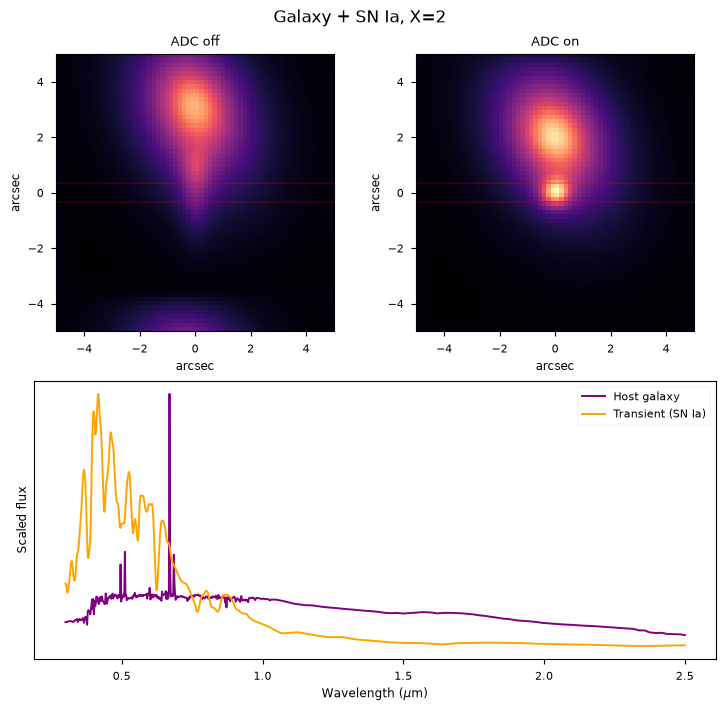

PosixPath('/Users/jibailey/src/zs-scopesim/notebooks/spie2026/adc_scene.pdf')

In [59]:
scene_figure_title = "Galaxy + SN Ia, X=2"
scene_output_stem = "host_sn1a_adc_scene"
scene_output_format = "png"
scene_airmass = 2
scene_figsize = (7.2, 7.0)
scene_dpi = 180
scene_cmap = "magma"
scene_image_interpolation = "nearest"
scene_extent_arcsec = 10.0
scene_fov_wave_samples = 401
scene_spectrum_wave_samples = 1001

from copy import deepcopy as scene_deepcopy
import pathlib as scene_pathlib

import numpy as scene_np
import matplotlib.pyplot as scene_plt
from matplotlib.colors import Normalize as scene_Normalize
from matplotlib.patches import Rectangle as scene_Rectangle
from astropy import units as scene_u
from astropy.io import fits as scene_fits
from astropy.table import Table as scene_Table
from IPython.display import display as scene_display
import scopesim_templates as scene_sim_tp
from spextra import Spextrum as scene_Spextrum
from scopesim.effects.apertures import RectangularApertureMask as scene_RectangularApertureMask
from scopesim.effects.atmo_dispersion import ADShift as scene_ADShift, ADCShift as scene_ADCShift
from scopesim.effects.detector_list import DetectorList as scene_DetectorList
from scopesim.effects.spectral_trace_list import SpectralTraceList as scene_SpectralTraceList
from scopesim.optics.fov_manager import FOVManager as scene_FOVManager
from scopesim.source.source import Source as scene_Source
from scopesim.source.source_utils import Empirical1D as scene_Empirical1D, SourceSpectrum as scene_SourceSpectrum
from scopesim.utils import from_currsys as scene_from_currsys
from zs_scopesim_tools.helpers import warning_prevent_sync_alt_ra_dec as scene_warning_prevent_sync_alt_ra_dec
from zs_scopesim_tools.validation import get_effect as scene_get_effect

scene_output_path = scene_pathlib.Path(output_dir) / f"{scene_output_stem}.{scene_output_format}"
scene_plot_wave = scene_np.linspace(0.3, 2.5, scene_spectrum_wave_samples) * scene_u.um
scene_fov_wave = scene_np.linspace(0.3, 2.5, scene_fov_wave_samples) * scene_u.um

# Keep the configured train untouched; only local scene commands are changed.
scene_cmds = scene_deepcopy(zs.cmds)
scene_cmds["!OBS.airmass"] = scene_airmass
scene_cmds["!OBS.alt"] = None
scene_warning_prevent_sync_alt_ra_dec(scene_cmds)
scene_cmds["!SIM.spectral.spectral_bin_width"] = (scene_fov_wave[1] - scene_fov_wave[0]).to_value(scene_u.um)

# Rebuild local copies so their cached zenith geometry follows scene_airmass.
scene_configured_psf_effect = scene_get_effect(zs, "seeing_psf")
scene_psf_effect = scene_configured_psf_effect.__class__(cmds=scene_cmds, name=scene_configured_psf_effect.meta["name"], include=scene_configured_psf_effect.include,
                                                          enable_ao=scene_configured_psf_effect.meta["enable_ao"], ao_table=scene_configured_psf_effect.meta["ao_table"], is_absolute=scene_configured_psf_effect.meta["is_absolute"],
                                                          fwhm=scene_deepcopy(scene_configured_psf_effect.meta["fwhm"]), alpha=scene_configured_psf_effect.meta["alpha"])

scene_configured_adc_effect = scene_get_effect(zs, "adc_residuals")
scene_adc_effect = scene_ADCShift(cmds=scene_cmds, name=scene_configured_adc_effect.meta["name"], include=scene_configured_adc_effect.include, filename=scene_configured_adc_effect.meta["filename"], method=scene_configured_adc_effect.meta["method"], zenith_angle_error=scene_configured_adc_effect.meta["zenith_angle_error"], wave_ref_um=scene_configured_adc_effect.meta["wave_ref_um"])

scene_ad_effect = scene_ADShift(cmds=scene_cmds, temperature="!ATMO.temperature", pressure="!ATMO.pressure", humidity="!ATMO.humidity", x_co2="!ATMO.x_co2", wave_ref_um=scene_configured_adc_effect.meta["wave_ref_um"], method=scene_configured_adc_effect.meta["method"])

# One local synthetic spectral FOV is sufficient for the spatial comparison.
scene_aperture_effect = scene_RectangularApertureMask(x=0, y=0, width=scene_extent_arcsec, height=scene_extent_arcsec, x_unit="arcsec", y_unit="arcsec", cmds=scene_cmds)
scene_detector_effect = scene_DetectorList(image_plane_id=0,
    array_dict={
        "id": [0], "x_cen": [0], "y_cen": [0], "x_size": [100], "y_size": [100],
        "pixel_size": [0.015], "angle": [0], "gain": [1],
    },
    x_cen_unit="mm", y_cen_unit="mm", pixel_size_unit="mm",
    x_size_unit="pix", y_size_unit="pix", angle_unit="deg",
    gain_unit="electron/adu", cmds=scene_cmds
)
scene_trace_hdul = scene_fits.HDUList([
    scene_fits.PrimaryHDU(header=scene_fits.Header(cards={"ECAT": 1, "EDATA": 2})),
    scene_fits.BinTableHDU(data=scene_Table(data={
        "description": ["scene"], "extension_id": [2],
        "aperture_id": [0], "image_plane_id": [0],
    })),
    scene_fits.BinTableHDU(header=scene_fits.Header(cards={"EXTNAME": "scene"}),
        data=scene_Table(data={
            "wavelength": [0.3, 2.5, 0.3, 2.5, 0.3, 2.5],
            "s": [-2, -2, 0, 0, 2, 2],
            "x": [3.0, 3.0, 3.5, 3.5, 4.0, 4.0],
            "y": [0.1, 7.4, 0.1, 7.4, 0.1, 7.4],
        })
    ),
])
scene_trace_effect = scene_SpectralTraceList(hdulist=scene_trace_hdul, cmds=scene_cmds)
scene_fov_manager = scene_FOVManager(effects=[scene_aperture_effect, scene_trace_effect, scene_detector_effect], cmds=scene_cmds)

scene_host_source = scene_sim_tp.galaxy(sed="brown/NGC3870", z=0.02, amplitude=16, filter_curve="g", pixel_scale=0.01, r_eff=2.5, n=1.0, ellip=0.3, theta=90, extend=5)
scene_host_source.shift(dy=2 * scene_u.arcsec)
scene_transient_sed = scene_Spextrum("sne/sn1a").redshift(0.02)
scene_transient_spectrum = scene_transient_sed.scale_to_magnitude(18 * scene_u.ABmag, "g")
scene_source = scene_host_source + scene_Source(spectra=scene_transient_spectrum, x=[0.0], y=[0.0], ref=[0.0], weight=[1.0])

scene_host_flux = scene_source.fields[0].spectrum(scene_plot_wave)
scene_transient_flux = scene_source.fields[1].spectrum(scene_plot_wave)
scene_host_scaled = (scene_host_flux / scene_host_flux.max()).value
scene_transient_scaled = (scene_transient_flux / scene_transient_flux.max()).value

# Resample only these two local spectra onto the reduced FOV grid.
for scene_field in scene_source.fields:
    scene_field.spectra = {scene_reference: scene_SourceSpectrum(scene_Empirical1D, points=scene_fov_wave, lookup_table=scene_spectrum(scene_fov_wave)) for scene_reference, scene_spectrum in scene_field.spectra.items()}

scene_fov = scene_fov_manager.fovs[0]
scene_fov.extract_from(scene_source)
scene_fov.view()
scene_fov = scene_psf_effect.apply_to(scene_fov)
scene_adc_off_fov = scene_ad_effect.apply_to(scene_deepcopy(scene_fov))
scene_adc_on_fov = scene_adc_effect.apply_to(scene_deepcopy(scene_fov))

scene_adc_off_image = scene_adc_off_fov.data.sum(axis=0)
scene_adc_on_image = scene_adc_on_fov.data.sum(axis=0)
scene_image_stack = scene_np.stack([scene_adc_off_image, scene_adc_on_image])
scene_image_norm = scene_Normalize(vmin=scene_image_stack.min(), vmax=scene_image_stack.max())
scene_image_extent = [-0.5 * scene_extent_arcsec, 0.5 * scene_extent_arcsec] * 2
scene_slit_width_arcsec = scene_u.Quantity(scene_from_currsys("!INST.vis_curr_slit", scene_cmds), scene_u.arcsec).to_value(scene_u.arcsec)

scene_figure = scene_plt.figure(figsize=scene_figsize, constrained_layout=True)
scene_grid = scene_figure.add_gridspec(2, 2)
scene_adc_off_axis = scene_figure.add_subplot(scene_grid[0, 0])
scene_adc_on_axis = scene_figure.add_subplot(scene_grid[0, 1])
scene_spectrum_axis = scene_figure.add_subplot(scene_grid[1, :])

for scene_axis, scene_image, scene_panel_title in (
    (scene_adc_off_axis, scene_adc_off_image, "ADC off"),
    (scene_adc_on_axis, scene_adc_on_image, "ADC on"),
):
    scene_axis.imshow(scene_image, origin="lower", extent=scene_image_extent, cmap=scene_cmap, norm=scene_image_norm, interpolation=scene_image_interpolation)
    scene_axis.add_patch(scene_Rectangle((-0.5 * scene_extent_arcsec, -0.5 * scene_slit_width_arcsec), scene_extent_arcsec, scene_slit_width_arcsec, facecolor="none", edgecolor="red"))
    scene_axis.set_title(scene_panel_title)
    scene_axis.set_xlabel("arcsec")
    scene_axis.set_ylabel("arcsec")
    scene_axis.set_aspect("equal")

scene_spectrum_axis.plot(scene_plot_wave.to_value(scene_u.um), scene_host_scaled, label="Host galaxy", color="purple")
scene_spectrum_axis.plot(scene_plot_wave.to_value(scene_u.um), scene_transient_scaled, label="Transient (SN Ia)", color="orange")
scene_spectrum_axis.legend()
scene_spectrum_axis.set_yticks([])
scene_spectrum_axis.set_ylabel("Scaled flux")
scene_spectrum_axis.set_xlabel("Wavelength ($\\mu$m)")
scene_figure.suptitle(scene_figure_title)

display_and_save_figure(scene_figure, 'adc_scene')
